# P02 — ¿Dónde se concentran los registros de colegios?

Un mapa con muchos puntos superpuestos puede ocultar diferencias. Queremos responder dos preguntas: **¿dónde se agrupan los conteos altos o bajos de colegios registrados?** y **¿dónde un conteo contrasta con el de sus vecinos?** Primero entenderemos los registros y los sitios; después contaremos los registros dentro de hexágonos para explorar estas preguntas con Hot Spot y Outlier.

Trabajamos con registros de establecimientos, no con estudiantes. Una concentración de registros no demuestra buena calidad educativa; un conteo bajo no demuestra falta de acceso. Para responder esas otras preguntas necesitaríamos matrícula, capacidad, población y tiempos de viaje.

## Qué aprenderás

- Distinguir un registro, un sitio ocupado y un hexágono con registros.
- Leer cómo cambia la asociación espacial cuando cambia la vecindad.
- Interpretar concentraciones con Gi* y contrastes locales con Outlier, sin confundirlos con calidad o acceso educativo.

Piensa en dos registros que comparten coordenadas: en el mapa podrían verse como un solo punto. Collect Events nos permite contar cuántos registros hay en ese sitio, sin moverlos. Más adelante cambiaremos la unidad: un hexágono puede reunir varios sitios, y cada registro original debe seguir contando.

Usaremos la copia local de **Colegios de Colombia / CommunityMapsEsriColombia**. El recorrido conserva los ejercicios anteriores: explorar datos → contar coincidencias → describir ICOUNT → probar veinte distancias de 2 km → probar veinte distancias de 500 m → Gi* con ocho vecinos. Al final añadimos **Hot Spot optimizado y Outlier optimizado con agregación hexagonal**. El primero busca semejanza local de conteos; el segundo distingue semejanzas y contrastes.

Para comenzar, selecciona el kernel de ArcGIS Pro 3.6 con licencia y reinícialo. La primera celda localiza la carpeta del proyecto: si trabajas fuera de ella, define ROOT con tu ruta. DATA_DIR apunta a los datos de entrada y OUTPUT_DIR a una carpeta distinta para resultados; ambas admiten rutas externas. Cada ejecución creará una carpeta nueva. No necesitas instalar paquetes ni modificar los datos originales.

**Cómo leer esta versión:** las salidas corresponden a la ejecución integral del 21/09/2026. Los párrafos que dicen «referencia histórica» conservan la lectura del 17/09/2026. Los nuevos resultados hexagonales se interpretan junto a sus tablas y figuras; al final están los enlaces a ambas etapas.

In [1]:
# Edite las rutas para su copia local o ubicaciones externas autorizadas.
from pathlib import Path
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p/'README.md').is_file() and (p/'99 - Recursos/notebooks').is_dir()), None)
if ROOT is None:
    raise FileNotFoundError('Defina ROOT = Path con la raíz de su copia.')
DATA_DIR = ROOT/'99 - Recursos/datos/clase_02_colegios/colegios.gdb'
OUTPUT_DIR = ROOT/'99 - Recursos/salidas_clase_02/practica_02/hexbin_20260921'


### Antes de empezar
Comprueba que ArcPy puede abrir la copia de colegios y la plantilla de mapa incluida con Pro. Si falta alguna, la celda te indicará cuál: corrige la ruta antes de continuar.

In [2]:
# Solo lectura: comprobar kernel, licencia y cada ruta antes de crear salidas.
try:
    import arcpy
except Exception as exc:
    raise RuntimeError('ArcPy no disponible. Seleccione el kernel Python de ArcGIS Pro con licencia y reinícielo; no se instala automáticamente.') from exc
try:
    INFO_PRO = arcpy.GetInstallInfo()
    LICENCIA = arcpy.ProductInfo()
except Exception as exc:
    raise RuntimeError('No se pudo inicializar Pro. Revise instalación y acceso a licencia antes de modelar.') from exc
print('ArcGIS Pro:', INFO_PRO.get('Version'), '| licencia:', LICENCIA)
if LICENCIA not in ('ArcView', 'ArcEditor', 'ArcInfo'):
    raise RuntimeError('Licencia no inicializada: ' + str(LICENCIA))
PLANTILLA = Path(INFO_PRO['InstallDir']) / 'Resources/ArcToolBox/Services/routingservices/data/Blank.aprx'
source = str((DATA_DIR / 'Colegios_Colombia').resolve())
template = PLANTILLA
REQUERIDOS = [('Colegios_Colombia sin integrar', source, False), ('Blank.aprx instalada', template, True)]
faltantes = []
for nombre, ruta, es_archivo in REQUERIDOS:
    ruta = Path(ruta).resolve()
    existe = ruta.is_file() if es_archivo else bool(arcpy.Exists(str(ruta)))
    print(f'{nombre} | {ruta} | existe={existe}')
    if not existe:
        faltantes.append(f'{nombre}: {ruta}')
if faltantes:
    raise FileNotFoundError('Entradas ausentes; ajuste la configuración sin sustituir datos: ' + '; '.join(faltantes))


ArcGIS Pro: 3.6.2 | licencia: ArcInfo


Colegios_Colombia sin integrar | 99 - Recursos/datos/clase_02_colegios/colegios.gdb/Colegios_Colombia | existe=True
Blank.aprx instalada | C:\Program Files\ArcGIS\Pro\Resources\ArcToolBox\Services\routingservices\data\Blank.aprx | existe=True


## EDA: establecimientos registrados, no demanda educativa
La población es la exportación local disponible, no un censo certificado. Cada fila es un registro de establecimiento; no contiene matrícula, capacidad ni población escolar. Se compara asociación de **registros coincidentes por sitio**, no accesibilidad de estudiantes.

| Campo | Significado/unidad | Decisión |
| --- | --- | --- |
| Tipo | Categoría nominal, alias observado «Marca» | Frecuencias y barras, no orden cuantitativo |
| Ciudad | Etiqueta nominal de localización | Nulos/categorías, no límites municipales |
| OID | Identidad de fila local | Unicidad; no media ni clave educativa |
| XY / CRS 3857 | Metros cartográficos Web Mercator | Coincidencias/cobertura; no viaje terrestre |
| ICOUNT | Establecimientos registrados por sitio ocupado | Multiplicidad, no matrícula |

Las barras comparan categorías; un histograma de códigos sería engañoso. No hay fecha individual: no se puede construir una serie ni inferir crecimiento de oferta. Cobertura irregular y ausencia de San Andrés indicada por la revisión docente impiden generalizar al país. No se promedian XY: el mapa conserva su interpretación espacial.

In [3]:
# Verificar identidad y esquema antes de crear cualquier salida.
import arcpy, math, uuid, time
from collections import Counter
from IPython.display import display, Image
desc = arcpy.Describe(source)
sr = desc.spatialReference
if desc.shapeType != 'Point' or sr.factoryCode != 3857:
    raise ValueError('La entrada difiere del CRS puntual inspeccionado; revisar antes de calcular distancias.')
fields = {f.name: f for f in arcpy.ListFields(source)}
if not {'Tipo', 'Ciudad'}.issubset(fields):
    raise ValueError('Esquema distinto al inspeccionado; revisar diccionario.')
print('Entorno:', arcpy.GetInstallInfo()['Version'], arcpy.ProductInfo())
print('CRS:', sr.name, sr.factoryCode, sr.linearUnitName, '| advertencia: distorsión Web Mercator')
print('Campos temporales:', [f.name for f in fields.values() if f.type in ('Date', 'DateOnly', 'TimestampOffset')])


Entorno: 3.6.2 ArcInfo
CRS: WGS_1984_Web_Mercator_Auxiliary_Sphere 3857 Meter | advertencia: distorsión Web Mercator
Campos temporales: []


### Diccionario: leer campos, no promediar identificadores
Leemos el esquema para distinguir categoría, clave y posición. La tabla muestra tipos y ejemplos de categorías, no datos personales. Un nombre de campo no basta para certificar su significado.

In [4]:
# Diccionario visible: esquema real, sin exponer identificadores ni datos personales.
from IPython.display import HTML
from html import escape

def tabla_visible(headers, rows):
    # HTML básico compatible con Jupyter/VS Code; todas las filas son visibles.
    head = ''.join('<th>' + escape(str(v)) + '</th>' for v in headers)
    body = ''.join('<tr>' + ''.join('<td>' + escape(str(v)) + '</td>' for v in row) + '</tr>' for row in rows)
    display(HTML('<table><thead><tr>' + head + '</tr></thead><tbody>' + body + '</tbody></table>'))

roles = {
 'Tipo': ('Categoría', 'Etiqueta de tipo; catálogo no certificado', 'sin unidad'),
 'Ciudad': ('Categoría', 'Etiqueta territorial; no límite administrativo', 'sin unidad'),
}

dictionary_rows = []
for field in arcpy.ListFields(source):
    role, meaning, unit = roles.get(field.name, ('No analizado', 'Semántica no verificada: no inferir del nombre', 'no verificada'))
    example = 'No se expone: innecesario para la pregunta'
    if field.type == 'OID':
        role, meaning, unit = 'Clave local', 'Identifica fila de esta copia, no entidad real única', 'sin unidad'
    elif field.type == 'Geometry':
        role, meaning, unit = 'Posición', 'Geometría puntual; coincidencia no prueba duplicación', sr.linearUnitName
        example = 'Point (tipo geométrico observado)'
    elif role in ('Categoría', 'Selección temática'):
        with arcpy.da.SearchCursor(source, [field.name]) as cursor:
            values = Counter(row[0] for row in cursor)
        example = next((str(v) for v in values if v is not None and str(v).strip()), 'sin ejemplo no nulo')
    elif role == 'Cobertura temporal':
        example = 'Consultar intervalo agregado en la celda siguiente'
    dictionary_rows.append([field.name, field.type, role, meaning, unit, example,
                            'NULL = ausente, no cero; significado administrativo no certificado',
                            '0 no significa ausencia sin diccionario fuente'])
tabla_visible(['Campo real', 'Tipo', 'Rol', 'Significado y límite', 'Unidad', 'Ejemplo seguro', 'Nulo', 'Cero'], dictionary_rows)


Campo real,Tipo,Rol,Significado y límite,Unidad,Ejemplo seguro,Nulo,Cero
OBJECTID,OID,Clave local,"Identifica fila de esta copia, no entidad real única",sin unidad,No se expone: innecesario para la pregunta,"NULL = ausente, no cero; significado administrativo no certificado",0 no significa ausencia sin diccionario fuente
Shape,Geometry,Posición,Geometría puntual; coincidencia no prueba duplicación,Meter,Point (tipo geométrico observado),"NULL = ausente, no cero; significado administrativo no certificado",0 no significa ausencia sin diccionario fuente
Nombre,String,No analizado,Semántica no verificada: no inferir del nombre,no verificada,No se expone: innecesario para la pregunta,"NULL = ausente, no cero; significado administrativo no certificado",0 no significa ausencia sin diccionario fuente
Dirección,String,No analizado,Semántica no verificada: no inferir del nombre,no verificada,No se expone: innecesario para la pregunta,"NULL = ausente, no cero; significado administrativo no certificado",0 no significa ausencia sin diccionario fuente
Tipo,String,Categoría,Etiqueta de tipo; catálogo no certificado,sin unidad,Centro Educativo,"NULL = ausente, no cero; significado administrativo no certificado",0 no significa ausencia sin diccionario fuente
Descripción,String,No analizado,Semántica no verificada: no inferir del nombre,no verificada,No se expone: innecesario para la pregunta,"NULL = ausente, no cero; significado administrativo no certificado",0 no significa ausencia sin diccionario fuente
Ciudad,String,Categoría,Etiqueta territorial; no límite administrativo,sin unidad,Bucaramanga,"NULL = ausente, no cero; significado administrativo no certificado",0 no significa ausencia sin diccionario fuente


### ¿Qué contiene la copia?
Contamos filas, categorías y coordenadas repetidas. Un valor nulo significa que falta información; un cero es un valor y puede tener otro significado. También revisamos la extensión del mapa y si hay fechas. Estas preguntas ayudan a saber qué podemos comparar sin cambiar ni eliminar registros.

In [5]:
# Solo resúmenes de calidad: no volcar nombres, direcciones ni identificadores personales.
xy_before = Counter()
categories = {f: Counter() for f in ('Tipo', 'Ciudad')}
with arcpy.da.SearchCursor(source, ['Tipo', 'Ciudad', 'SHAPE@XY', 'OID@']) as cursor:
    oid_counts = Counter()
    for kind, city, xy, oid in cursor:
        if xy is None or any(v is None or not math.isfinite(v) for v in xy):
            raise ValueError('XY ausente/no finita: detener sin eliminar registros.')
        xy_before[xy] += 1
        oid_counts[oid] += 1
        categories['Tipo'][kind] += 1
        categories['Ciudad'][city] += 1
n = sum(xy_before.values())
for f, values in categories.items():
    print(f, 'nulos', values[None], 'vacíos', values[''], 'ceros', values[0], 'categorías', len(values))
print('Filas:', n, 'XY únicos:', len(xy_before), 'exceso coincidente:', n-len(xy_before))
print('OID repetidos:', sum(v > 1 for v in oid_counts.values()), '| OID no es clave educativa universal')
if n < 30:
    raise ValueError('Población inesperadamente pequeña; revisar integridad de entrada.')

# Extensión y ceros diagnostican cobertura sin corregir posiciones automáticamente.
print('Extensión (Xmin,Ymin,Xmax,Ymax), metros del CRS:',
      (min(x[0] for x in xy_before), min(x[1] for x in xy_before),
       max(x[0] for x in xy_before), max(x[1] for x in xy_before)))
print('Registros X=0 o Y=0:', sum(count for (x,y),count in xy_before.items() if x == 0 or y == 0))
print('Sitios coincidentes:', sum(count > 1 for count in xy_before.values()), '| no equivale a duplicados')
print('Frecuencias por Tipo:', dict(categories['Tipo']), '| filas, no estudiantes')


Tipo nulos 0 vacíos 0 ceros 0 categorías 2
Ciudad nulos 0 vacíos 0 ceros 0 categorías 771
Filas: 10617 XY únicos: 10262 exceso coincidente: 355
OID repetidos: 0 | OID no es clave educativa universal
Extensión (Xmin,Ymin,Xmax,Ymax), metros del CRS: (-8768545.1152, -470057.5595000014, -7511959.8026, 1320485.5122999996)
Registros X=0 o Y=0: 0
Sitios coincidentes: 318 | no equivale a duplicados
Frecuencias por Tipo: {'Centro Educativo': 5542, 'Institución Educativa': 5075} | filas, no estudiantes


Una ciudad o categoría repetida no es duplicación. OID único solo prueba identidad de filas locales, no de establecimientos reales. Coordenadas repetidas pueden corresponder a varias unidades en el mismo sitio; se cuentan sin fusionar ubicaciones cercanas. La ausencia de campo fecha impide inferir vigencia.

## Mapas y gráficos ArcGIS
Primero se visualiza distribución y frecuencia por Tipo. Después, símbolos graduados e histograma de ICOUNT muestran el cambio de unidad. Se conservan mapas APRX nuevos para inspección; no se guarda la plantilla. La base remota Light Gray Canvas solo aporta contexto; no se añaden polígonos al análisis.

**Referencia histórica del 17/09/2026:** 10 617 filas, 10 262 XY únicos y 318 sitios coincidentes; OID sin repetidos, nulos ni ceros en las categorías examinadas, sin XY nulas/no finitas o cero. Tipo contiene 5 542 Centro Educativo y 5 075 Institución Educativa; son frecuencias de registro, no tamaños escolares. Ciudad tiene 771 etiquetas: no equivalen necesariamente a 771 municipios. No hay campo temporal; no se producen tendencias. El mapa nacional es cobertura registrada en Web Mercator, no un censo ni una red de accesibilidad.

In [6]:
# Aislar salidas y scratch; ningún archivo previo se sobrescribe.
run = OUTPUT_DIR.resolve() / ('ejecucion_' + uuid.uuid4().hex[:12])
run.mkdir(parents=True, exist_ok=False)
arcpy.env.overwriteOutput = False
arcpy.env.addOutputsToMap = False
gdb = str(run / 'trabajo.gdb')
arcpy.management.CreateFileGDB(str(run), 'trabajo.gdb')
arcpy.env.workspace = gdb
arcpy.env.scratchWorkspace = gdb
arcpy.env.outputCoordinateSystem = sr
started = time.perf_counter()
print('Ejecución:', run.name)


Ejecución: ejecucion_b557fbd99b8a


### Preparar las herramientas

Las celdas siguientes preparan funciones que reutilizaremos. Las herramientas estadísticas se llaman una por una en procesos separados del mismo Python de Pro; las tablas y figuras se muestran aquí. Puedes leer sus parámetros en cada ejercicio. Si aparece «hijo pendiente», detén el recorrido sin cerrar ni reiniciar el kernel: el proceso podría seguir trabajando.



In [7]:
# Transporte explícito: solo biblioteca estándar; ArcPy sigue en su proceso propietario.
import json, subprocess, sys, os
GP_TOOLS = {
    'CollectEvents': 'stats',
    'FieldStatisticsToTable': 'management',
    'IncrementalSpatialAutocorrelation': 'stats',
    'HotSpots': 'stats',
    'OptimizedHotSpotAnalysis': 'stats',
    'OptimizedOutlierAnalysis': 'stats',
}
child_root = run / 'gp_children'
child_root.mkdir(exist_ok=False)
child_script = child_root / 'child.py'


In [8]:
# Código autónomo del hijo, visible y materializado solo en esta ejecución.
child_source = r'''# Una herramienta por proceso; ArcPy conserva su implementación instalada.
import json, sys, os
import arcpy
with open(sys.argv[1], encoding='utf-8') as stream:
    request = json.load(stream)
allowed = {
    'CollectEvents': (arcpy.stats.CollectEvents, 'CollectEvents_stats'),
    'FieldStatisticsToTable': (arcpy.management.FieldStatisticsToTable, 'FieldStatisticsToTable_management'),
    'IncrementalSpatialAutocorrelation': (arcpy.stats.IncrementalSpatialAutocorrelation, 'IncrementalSpatialAutocorrelation_stats'),
    'HotSpots': (arcpy.stats.HotSpots, 'HotSpots_stats'),
    'OptimizedHotSpotAnalysis': (arcpy.stats.OptimizedHotSpotAnalysis, 'OptimizedHotSpotAnalysis_stats'),
    'OptimizedOutlierAnalysis': (arcpy.stats.OptimizedOutlierAnalysis, 'OptimizedOutlierAnalysis_stats'),
}
if request['tool'] not in allowed:
    raise ValueError('Herramienta fuera del alcance P02.')
# Se transfieren únicamente los entornos configurados por este notebook.
for name, value in request['environment'].items():
    if name == 'outputCoordinateSystem':
        spatial_reference = arcpy.SpatialReference()
        spatial_reference.loadFromString(value)
        value = spatial_reference
    setattr(arcpy.env, name, value)
# Esta es la llamada ArcPy real: mismos argumentos, orden y parámetros.
tool_function, parameter_name = allowed[request['tool']]
result = tool_function(*request['args'], **request['kwargs'])
names = [p.name for p in arcpy.GetParameterInfo(parameter_name)
         if p.direction == 'Output']
if len(names) != result.outputCount:
    raise RuntimeError('Contrato de salidas distinto de la firma instalada.')
values = [str(result.getOutput(i)) for i in range(result.outputCount)]
record = {'tool': request['tool'], 'request_id': request['request_id'],
          'pid': os.getpid(), 'complete': True, 'output_names': names,
          'outputs': dict(zip(names, values)), 'values': values,
          'messages': result.getMessages(), 'warnings': result.getMessages(1),
          'errors': result.getMessages(2)}
# Exclusivo: un archivo anterior nunca puede acreditar esta llamada.
with open(sys.argv[2], 'x', encoding='utf-8') as stream:
    json.dump(record, stream, ensure_ascii=False, indent=2)
print(record['messages'], flush=True)
'''
child_script.write_text(child_source, encoding='utf-8')


2255

In [9]:
# Validar el retorno del SO antes de aceptar cualquier registro de resultados.
def read_gp_record(returncode, path, tool, request_id, pid):
    if returncode != 0:
        raise RuntimeError(f'{tool}: retorno real {returncode}; consultar logs, no continuar.')
    with path.open(encoding='utf-8') as stream:
        record = json.load(stream)
    if (record.get('complete') is not True or record.get('tool') != tool
            or record.get('request_id') != request_id or record.get('pid') != pid
            or not isinstance(record.get('outputs'), dict)
            or record.get('errors') or not isinstance(record.get('messages'), str)):
        raise RuntimeError('Registro de hijo incompleto o ajeno a esta llamada.')
    return record

def write_gp_journal(path, journal):
    # El executor trata un diario ausente/incompleto como pendiente, no como éxito.
    path.write_text(json.dumps(journal, ensure_ascii=False, indent=2), encoding='utf-8')


In [10]:
# Espera pasiva: TimeoutExpired NO termina al hijo ni autoriza cerrar el kernel.
def wait_gp_child(process, journal_path, journal, timeout):
    try:
        returncode = process.wait(timeout=timeout)
    except subprocess.TimeoutExpired:
        journal['state'] = 'pending_timeout'
        write_gp_journal(journal_path, journal)
        raise RuntimeError('Hijo pendiente: detener aquí y NO cerrar/reiniciar el kernel.')
    journal.update(state='exited', returncode=returncode, elapsed_seconds=time.perf_counter()-journal['clock_start'])
    write_gp_journal(journal_path, journal)
    return returncode


In [11]:
# Una llamada síncrona por carpeta nueva; stdout/stderr a archivos, nunca a PIPE.
def gp_child(tool, *args, **kwargs):
    if tool not in GP_TOOLS:
        raise ValueError('Herramienta no incluida en GP_TOOLS de esta práctica.')
    call_dir = child_root / (tool + '_' + uuid.uuid4().hex[:12])
    call_dir.mkdir(exist_ok=False)
    request_id = call_dir.name
    request_path, result_path = call_dir/'request.json', call_dir/'result.json'
    journal_path = call_dir/'process.json'
    environment = {name: getattr(arcpy.env, name) for name in
                   ('workspace', 'scratchWorkspace', 'overwriteOutput', 'addOutputsToMap')}
    environment['outputCoordinateSystem'] = arcpy.env.outputCoordinateSystem.exportToString()
    request = {'tool': tool, 'request_id': request_id, 'args': args,
               'kwargs': kwargs, 'environment': environment}
    request_path.write_text(json.dumps(request, ensure_ascii=False, indent=2), encoding='utf-8')
    journal = {'state': 'starting', 'tool': tool, 'request_id': request_id,
               'clock_start': time.perf_counter(), 'pid': None, 'returncode': None}
    write_gp_journal(journal_path, journal)
    env = os.environ.copy()
    env.update(PYTHONNOUSERSITE='1', MPLBACKEND='Agg')
    with (call_dir/'stdout.log').open('wb') as stdout, (call_dir/'stderr.log').open('wb') as stderr:
        process = subprocess.Popen([sys.executable, '-X', 'utf8', '-B', '-s',
            str(child_script), str(request_path), str(result_path)],
            shell=False, env=env, stdout=stdout, stderr=stderr)
        journal.update(state='running', pid=process.pid)
        write_gp_journal(journal_path, journal)
        print('Hijo', tool, 'PID', process.pid, '| diario:', journal_path, flush=True)
        returncode = wait_gp_child(process, journal_path, journal, timeout=480)
    record = read_gp_record(returncode, result_path, tool, request_id, process.pid)
    # Las advertencias reales permanecen en messages, se imprimen junto a cada operación.
    print('Cierre natural del hijo:', returncode, '| logs:', call_dir, flush=True)
    return record


### Definir visuales de cobertura y soporte
Estas funciones locales crean APRX/PNG con base contextual remota Light Gray Canvas (requiere conexión). La extensión común permite comparar registros y sitios; el tamaño graduado requiere ICOUNT. Aún no se exporta ninguna imagen.

ArcPy exporta mapas y gráficos nativos. Las funciones siguientes solo presentan resultados; no esconden parámetros estadísticos. La base Light Gray Canvas requiere conexión y conserva atribución; datos y análisis son locales.

**base_contextual** — añade nombres y vías, sin alterar pesos.

In [12]:
# Presentación nativa; no cambia el análisis.
def base_contextual(project, mapa):
    disponibles = project.listBasemaps()
    elegida = next((v for v in ('Light Gray Canvas', 'Human Geography Map') if v in disponibles), None)
    if elegida is None:
        raise RuntimeError('No hay base neutra disponible; el contexto requiere conexión.')
    mapa.addBasemap(elegida)
    print('Base en línea:', elegida, '| Esri y colaboradores; atribución dentro del mapa.')
    return elegida

**texto_atlas** — ajusta pies en líneas legibles.

In [13]:
# Presentación nativa; no cambia el análisis.
def texto_atlas(project, layout, geometry, text_type, text, text_size, font_family_name, font_style_name):
    # Ajustar líneas, no reducir pies hasta volverlos ilegibles.
    import textwrap
    ancho = 32 if geometry.X >= 9 else (135 if text_size <= 10 else 80)
    texto = chr(10).join(textwrap.fill(line, width=ancho) for line in text.splitlines())
    return project.createTextElement(layout, geometry, text_type, texto, text_size,
                                     'Cambria' if text_size >= 14 else 'Segoe UI', font_style_name)

**estilo_chart** — guías z=0 y ±1.96 nominales, no corrección múltiple.

In [14]:
# Presentación nativa; no cambia el análisis.
def estilo_chart(chart, name):
    # Valor de tema probado mediante exportación real en Pro 3.6.2.
    chart.theme = 'Light'
    chart.displaySize = [1100, 680]
    if name.endswith('_z_score'):
        for valor, etiqueta in [(-1.96, '−1.96 nominal'), (0, 'Referencia nula'), (1.96, '+1.96 nominal')]:
            chart.yAxis.addGuide(arcpy.charts.Guide('line', valueFrom=valor, label=etiqueta,
                                lineColor='#b36b32', lineWidth=1, lineDashStyle='dash'))
        chart.yAxis.minimum = -2.5
    return chart

**rectangle** — define el marco de la página.

In [15]:
# Presentación nativa; no cambia el análisis.
def rectangle(x0, y0, x1, y1):
    return arcpy.Polygon(arcpy.Array([arcpy.Point(x0,y0), arcpy.Point(x1,y0), arcpy.Point(x1,y1), arcpy.Point(x0,y1)]))

**map_png** — representa cobertura, no demanda educativa.

In [16]:
# Presentación nativa; no cambia el análisis.
def map_png(fc, name, weighted=False):
    project = arcpy.mp.ArcGISProject(str(template))
    m = project.createMap(name, 'MAP')
    for base in m.listLayers():
        m.removeLayer(base)  # Cambio en memoria, no eliminación de archivos.
    base_contextual(project, m)
    m.spatialReference = sr
    layer = m.addDataFromPath(fc)
    layer.name = 'ICOUNT: establecimientos por sitio' if weighted else 'Establecimientos registrados'
    sym = layer.symbology
    if weighted:
        sym.updateRenderer('GraduatedSymbolsRenderer')
        sym.renderer.classificationField = 'ICOUNT'
    else:
        sym.renderer.symbol.color = {'RGB': [20, 110, 170, 75]}
        sym.renderer.symbol.size = 2
    layer.symbology = sym
    layout = project.createLayout(12, 9, 'INCH', name)
    frame = layout.createMapFrame(rectangle(.3,1,8.8,8), m, 'Mapa')
    frame.camera.setExtent(desc.extent)
    frame.camera.scale *= 1.08
    legend = layout.createMapSurroundElement(rectangle(9,1.5,11.8,7.8), 'LEGEND', frame, None, 'Leyenda')
    legend.fittingStrategy = 'AdjustFontSize'
    texto_atlas(project, layout, arcpy.Point(.4,8.5), 'POINT', 'Colegios: ' + ('sitios ponderados' if weighted else 'cobertura observada'), 14, 'Arial', 'Regular')
    footer = f'N arriba | WKID {sr.factoryCode} | escala 1:{round(frame.camera.scale):,} | base: Light Gray Canvas\nWeb Mercator: distancias distorsionadas; registro incompleto, no matrícula ni cobertura certificada.'
    texto_atlas(project, layout, arcpy.Point(.4,.6), 'POINT', footer, 8, 'Arial', 'Regular')
    png = run / (name + '.png')
    layout.exportToPNG(str(png), resolution=160)
    project.saveACopy(str(run / (name + '.aprx')))
    display(Image(width=1100, filename=str(png)))

**chart_png** — muestra el mismo PNG exportado.

In [17]:
# Presentación nativa; no cambia el análisis.
def chart_png(chart, name):
    # Se muestra la misma exportación que queda como evidencia local.
    path = run / (name + '.png')
    estilo_chart(chart, name).exportToPNG(str(path), 1800, 1100)
    display(Image(width=1100, filename=str(path)))

**tabla_frecuencia** — guarda conteos solo en la nueva geodatabase.

In [18]:
# Presentación nativa; no cambia el análisis.
def tabla_frecuencia(nombre, filas):
    table = str(Path(gdb) / nombre)
    arcpy.management.CreateTable(gdb, nombre)
    arcpy.management.AddField(table, 'Categoria', 'TEXT', field_length=100)
    arcpy.management.AddField(table, 'Sitios', 'LONG')
    with arcpy.da.InsertCursor(table, ['Categoria', 'Sitios']) as cursor:
        for row in filas:
            cursor.insertRow(row)
    return table

**mapa_categorias** — separa clases descriptivas e inferenciales con leyenda y escala.

In [19]:
# Presentación nativa; no cambia el análisis.
def mapa_categorias(fc, field, name, title, styles, footer):
    # El pie pertenece a la variable representada, no se reutiliza el pie de OPTICS.
    project = arcpy.mp.ArcGISProject(str(template))
    mapa = project.createMap(name, 'MAP')
    for base in mapa.listLayers():
        mapa.removeLayer(base)
    base_contextual(project, mapa)
    mapa.spatialReference = sr
    layer = mapa.addDataFromPath(fc)
    layer.name = title
    sym = layer.symbology
    sym.updateRenderer('UniqueValueRenderer')
    sym.renderer.fields = [field]
    for group in sym.renderer.groups:
        for item in group.items:
            label, color, size = styles[str(item.values[0][0])]
            item.label = label
            item.symbol.color = {'RGB': color}
            # Los polígonos se leen por su relleno; el tamaño solo corresponde a puntos.
            if arcpy.Describe(fc).shapeType in ('Point', 'Multipoint'):
                item.symbol.size = size
            item.symbol.outlineColor = {'RGB': [255,255,255,0]}
    layer.symbology = sym
    layout = project.createLayout(12, 9, 'INCH', name)
    def rect(x0,y0,x1,y1):
        return arcpy.Polygon(arcpy.Array([arcpy.Point(x0,y0), arcpy.Point(x1,y0), arcpy.Point(x1,y1), arcpy.Point(x0,y1)]))
    frame = layout.createMapFrame(rect(.3,1.2,8.7,8), mapa, 'Mapa')
    frame.camera.setExtent(desc.extent)
    frame.camera.scale *= 1.08
    legend = layout.createMapSurroundElement(rect(9,2,11.8,7.8), 'LEGEND', frame, None, 'Leyenda')
    legend.fittingStrategy = 'AdjustFontSize'
    texto_atlas(project, layout, arcpy.Point(9,1.8), 'POINT', 'Clases ausentes: consultar tabla completa.', 9, 'Arial', 'Regular')
    texto_atlas(project, layout, arcpy.Point(.4,8.5), 'POINT', title, 14, 'Arial', 'Regular')
    note = f'N arriba | WKID {sr.factoryCode} | escala 1:{round(frame.camera.scale):,} | base: Light Gray Canvas' + chr(10) + footer
    texto_atlas(project, layout, arcpy.Point(.4,.65), 'POINT', note, 8, 'Arial', 'Regular')
    png = run / (name + '.png')
    layout.exportToPNG(str(png), resolution=160)
    project.saveACopy(str(run / (name + '.aprx')))
    display(Image(width=1100, filename=str(png)))

### Copiar y visualizar colegios
CheckGeometry comprueba la copia, no la geocodificación. El mapa muestra cobertura y las barras composición por Tipo; no matrícula ni accesibilidad.

Start Time: lunes, 21 de septiembre de 2026 5:28:22 p. m.
Succeeded at lunes, 21 de septiembre de 2026 5:28:23 p. m. (Elapsed Time: 0.33 seconds)
Problemas geométricos en copia: 0


Base en línea: Light Gray Canvas | Esri y colaboradores; atribución dentro del mapa.


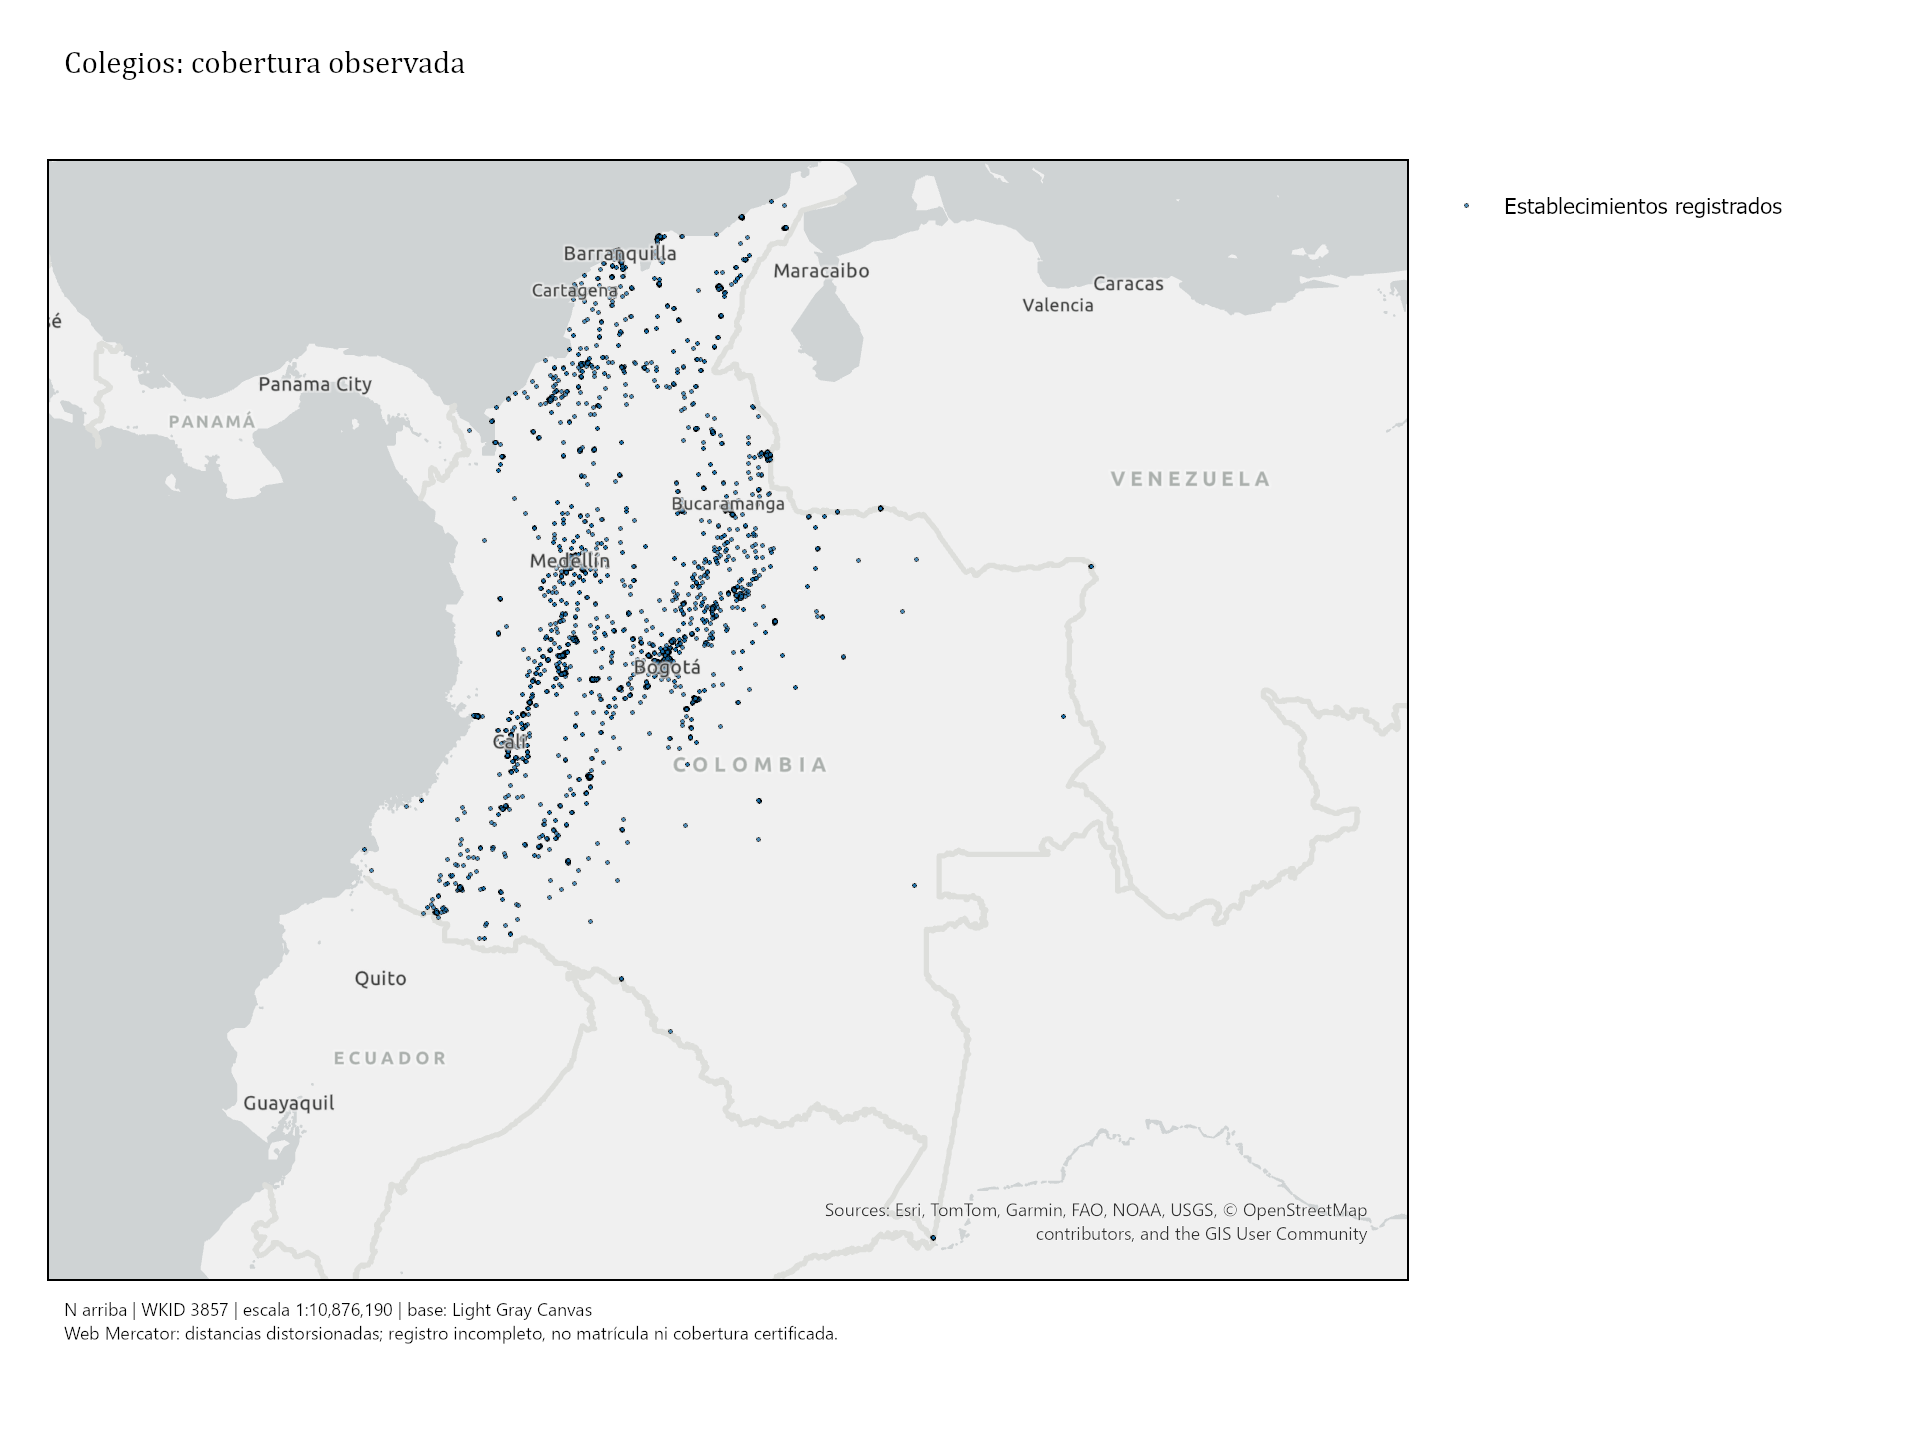

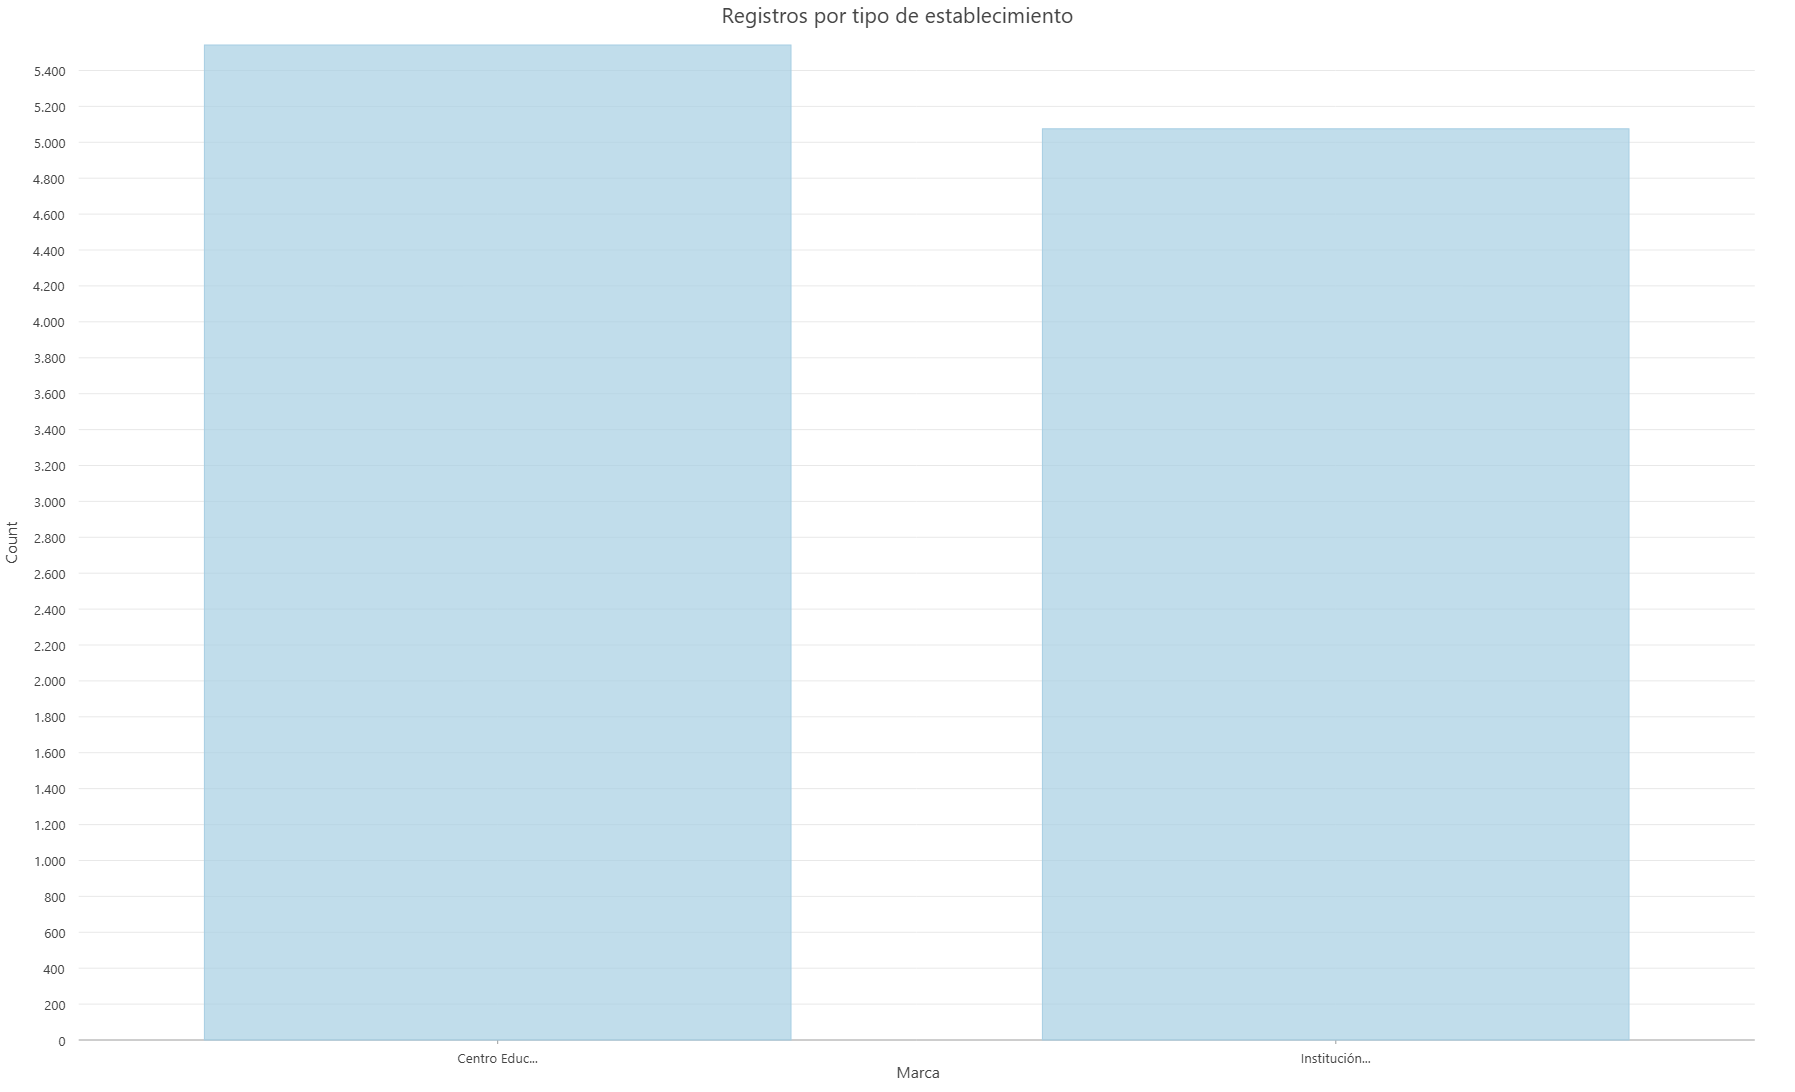

In [20]:
# Copia necesaria para resultados locales; conserva coordenadas, sin Integrate.
working = str(Path(gdb) / 'Colegios')
arcpy.management.CopyFeatures(source, working)
geometry_table = str(Path(gdb) / 'CheckGeometry_Colegios')
geometry_result = arcpy.management.CheckGeometry(working, geometry_table)
print(geometry_result.getMessages())
geometry_errors = int(arcpy.management.GetCount(geometry_table)[0])
print('Problemas geométricos en copia:', geometry_errors)
if geometry_errors:
    raise ValueError('Geometría inválida: detener, sin reparar ni descartar registros.')
map_png(working, 'eda_colegios')
chart_png(arcpy.charts.Bar(x='Tipo', aggregation='COUNT', dataSource=working, title='Registros por tipo de establecimiento'), 'eda_tipo')


Observa dónde se concentra el registro, sin asumir cobertura nacional completa. Las barras son cantidad de filas por categoría, no cantidad de estudiantes. La extensión puede ocultar establecimientos coincidentes; el conteo posterior hace visible esa multiplicidad, no incorpora escuelas faltantes.

## Collect Events y soporte
Coincidencia exacta significa misma XY, no puntos a menos de diez metros. Se verifica igualdad de coordenadas y conteos por sitio, además de suma total. Si ICOUNT es constante se detiene el contraste; no se mueve geometría para fabricar variación.

### Contar coincidencias sin desplazar

Collect Events agrupa solo XY idénticas. No hay Integrate ni tolerancia de cercanía. Analogía: tarjetas que ya comparten casilla se cuentan, no se mueven. Igualdad de coordenadas y conteos por sitio protege la contabilidad.

In [21]:
# Pasar de registros a sitios conservando suma y posición; no deduplicar.
# Agregación de eventos exactos; entradas originales nunca se actualizan.
weighted = str(Path(gdb) / 'Colegios_ICOUNT')
result = gp_child('CollectEvents', working, weighted)
print(result['messages'])
with arcpy.da.SearchCursor(weighted, ['SHAPE@XY', 'ICOUNT']) as cursor:
    xy_after = {xy: count for xy, count in cursor}
if dict(xy_before) != xy_after or sum(xy_after.values()) != n:
    raise ValueError('No coincide la conservación exacta de XY/conteos: detener.')
print('Registros:', n, 'sitios:', len(xy_after), 'ICOUNT mínimo/máximo:', min(xy_after.values()), max(xy_after.values()))


Hijo CollectEvents PID 28868 | diario: 99 - Recursos/salidas_clase_02/practica_02/hexbin_20260921/ejecucion_b557fbd99b8a/gp_children/CollectEvents_4ae74c4f46b9/process.json


Cierre natural del hijo: 0 | logs: 99 - Recursos/salidas_clase_02/practica_02/hexbin_20260921/ejecucion_b557fbd99b8a/gp_children/CollectEvents_4ae74c4f46b9


Start Time: lunes, 21 de septiembre de 2026 5:28:45 p. m.
Succeeded at lunes, 21 de septiembre de 2026 5:28:48 p. m. (Elapsed Time: 2.27 seconds)
Registros: 10617 sitios: 10262 ICOUNT mínimo/máximo: 1 10


## Describir ICOUNT antes de inferir asociación
Ahora cada fila es un **sitio ocupado**. N es el número de sitios y xᵢ su ICOUNT: COUNT=N, SUM=Σxᵢ recupera los registros originales y media=SUM/N. Analogía: contar tarjetas en casillas ya ocupadas; las vacías no están en la tabla. No conocemos todos los lugares posibles con cero eventos.

MIN/MAX delimitan multiplicidad; mediana es el centro de valores ordenados; moda es el más frecuente (puede haber empates). Q1/Q3 delimitan el 50 % central e IQR=Q3−Q1 mide su amplitud. La desviación muestral s=√[Σ(xᵢ−media)²/(N−1)] expresa dispersión en registros/sitio; la poblacional usa N. Mostrar ambas contrasta convenciones, no demuestra representatividad ni independencia espacial.

ArcPy exporta **solo ICOUNT**, no todos los números, que incluirían IDs. La biblioteca estándar `statistics` permite una comprobación independiente de desviación, media y contabilidad, sin sustituir gráficos o modelos. Los cuartiles se leen de ArcGIS: las convenciones de interpolación pueden diferir.

**Fuentes, consulta 2026-09-16:** Esri Pro 3.6, [Field Statistics To Table](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/data-management/field-statistics-to-table.htm), Parameters/Python; [Interact with statistics](https://pro.arcgis.com/en/pro-app/3.6/help/analysis/geoprocessing/data-engineering/view-statistics.htm), Select fields/Calculate/Types of statistics. La UI documenta N−1; no demuestra la convención del exportador: se contrasta abajo.

In [22]:
# Exportar únicamente el atributo que responde a la pregunta, con nombres explícitos.
stat_mapping = [
    ['FIELDNAME', 'Campo'], ['COUNT', 'Cantidad'], ['NULLS', 'Nulos'],
    ['SUM', 'Suma'], ['MINIMUM', 'Minimo'], ['MAXIMUM', 'Maximo'],
    ['MEAN', 'Media'], ['MEDIAN', 'Mediana'], ['MODE', 'Moda'],
    ['STANDARDDEVIATION', 'Desv'], ['FIRSTQUARTILE', 'Q1'],
    ['THIRDQUARTILE', 'Q3'], ['INTERQUARTILERANGE', 'InterquartileRange'],
]
statistics_result = gp_child('FieldStatisticsToTable', 
    weighted, ['ICOUNT'], gdb, [['NUMERIC', 'Descriptivos_ICOUNT']],
    out_statistics=stat_mapping,
)
print(statistics_result['messages'])
stats_table = str(Path(gdb) / 'Descriptivos_ICOUNT')
stat_fields = [pair[1] for pair in stat_mapping]
actual_fields = {field.name for field in arcpy.ListFields(stats_table)}
if not set(stat_fields).issubset(actual_fields):
    raise ValueError('La tabla no contiene los nombres solicitados; revisar esquema.')
with arcpy.da.SearchCursor(stats_table, stat_fields) as cursor:
    statistic_rows = list(cursor)
if len(statistic_rows) != 1:
    raise ValueError('Se esperaba una fila estadística para ICOUNT.')
stats = dict(zip(stat_fields, statistic_rows[0]))
# Pro 3.6.2 conserva este nombre físico para IQR; se declara la equivalencia lógica.
stats['IQR'] = stats['InterquartileRange']
print('Tabla ArcGIS, sin selección ni agrupación:', stats)


Hijo FieldStatisticsToTable PID 16596 | diario: 99 - Recursos/salidas_clase_02/practica_02/hexbin_20260921/ejecucion_b557fbd99b8a/gp_children/FieldStatisticsToTable_d235894a8b9e/process.json


Cierre natural del hijo: 0 | logs: 99 - Recursos/salidas_clase_02/practica_02/hexbin_20260921/ejecucion_b557fbd99b8a/gp_children/FieldStatisticsToTable_d235894a8b9e


Start Time: lunes, 21 de septiembre de 2026 5:28:57 p. m.
Succeeded at lunes, 21 de septiembre de 2026 5:29:00 p. m. (Elapsed Time: 2.72 seconds)


Tabla ArcGIS, sin selección ni agrupación: {'Campo': 'ICOUNT', 'Cantidad': 10262, 'Nulos': 0, 'Suma': 10617.0, 'Minimo': 1.0, 'Maximo': 10.0, 'Media': 1.034593646462678, 'Mediana': 1.0, 'Moda': 1.0, 'Desv': 0.2173453196291477, 'Q1': 1.0, 'Q3': 1.0, 'InterquartileRange': 0.0, 'IQR': 0.0}


Una fila resume ICOUNT, no un sitio. Cantidad cuenta valores no nulos; Suma conserva registros. La siguiente celda verifica estas identidades y distingue N de N−1 antes de interpretar dispersión.

**Esquema observado Pro 3.6.2:** el campo de rango intercuartílico se conserva como `InterquartileRange`; `IQR` es solo su nombre lógico en el diccionario Python. No se asume que el exportador siempre acepte abreviaturas.

In [23]:
# Contrastar fórmulas sin modificar registros; statistics es biblioteca estándar, no un SIG alternativo.
import statistics
with arcpy.da.SearchCursor(weighted, ['ICOUNT']) as cursor:
    icount = [row[0] for row in cursor]
if any(value is None or value < 1 or int(value) != value for value in icount):
    raise ValueError('ICOUNT requiere conteos enteros positivos en sitios ocupados.')
frequency_icount = Counter(icount)
n_sites, n_records = len(icount), sum(icount)
sample_sd = statistics.stdev(icount)
population_sd = statistics.pstdev(icount)
mean_icount = statistics.mean(icount)
checks = {'Cantidad': n_sites, 'Nulos': 0, 'Suma': n_records,
          'Minimo': min(icount), 'Maximo': max(icount),
          'Media': mean_icount, 'Mediana': statistics.median(icount)}
for field, expected in checks.items():
    if not math.isclose(float(stats[field]), expected, rel_tol=1e-10, abs_tol=1e-10):
        raise ValueError(f'Descriptivo no conciliado: {field}.')
match_sample = math.isclose(stats['Desv'], sample_sd, rel_tol=1e-10, abs_tol=1e-12)
match_population = math.isclose(stats['Desv'], population_sd, rel_tol=1e-10, abs_tol=1e-12)
if not (match_sample or match_population):
    raise ValueError('Desviación exportada no coincide con N ni N−1; investigar.')
sd_convention = ('indistinguible entre N y N−1' if match_sample and match_population
                 else 'N−1 (muestral)' if match_sample else 'N (poblacional)')
if not math.isclose(stats['IQR'], stats['Q3'] - stats['Q1'], abs_tol=1e-10):
    raise ValueError('IQR no coincide con Q3−Q1.')
print('Frecuencia exacta ICOUNT → sitios:', dict(sorted(frequency_icount.items())))
print(f'Desviación exportada={stats["Desv"]:.12f}; stdev={sample_sd:.12f}; pstdev={population_sd:.12f}')
print('Convención OBSERVADA de la tabla:', sd_convention)
print('UI documenta N−1: comparar población/selección antes de equiparar resultados.')
print('Moda(s) por frecuencia:', statistics.multimode(icount), '| Moda exportada:', stats['Moda'])


Frecuencia exacta ICOUNT → sitios: {1: 9944, 2: 293, 3: 20, 4: 3, 5: 1, 10: 1}
Desviación exportada=0.217345319629; stdev=0.217345319629; pstdev=0.217334729558
Convención OBSERVADA de la tabla: N−1 (muestral)
UI documenta N−1: comparar población/selección antes de equiparar resultados.
Moda(s) por frecuencia: [1] | Moda exportada: 1.0


**Lectura del contraste:** la concordancia acredita cálculo sobre el mismo soporte, no calidad administrativa. La convención se decide por las comparaciones numéricas, no por el nombre Desv.

### Centro y extremos sin limpieza
La proporción singleton (ICOUNT=1) muestra cuánto domina el mínimo. Cercas Q1−1.5·IQR y Q3+1.5·IQR son una regla descriptiva: con IQR=0 pueden marcar todos los conteos >1. No se elimina nada. Máximo, su frecuencia y asimetría de momento describen cola, no significancia.

**Antes de leer asimetría:** promedio de cubos de desviaciones dividido por desviación poblacional al cubo; medida adimensional. Positiva indica cola hacia multiplicidades altas, no errores ni prueba de normalidad. Se interpreta con mediana/cuartiles/máximo, sin cambiar registros.

In [24]:
# Interpretar sitios y cola sin convertir multiplicidad en riesgo ni borrar extremos.
singletons = frequency_icount[1]
lower_fence = stats['Q1'] - 1.5 * stats['IQR']
upper_fence = stats['Q3'] + 1.5 * stats['IQR']
flagged = sum(value < lower_fence or value > upper_fence for value in icount)
# Tercer momento estandarizado descriptivo; no es prueba de normalidad.
skew_moment = (sum((value - mean_icount) ** 3 for value in icount) / n_sites
               / population_sd ** 3) if population_sd else None
print(f'{n_records:,} registros en {n_sites:,} sitios; media={mean_icount:.6f} registros/sitio ocupado.')
print(f'Mediana={stats["Mediana"]}; moda={stats["Moda"]}; mínimo={stats["Minimo"]}; máximo={stats["Maximo"]}.')
print(f'Sitios con un solo registro: {singletons:,}/{n_sites:,} = {singletons/n_sites:.2%}.')
print(f'Q1={stats["Q1"]}; Q3={stats["Q3"]}; IQR={stats["IQR"]}; cercas=[{lower_fence}, {upper_fence}].')
print(f'Fuera de cercas: {flagged:,} sitios ({flagged/n_sites:.2%}); no se borra ninguno.')
if stats['IQR'] == 0:
    print('IQR degenerado: el 50 % central coincide. Marcar otros valores no demuestra errores.')
print(f'Máximo: {max(icount)} registros/sitio en {frequency_icount[max(icount)]} sitios.')
print('Asimetría de momento:', skew_moment, '| cola de multiplicidad, no evidencia de normalidad.')
print('La media no es riesgo/tasa: faltan exposición, sitios con cero y denominador poblacional.')
print('El histograma pierde posición; el mapa muestra dónde están los conteos, no sus causas.')


10,617 registros en 10,262 sitios; media=1.034594 registros/sitio ocupado.
Mediana=1.0; moda=1.0; mínimo=1.0; máximo=10.0.
Sitios con un solo registro: 9,944/10,262 = 96.90%.
Q1=1.0; Q3=1.0; IQR=0.0; cercas=[1.0, 1.0].
Fuera de cercas: 318 sitios (3.10%); no se borra ninguno.
IQR degenerado: el 50 % central coincide. Marcar otros valores no demuestra errores.
Máximo: 10 registros/sitio en 1 sitios.
Asimetría de momento: 12.11499788460778 | cola de multiplicidad, no evidencia de normalidad.
La media no es riesgo/tasa: faltan exposición, sitios con cero y denominador poblacional.
El histograma pierde posición; el mapa muestra dónde están los conteos, no sus causas.


En la ejecución histórica, la mediana y la moda son 1, pero la media es 1.034594; 96.90 % de los sitios tienen un registro. IQR=0 concentra el centro, no todos los datos. La cola eleva la media; las cercas no justifican limpieza.

### Distribución discreta: tabla completa, barras, caja y mapa
Primero mira las barras de todos los sitios. Después amplía la parte menos frecuente: sitios con más de un registro. Ese segundo panel no elimina datos; solo permite ver una minoría que la barra de un registro podría ocultar. La tabla conserva los conteos exactos y los intervalos de la cola se indican en las etiquetas. La caja resume mediana y cuartiles; si IQR=0, puede verse como una línea. Los puntos fuera de sus cercas no son, por eso, errores.

El mapa separa 1 y 2 y agrupa la cola; verde claro/oscuro significa menos/más registros, no frío/calor inferencial. Fuente: elaboración docente con datos ejecutados; Esri Pro 3.6 [Bar](https://pro.arcgis.com/en/pro-app/3.6/arcpy/charts/bar.htm) y [Box](https://pro.arcgis.com/en/pro-app/3.6/arcpy/charts/box.htm), Syntax/Parameters/Methods, consulta 2026-09-16.


En las barras, 01 a 10 son conteos exactos; los prefijos 11., 12., 13. y 14. ordenan intervalos de la cola, no son valores adicionales. Los puntos del eje vertical son separadores de miles cuando así los presenta ArcGIS; lea la tabla exacta para evitar ambigüedad.
Aquí el máximo observado es 10: no aparecen intervalos de la cola superior a diez.

Campo,Tipo,Rol,Unidad,Ejemplo,Nulos / cero
ICOUNT,Integer,Registros originales con XY idéntica,registros por sitio,1,No hay nulos ni ceros: sitios sin registros no se incorporan


ICOUNT exacto,Sitios,Porcentaje de sitios
1,9944,96.901
2,293,2.855
3,20,0.195
4,3,0.029
5,1,0.01
10,1,0.01


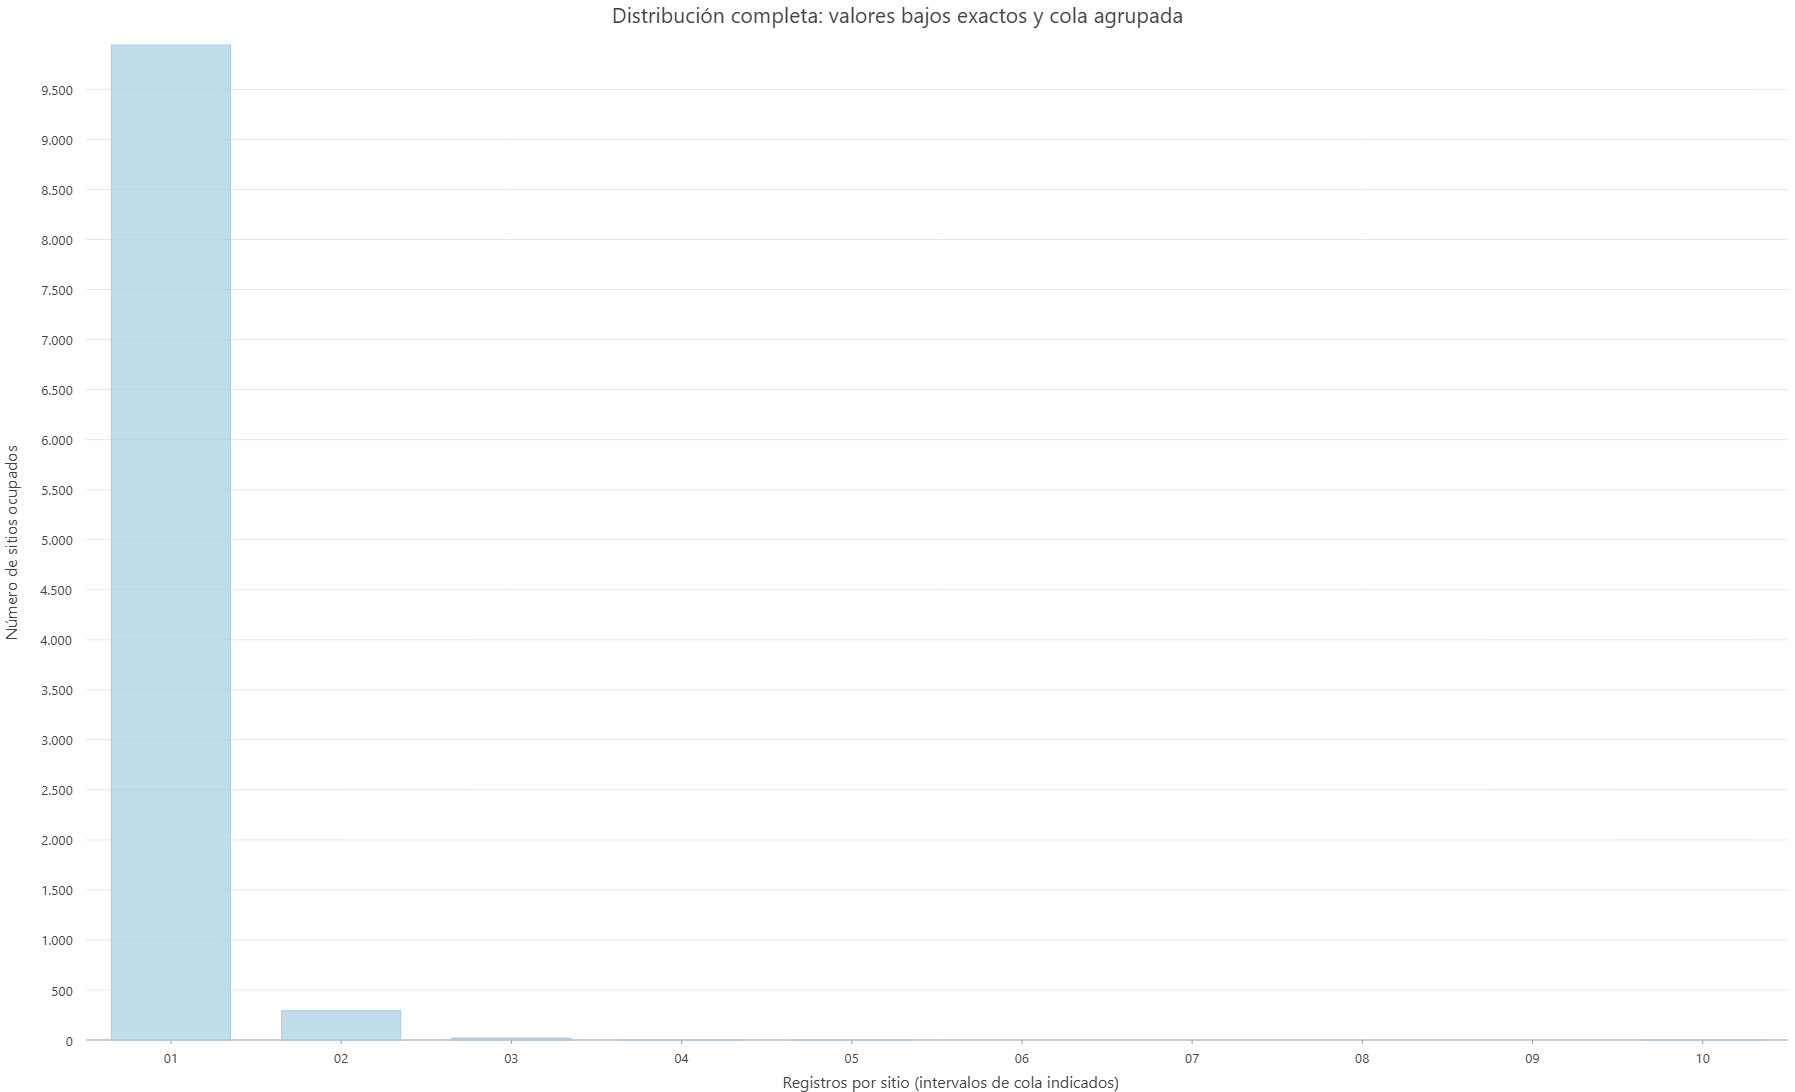

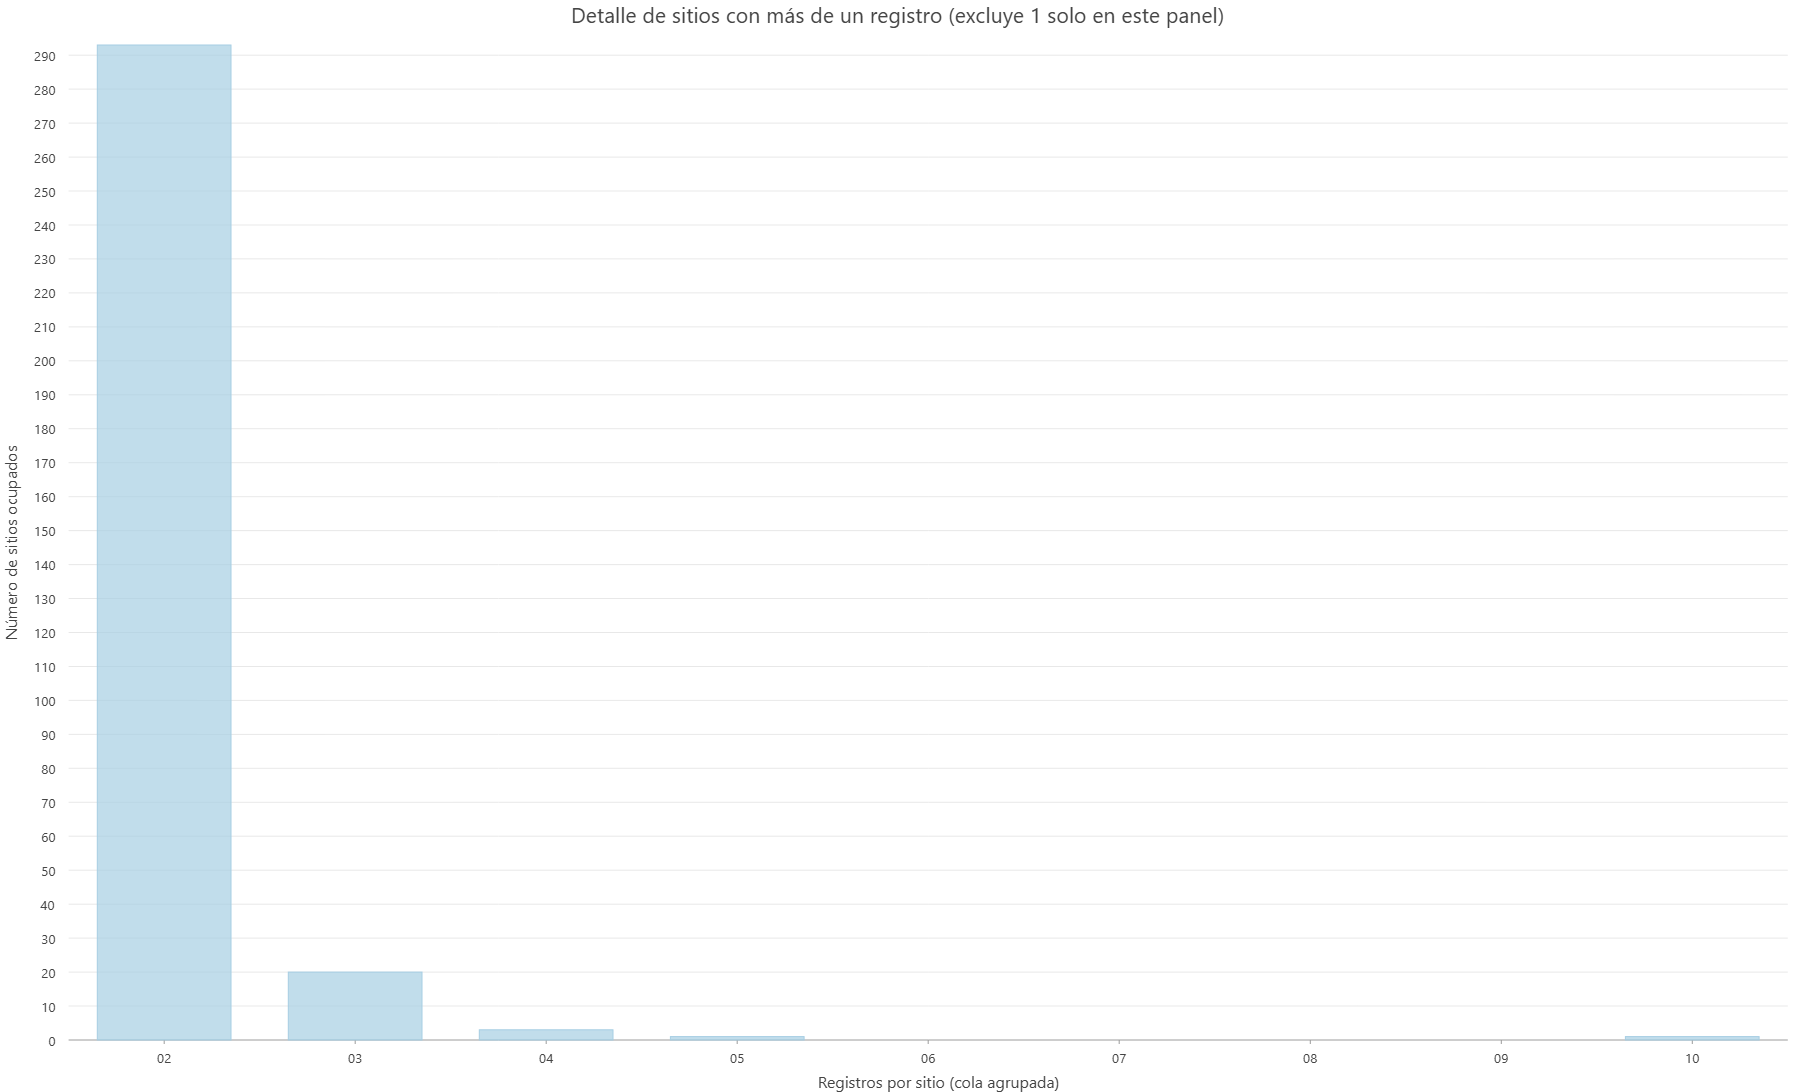

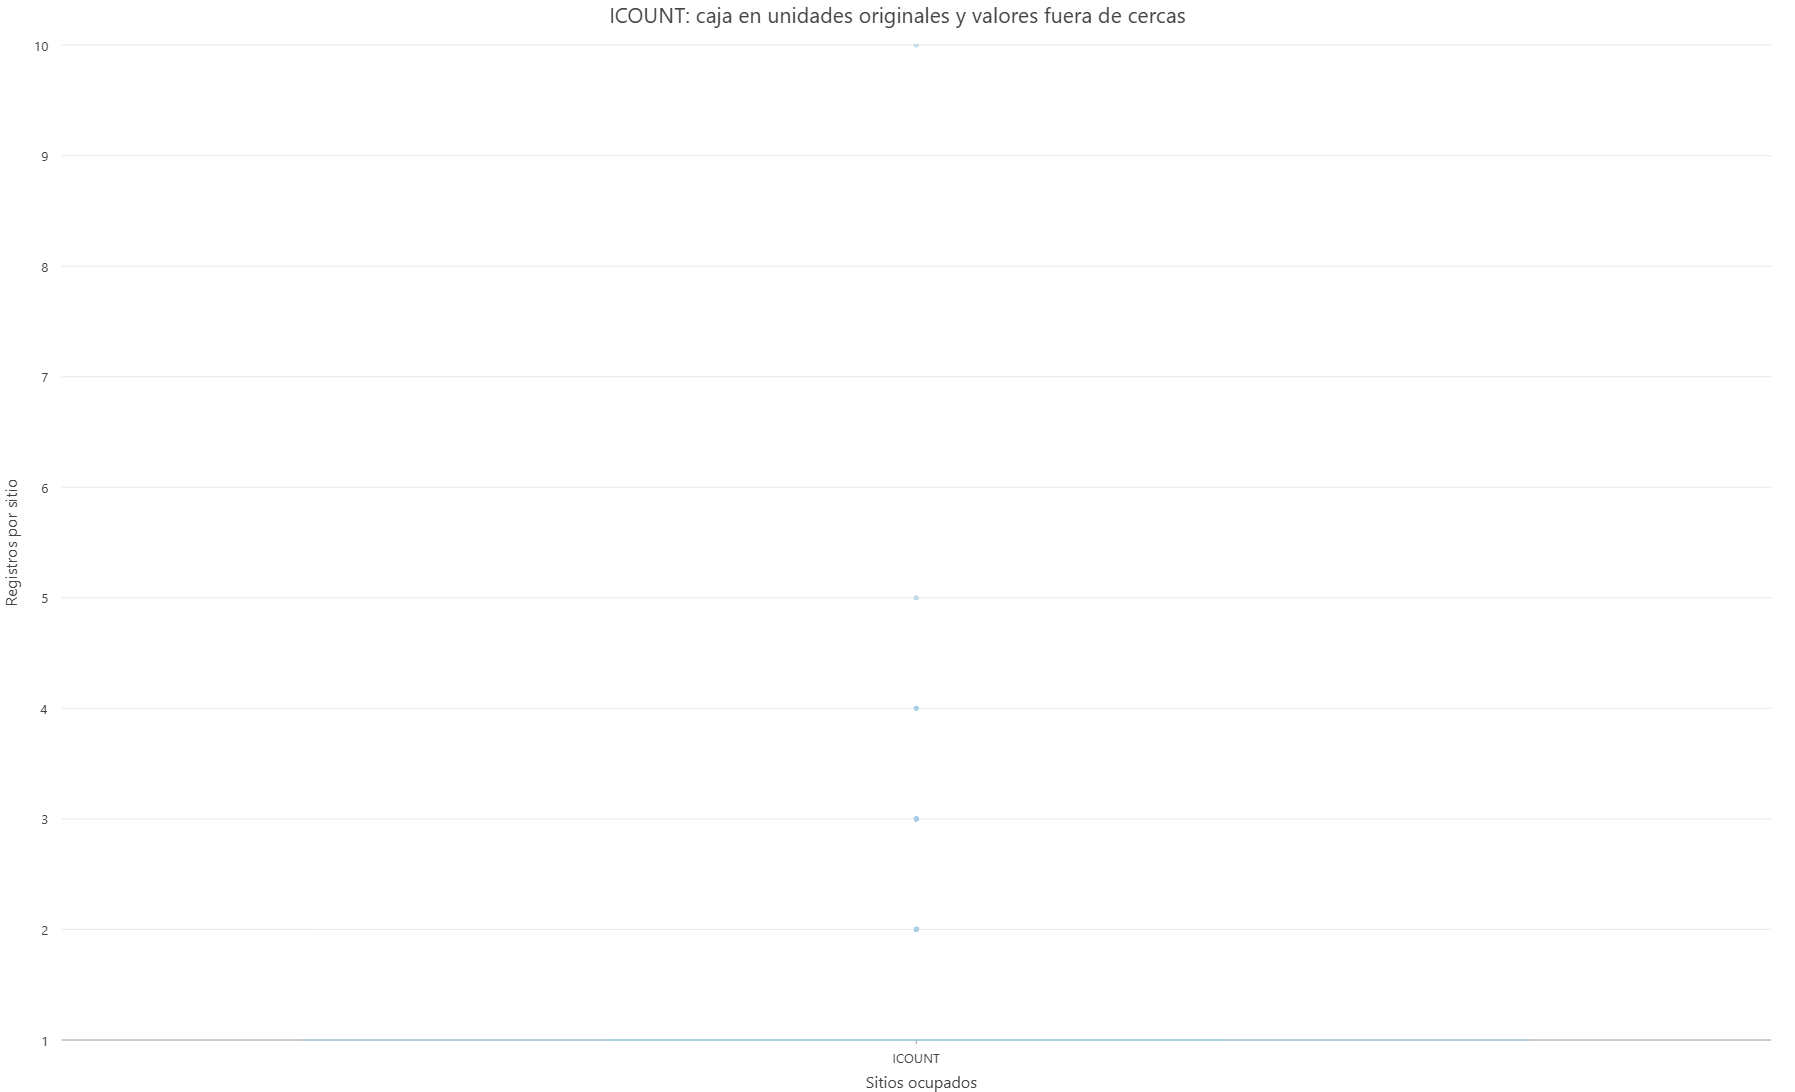

Lectura: 9,944 sitios tienen un registro; 318 tienen más de uno; máximo=10.
Q1=1.0; Q3=1.0; IQR=0.0. Caja colapsada en 1: valores mayores no son errores a eliminar.


Base en línea: Light Gray Canvas | Esri y colaboradores; atribución dentro del mapa.


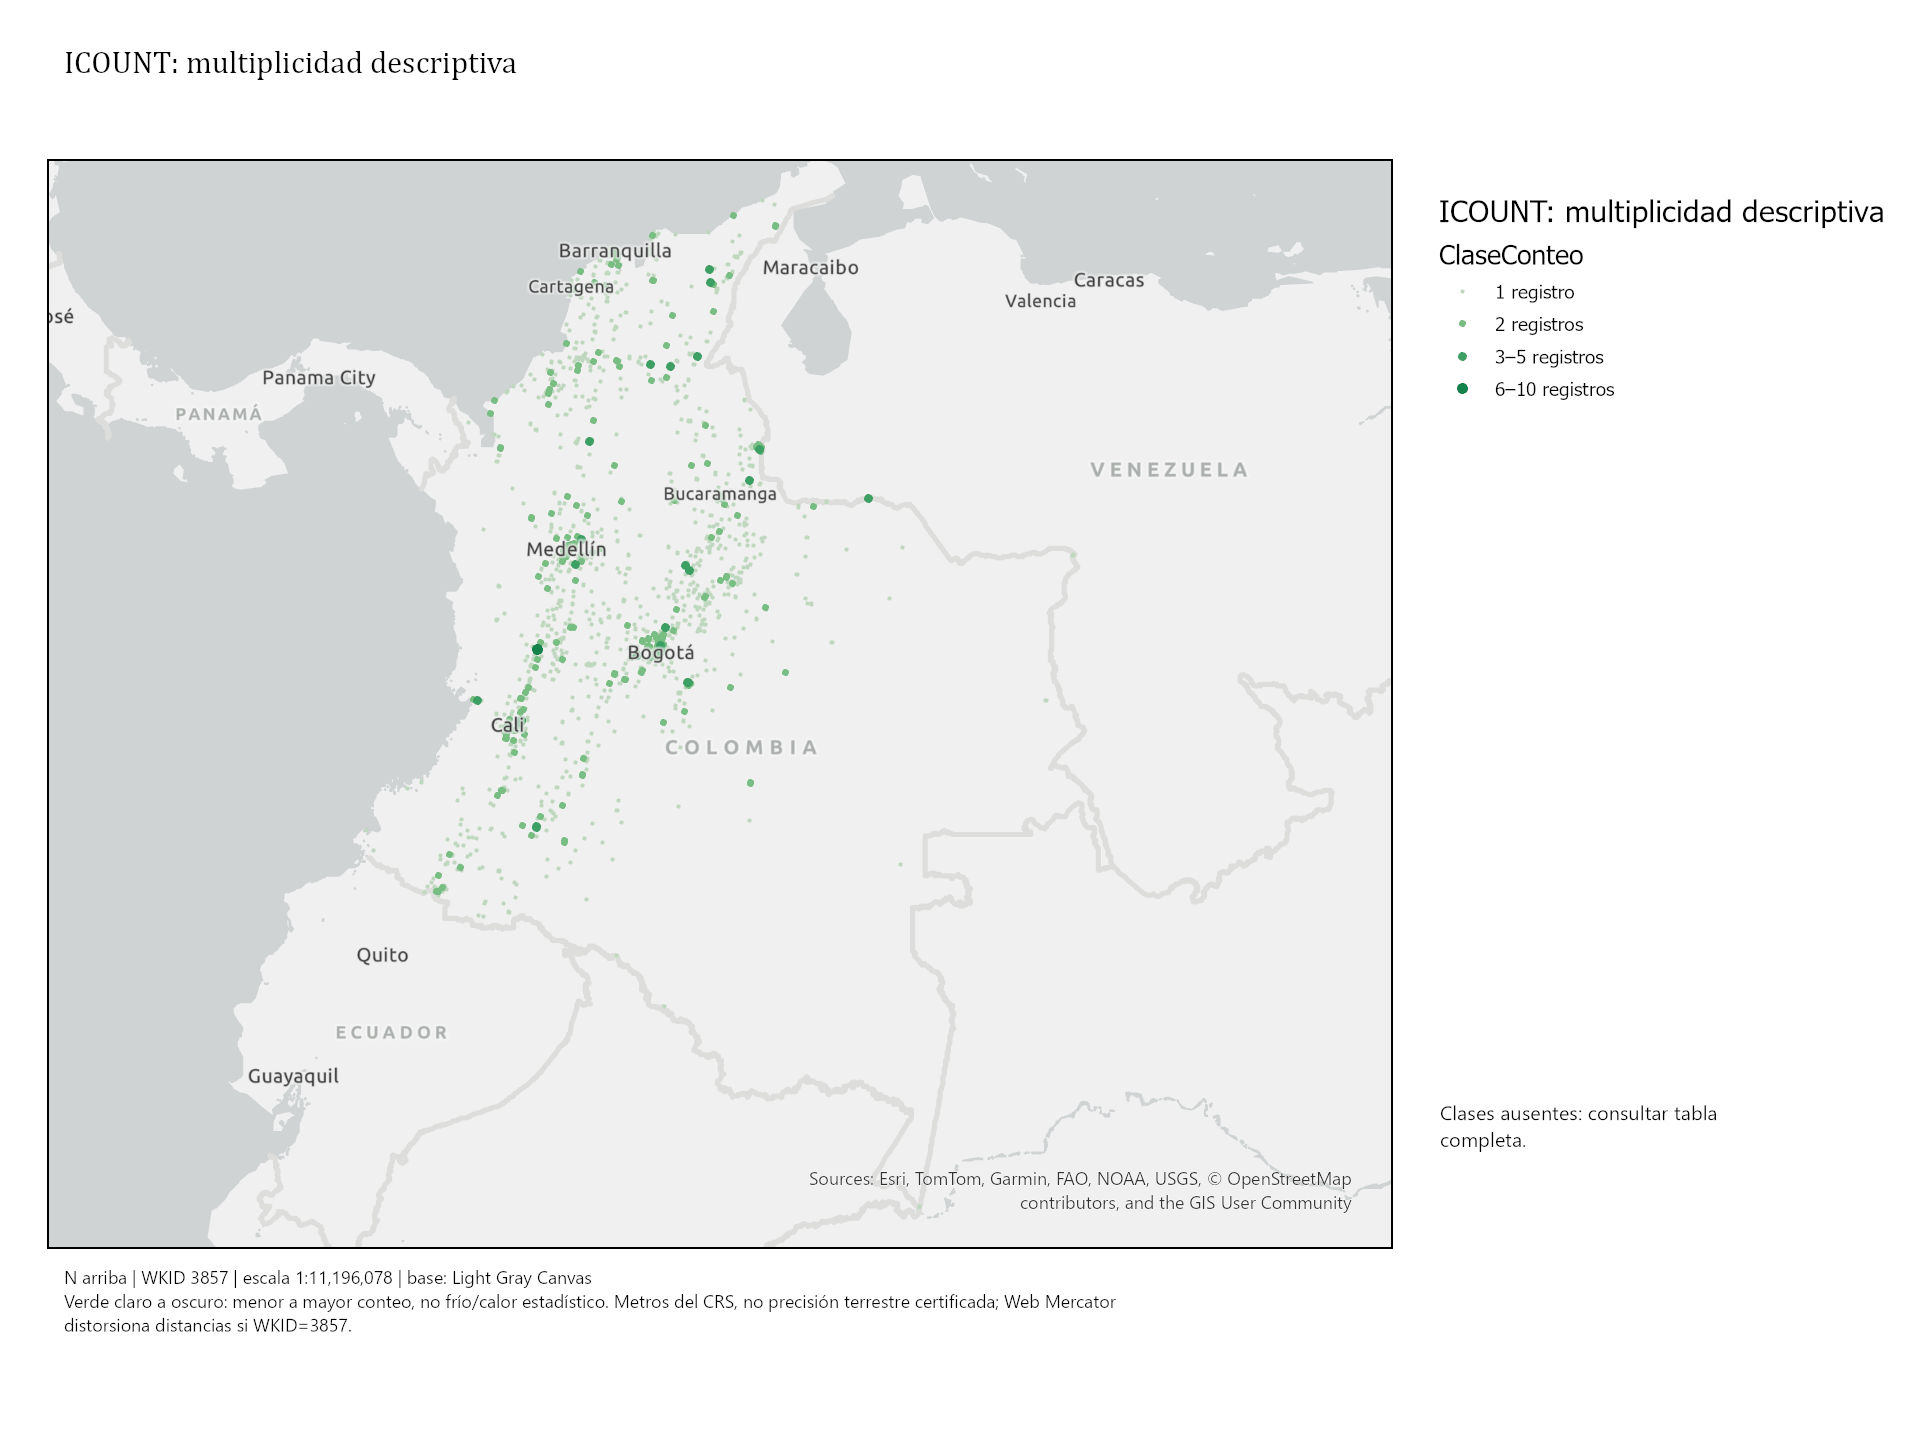

In [25]:
# Frecuencia exacta: denominador = sitios ocupados, no todo el territorio.
tabla_visible(['Campo', 'Tipo', 'Rol', 'Unidad', 'Ejemplo', 'Nulos / cero'], [
    ['ICOUNT', next(f.type for f in arcpy.ListFields(weighted) if f.name == 'ICOUNT'),
     'Registros originales con XY idéntica', 'registros por sitio', min(icount),
     'No hay nulos ni ceros: sitios sin registros no se incorporan'],
])
tabla_visible(['ICOUNT exacto', 'Sitios', 'Porcentaje de sitios'],
              [[value, count, round(100*count/n_sites, 3)] for value,count in sorted(frequency_icount.items())])
# Valores 1 a 10 exactos; cola agrupada explícitamente, sin truncar el total.
frequency_rows = [(f'{v:02d}', frequency_icount[v]) for v in range(1, min(10, int(max(icount)))+1)]
for lower, upper, label in [(11,20,'11. 11–20'), (21,50,'12. 21–50'), (51,100,'13. 51–100'), (101,int(max(icount)),'14. 101+')]:
    if max(icount) >= lower:
        frequency_rows.append((label, sum(count for value,count in frequency_icount.items() if lower <= value <= upper)))
assert sum(count for _,count in frequency_rows) == n_sites
frequency_table = tabla_frecuencia('Frecuencia_legible', frequency_rows)
chart_png(arcpy.charts.Bar(x='Categoria', y='Sitios', aggregation='SUM', dataSource=frequency_table,
    title='Distribución completa: valores bajos exactos y cola agrupada',
    xTitle='Registros por sitio (intervalos de cola indicados)', yTitle='Número de sitios ocupados'), 'frecuencia_completa')
# Panel sin 1: no altera el universo, permite leer la cola minoritaria.
tail_table = tabla_frecuencia('Frecuencia_cola', frequency_rows[1:])
chart_png(arcpy.charts.Bar(x='Categoria', y='Sitios', aggregation='SUM', dataSource=tail_table,
    title='Detalle de sitios con más de un registro (excluye 1 solo en este panel)',
    xTitle='Registros por sitio (cola agrupada)', yTitle='Número de sitios ocupados'), 'frecuencia_cola')
chart_png(arcpy.charts.Box(y='ICOUNT', standardizeValues=False, showOutliers=True,
    dataSource=weighted, title='ICOUNT: caja en unidades originales y valores fuera de cercas',
    xTitle='Sitios ocupados', yTitle='Registros por sitio'), 'caja_icount')
print(f'Lectura: {frequency_icount[1]:,} sitios tienen un registro; {n_sites-frequency_icount[1]:,} tienen más de uno; máximo={max(icount)}.')
print(f'Q1={stats["Q1"]}; Q3={stats["Q3"]}; IQR={stats["IQR"]}. Caja colapsada en 1: valores mayores no son errores a eliminar.')
# Clasificar únicamente la salida nueva; las clases descriptivas no son significancia.
arcpy.management.AddField(weighted, 'ClaseConteo', 'TEXT', field_length=30)
with arcpy.da.UpdateCursor(weighted, ['ICOUNT','ClaseConteo']) as cursor:
    for row in cursor:
        value = row[0]
        row[1] = '01' if value == 1 else '02' if value == 2 else '03' if value <= 5 else '04' if value <= 10 else '05' if value <= 50 else '06'
        cursor.updateRow(row)
count_styles = {
    '01': ('1 registro', [190,215,190,100], 2),
    '02': ('2 registros', [120,190,130,100], 3),
    '03': ('3–5 registros', [60,160,100,100], 4),
    '04': ('6–10 registros', [20,130,75,100], 5),
    '05': ('11–50 registros', [0,95,50,100], 6),
    '06': ('51–máximo registros', [0,55,30,100], 7),
}
mapa_categorias(weighted, 'ClaseConteo', 'mapa_icount_legible', 'ICOUNT: multiplicidad descriptiva', count_styles,
    'Verde claro a oscuro: menor a mayor conteo, no frío/calor estadístico. Metros del CRS, no precisión terrestre certificada; Web Mercator distorsiona distancias si WKID=3857.')


Usa las cifras calculadas bajo los gráficos: el panel completo conserva el denominador; la cola excluye 1 únicamente de la vista. Frecuencia cero en un intervalo significa cero sitios con esa multiplicidad, no territorios sin actividad. La caja colapsada expresa concentración, no una falla de dibujo. No se retiran valores fuera de las cercas.

### Data Engineering: ejercicio manual opcional sobre la copia
**Pasos documentados, no ejecutados ni verificados en la interfaz de Pro en esta corrida.** No se inventa `arcpy.DataEngineering`.
1. Abra el APRX de sitios de esta ejecución: apunta a `trabajo.gdb`, no al original. Añada desde esa misma GDB la copia previa a Collect Events, para distinguir registros de sitios.
2. En esa copia abra Data Engineering; añada **Tipo y Ciudad** con **Add To Statistics** o arrastrándolos; pulse **Calculate**. No agregue IDs/códigos para obtener medias. No active limpieza.
3. Examine frecuencias y previsualización de barras para categorías; contraste cobertura con mapa. Inspeccione Nulls y seleccione los nulos desde su estadística cuando existan. Un cero no es un nulo; no reemplace ni elimine. Anote número seleccionado y total.
4. Quite la selección. En la capa de sitios añada **ICOUNT** y calcule: COUNT=sitios, SUM=registros; centro/dispersión describen multiplicidad. Abra el histograma numérico y relaciónelo con el mapa graduado.
5. Seleccione temporalmente ICOUNT > 1 y recalcule: cambia el denominador. Esas estadísticas no deben coincidir con toda la capa. Quite la selección y calcule otra vez.
6. Abra `Descriptivos_ICOUNT` y compare campo, población, nulos, COUNT, SUM, media y cuartiles. La UI documenta desviación N−1: consulte la convención **observada** del exportador (puede ser N) antes de atribuir diferencias a datos sucios.
7. Documente su observación manual aparte; no guarde cambios sobre originales, no repare, deduplique ni impute. Este itinerario no equivale a interacción ejecutada.

Fuente: Esri, Pro 3.6, [Interact with statistics](https://pro.arcgis.com/en/pro-app/3.6/help/analysis/geoprocessing/data-engineering/view-statistics.htm), selección/cálculo/tipos; consulta del 2026-09-16.

### Histograma del soporte ocupado
El histograma reúne los valores de ICOUNT en intervalos: el eje horizontal muestra registros por sitio y el vertical, cuántos sitios caen en cada intervalo. Si aparecen límites decimales, son bordes de los intervalos, no fracciones de colegio. Las barras anteriores permiten recuperar los conteos enteros exactos. Ninguno de estos gráficos indica todavía significancia espacial.

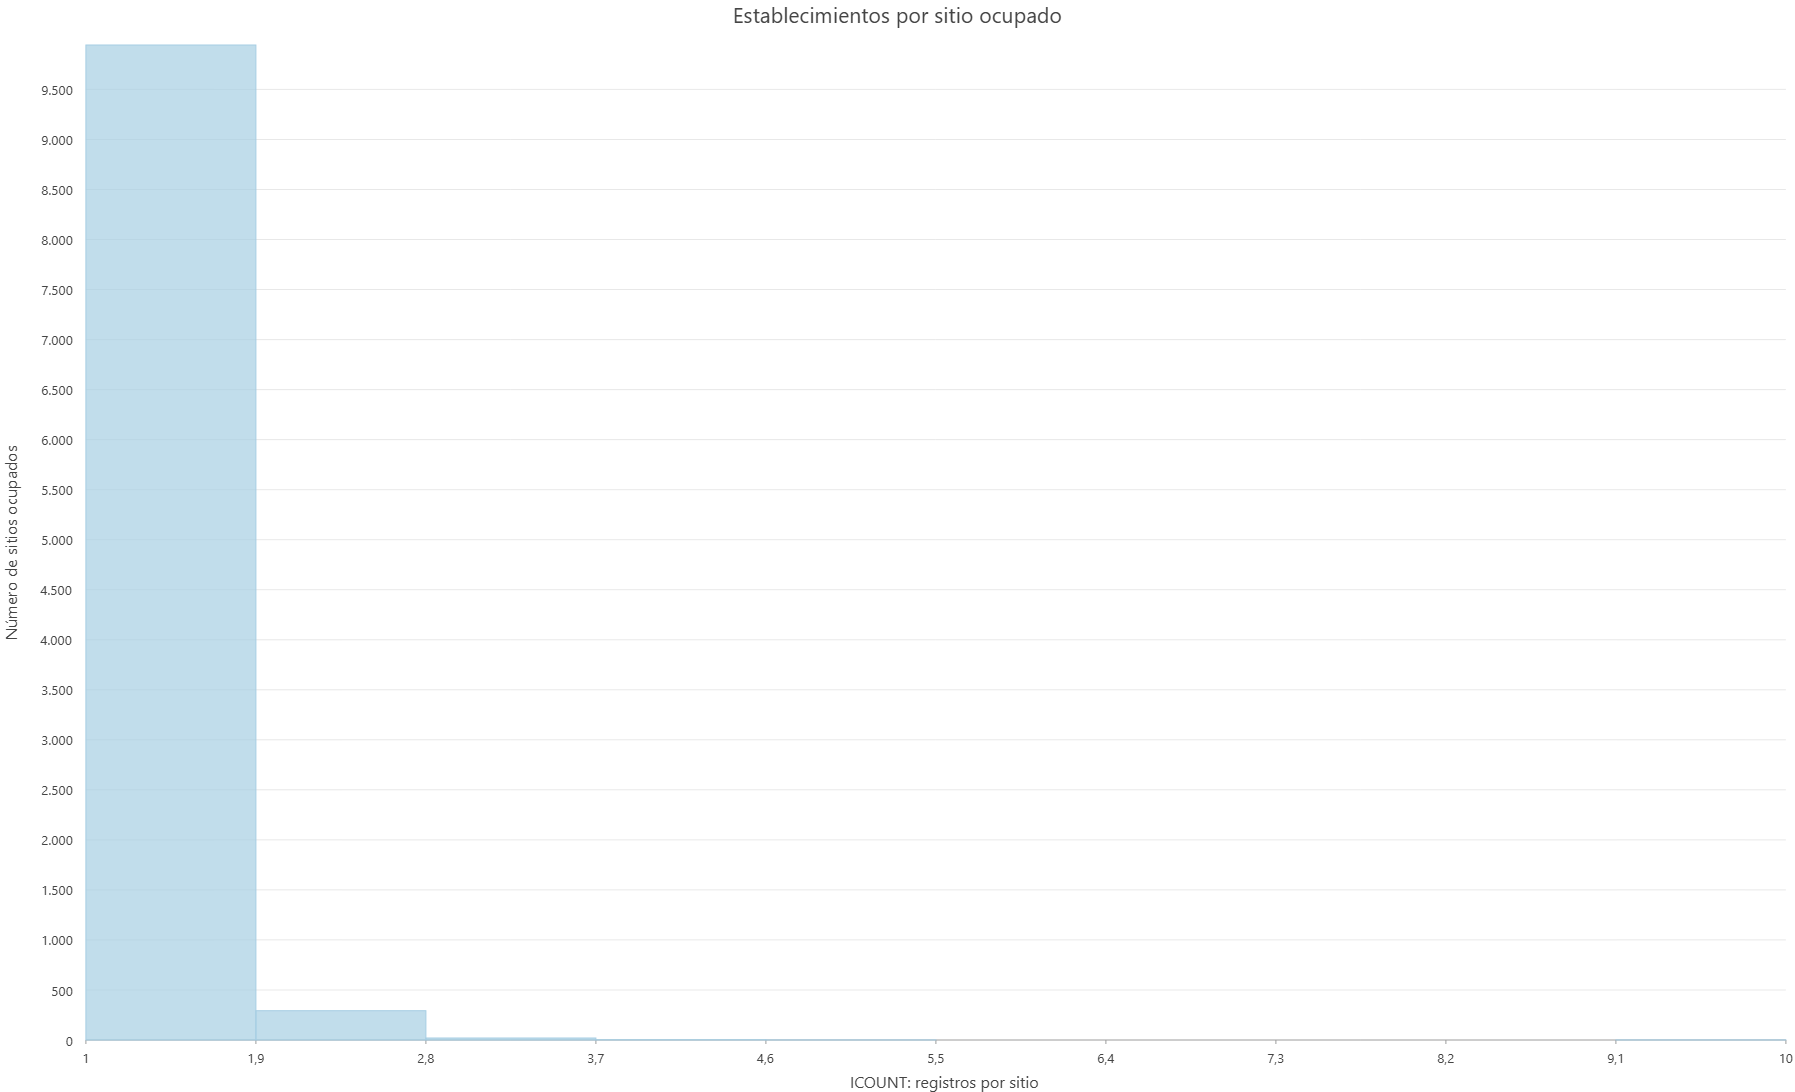

In [26]:
# Relacionar distribución de multiplicidad con ubicación, sin inferir riesgo.
chart_png(arcpy.charts.Histogram(x='ICOUNT', dataSource=weighted, binCount=min(20, int(max(icount))), xTitle='ICOUNT: registros por sitio', yTitle='Número de sitios ocupados', title='Establecimientos por sitio ocupado'), 'histograma_icount')
if len(set(xy_after.values())) < 2:
    raise ValueError('ICOUNT constante; Moran no definido para este atributo.')

El símbolo graduado representa conteo, no matrícula o calidad. El histograma representa cantidad de sitios por valor de ICOUNT. La suma comprobada conserva establecimientos registrados; no permite distinguir varios colegios de un registro administrativo duplicado.

## Escala regional: 20 bandas de 2 km
Inicio 2 000, paso 2 000, veinte bandas previstas hasta 40 000 m; se enseña la corrección de unidades sin ejecutar una corrida errónea de 2 m. Una banda es radio acumulativo, no diámetro ni anillo. EUCLIDEAN y ROW_STANDARDIZATION son los códigos de esta herramienta. Mantener tabla completa y mensajes; si ArcGIS ajusta el rango, las distancias reales mandan sobre las solicitadas.

### Leer Moran sin convertirlo en un mapa de riesgo
**Pregunta:** ¿se parecen los valores **ICOUNT** entre sitios ocupados vecinos? No contrasta directamente densidad de puntos originales ni identifica por sí solo un hotspot local.

Bajo H₀, los valores se distribuyen aleatoriamente entre los sitios del soporte analizado, con la regla de vecindad fijada; no se contrasta la ubicación aleatoria de todas las viviendas o colegios posibles. ROW estandariza los pesos de cada fila para que sumen uno donde hay vecinos.

| Columna | Lectura sencilla |
|---|---|
| Distance | Distancia efectiva en metros del CRS; modifica vecinos. En incremental son radios acumulados, no anillos. |
| MoransI / I | Asociación adimensional entre desviaciones de ICOUNT de vecinos. Comparar con esperado y pesos: no tiene límites universales −1/+1 ni expresa porcentaje de riesgo. |
| ExpectedI | Esperado bajo H₀ y el soporte/pesos empleados; leer cada fila, sin imponer el número original de sitios a todas las bandas. |
| Variance | Variabilidad de **I bajo H₀**, no varianza de ICOUNT, coordenadas o distancias. Se usa para estandarizar. |
| z_score / ZScore | (I−ExpectedI)/√Variance: cuántas desviaciones nulas separan observado y esperado. Signo=encima/debajo del esperado, no bueno/malo. |
| p_value / PValue | Compatibilidad de un resultado al menos tan extremo con H₀; no probabilidad de que H₀ sea cierta. 0 mostrado significa por debajo de la precisión de representación/cálculo, no probabilidad matemáticamente nula. |

I por encima del esperado favorece semejanza vecinal; por debajo, contraste, condicionado a pesos y soporte. Un z grande y p pequeño puede acompañar I pequeño: significancia no es magnitud ni causalidad. El 95 % es referencia **nominal de un contraste fijado**, no corrección después de mirar curvas. Primer/máximo pico local de z y máximo numérico no son lo mismo. Conservar todas las bandas; seleccionar pico o segunda exploración con los mismos datos no es validación independiente. Fuente: Esri Pro 3.6, interpretación de Moran e incremental; referencias completas al final.

In [27]:
# Evaluar bandas previstas y conservar distancias reales y mensajes completos.
def incremental(name, bands, beginning, step):
    table = str(Path(gdb) / name)
    report = str(run / (name + '.pdf'))
    result = gp_child('IncrementalSpatialAutocorrelation', weighted, 'ICOUNT', bands, beginning, step, 'EUCLIDEAN', 'ROW_STANDARDIZATION', table, report)
    print('Solicitado:', bands, beginning, step, '|', result['messages'])
    columns = ['Distance', 'MoransI', 'ExpectedI', 'Variance', 'z_score', 'p_value']
    if not set(columns).issubset({f.name for f in arcpy.ListFields(table)}):
        raise ValueError('Tabla con esquema distinto; inspeccionar sin inventar campos.')
    with arcpy.da.SearchCursor(table, columns) as cursor:
        rows = sorted(list(cursor))
    print(columns)
    for row in rows:
        print(row)
    # Descargar bytes reales: no depender de una carpeta de ejecución fija.
    import base64
    payload = base64.b64encode(Path(report).read_bytes()).decode('ascii')
    display(HTML(f'<a download="{Path(report).name}" href="data:application/pdf;base64,{payload}">Descargar informe PDF</a>'))
    print('Alternativa local:', report, '| descarga en navegador no comprobada')
    return (table, rows)


### Calcular Regional_2000

| Parámetro | Valor |
| --- | --- |
| Campo | ICOUNT |
| Bandas | 20 |
| Inicio / paso | 2000 / 2000 m |
| Final solicitado | 40000 m |
| Métrica / pesos | EUCLIDEAN / ROW_STANDARDIZATION |

Son radios acumulativos, no anillos ni diámetros. Web Mercator distorsiona distancia; no equivale a viaje por carretera.

In [28]:
# Evaluar bandas previstas y conservar distancias reales y mensajes completos.
table, rows = incremental('Regional_2000', 20, 2000, 2000)


Hijo IncrementalSpatialAutocorrelation PID 70632 | diario: 99 - Recursos/salidas_clase_02/practica_02/hexbin_20260921/ejecucion_b557fbd99b8a/gp_children/IncrementalSpatialAutocorrelation_c7538b829ba7/process.json


Cierre natural del hijo: 0 | logs: 99 - Recursos/salidas_clase_02/practica_02/hexbin_20260921/ejecucion_b557fbd99b8a/gp_children/IncrementalSpatialAutocorrelation_c7538b829ba7


Solicitado: 20 2000 2000 | Start Time: lunes, 21 de septiembre de 2026 5:29:35 p. m.



            Global Moran's I Summary by Distance           
Distance Moran's Index Expected Index Variance  z-score  p-value
 2000.00      0.012276      -0.000102 0.000017 2.992883 0.002764
 4000.00      0.010555      -0.000102 0.000015 2.778948 0.005454
 6000.00      0.009436      -0.000101 0.000014 2.570179 0.010165
 8000.00      0.008714      -0.000100 0.000012 2.497858 0.012495
10000.00      0.003345      -0.000099 0.000011 1.050980 0.293268
12000.00      0.003283      -0.000099 0.000010 1.087905 0.276637
14000.00      0.007107      -0.000098 0.000008 2.491456 0.012722
16000.00      0.003564      -0.000098 0.000007 1.351736 0.176460
18000.00      0.004580      -0.000098 0.000006 1.875700 0.060696
20000.00      0.005261      -0.000098 0.000005 2.297444 0.021593
22000.00      0.005726      -0.000098 0.000005 2.666514 0.007664
24000.00      0.005389      -0.000098 0.000004 2.714161 0.006644
26000.0

Alternativa local: 99 - Recursos/salidas_clase_02/practica_02/hexbin_20260921/ejecucion_b557fbd99b8a/Regional_2000.pdf | descarga en navegador no comprobada


En la ejecución histórica, la tabla regional conserva 2 000–40 000 m. Primer pico: 14 000 m, z=2.491456; máximo pico: 38 000 m, z=3.966508. No hubo advertencias de esta herramienta. Son candidatos exploratorios, no distancias terrestres óptimas.

La tabla completa incluye I, esperado, varianza, z y p. Leer los mensajes del primer/máximo pico local; el valor extremo inicial puede ser mayor sin ser pico interior.

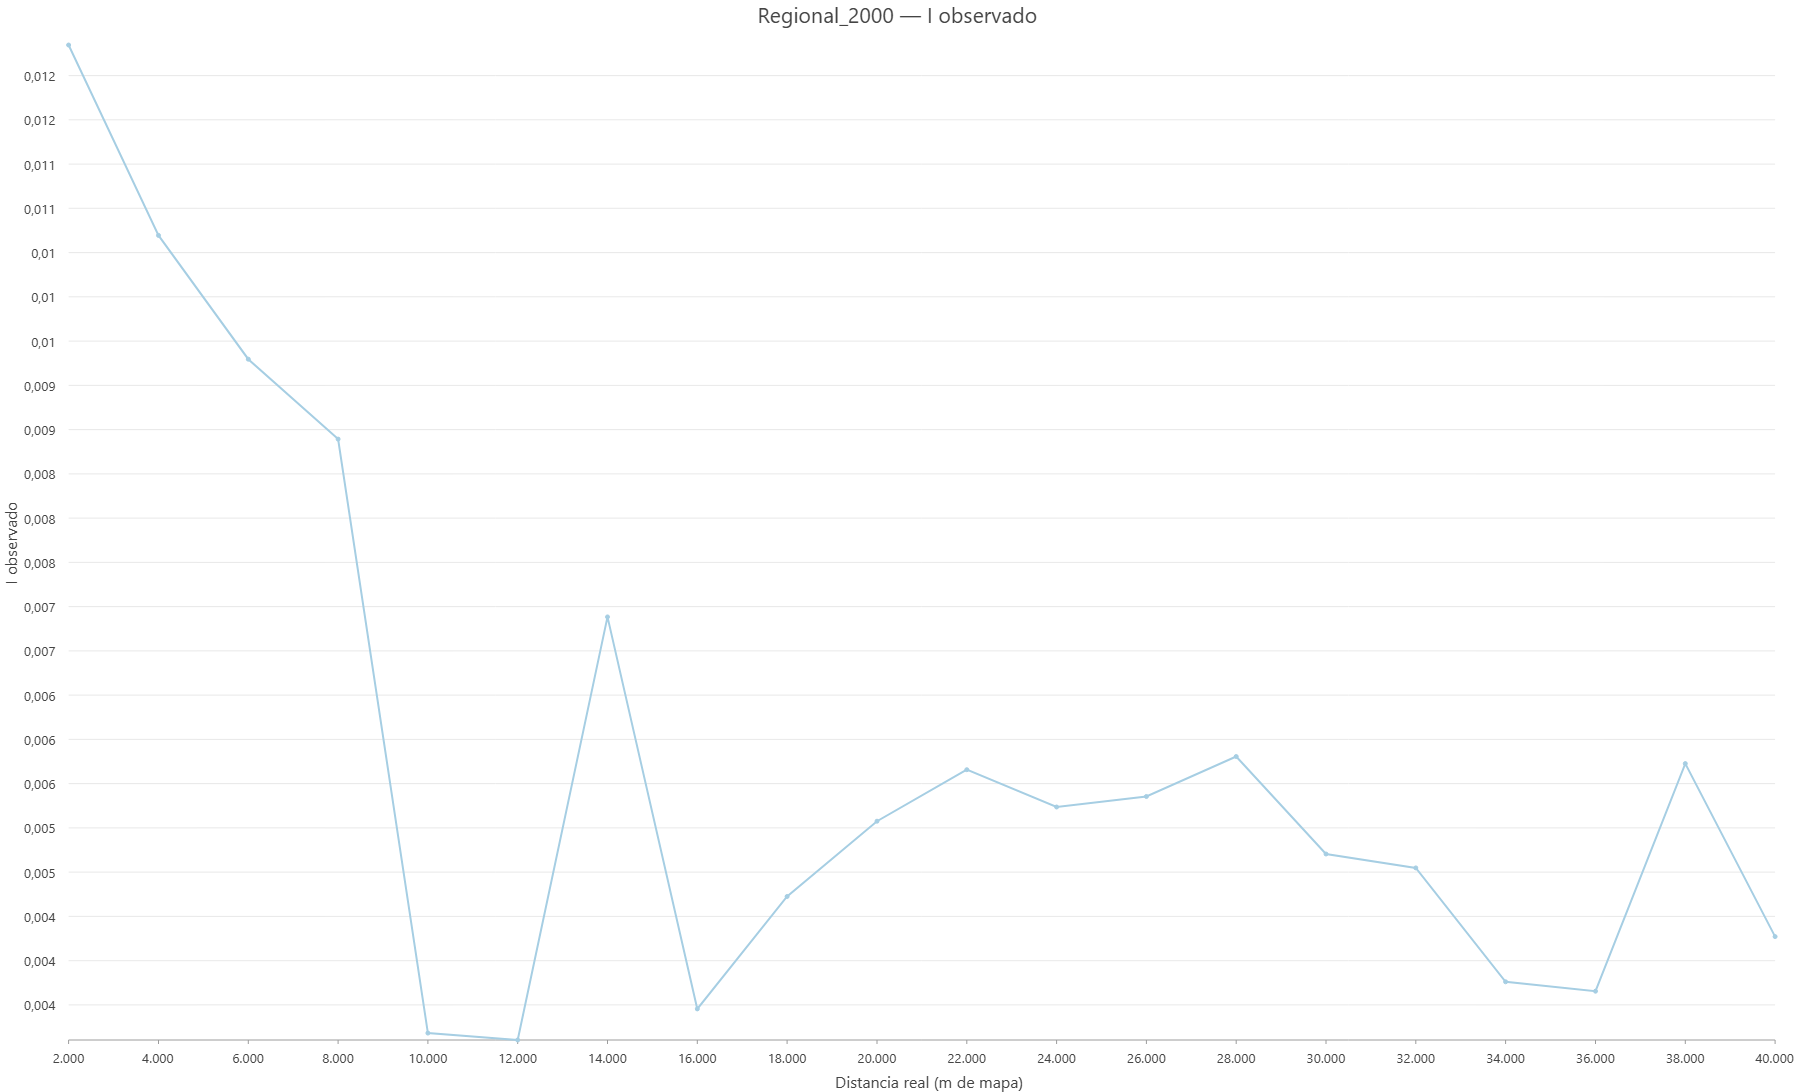

In [29]:
# Representar la medida indicada frente a distancia real, no seleccionar solo el menor p.
chart_png(arcpy.charts.Line(x='Distance',y='MoransI',dataSource=table,title='Regional_2000 — I observado',xTitle='Distancia real (m de mapa)',yTitle='I observado'),'Regional_2000_MoransI')


Curva ArcGIS, elaboración docente con la tabla de esta corrida: x es distancia cartográfica real; y es I (magnitud adimensional), no probabilidad.

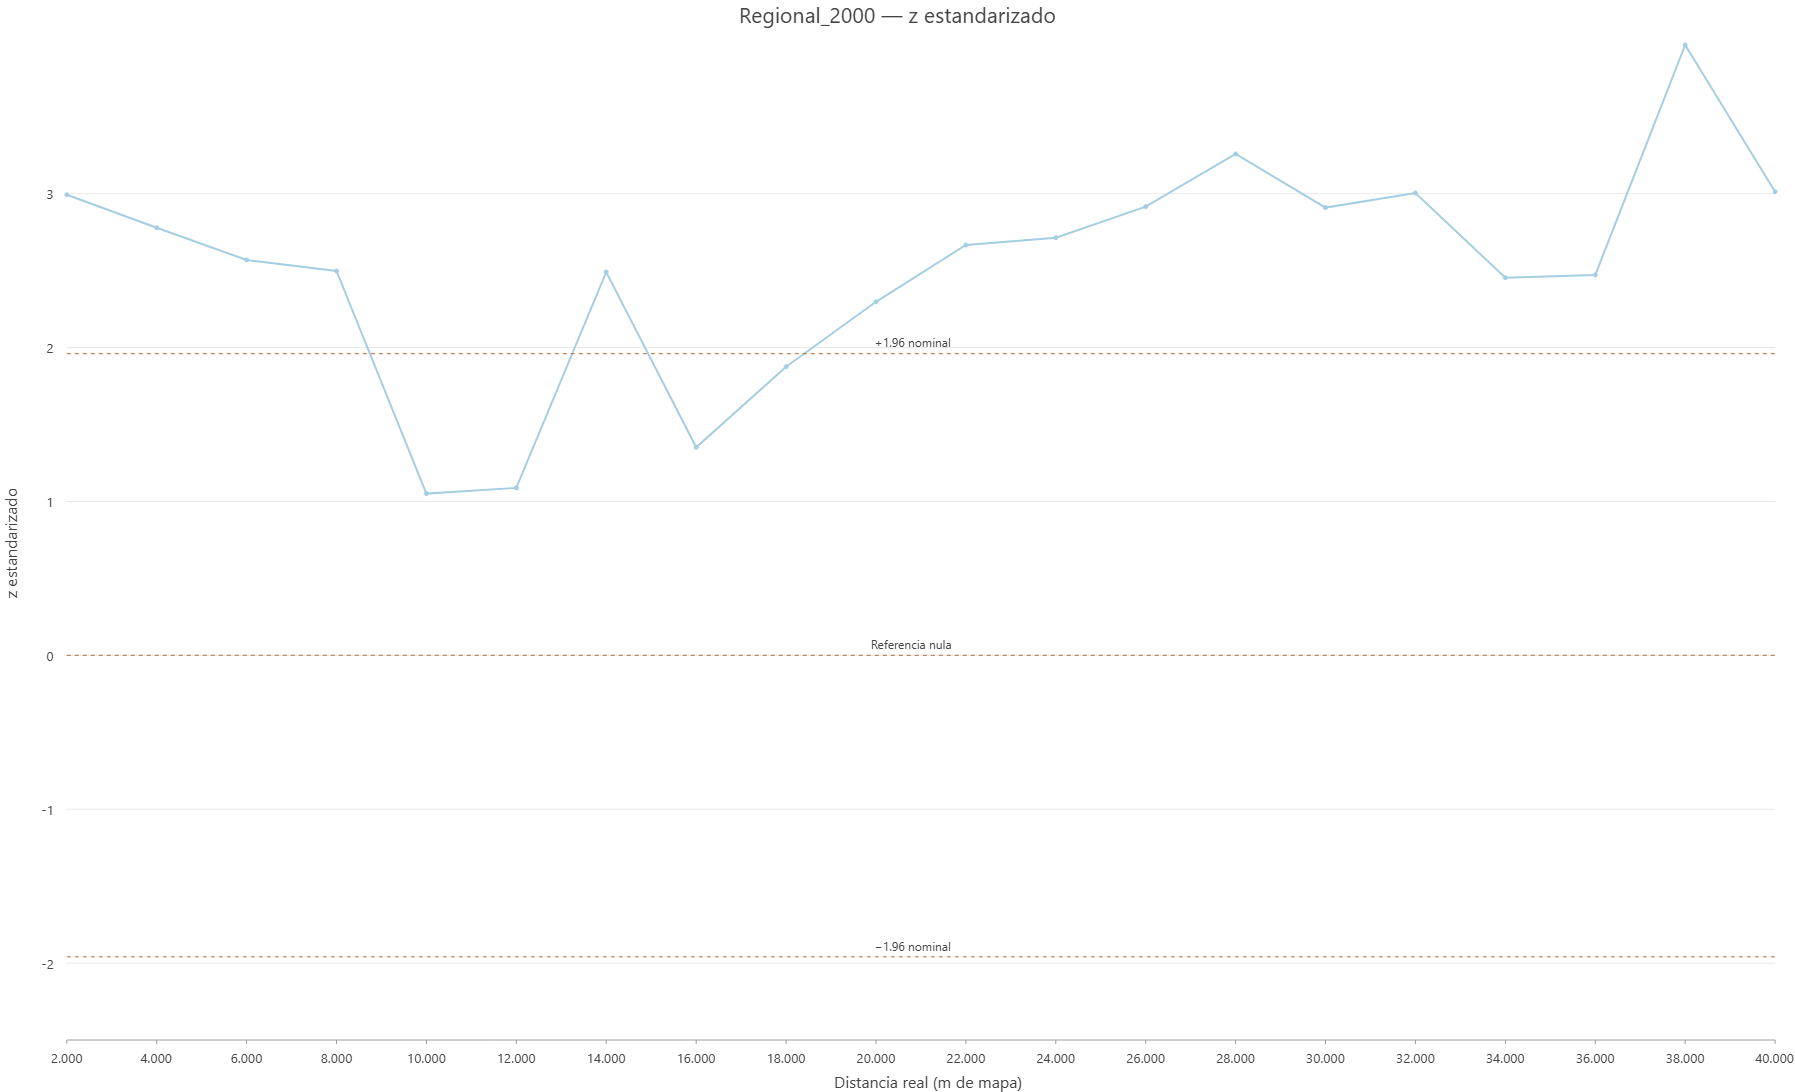

In [30]:
# Representar la medida indicada frente a distancia real, no seleccionar solo el menor p.
chart_png(arcpy.charts.Line(x='Distance',y='z_score',dataSource=table,title='Regional_2000 — z estandarizado',xTitle='Distancia real (m de mapa)',yTitle='z estandarizado'),'Regional_2000_z_score')


Curva ArcGIS, elaboración docente con la tabla de esta corrida: x es distancia cartográfica real; y es z (desviaciones bajo H₀); ±1.96 son referencias nominales.

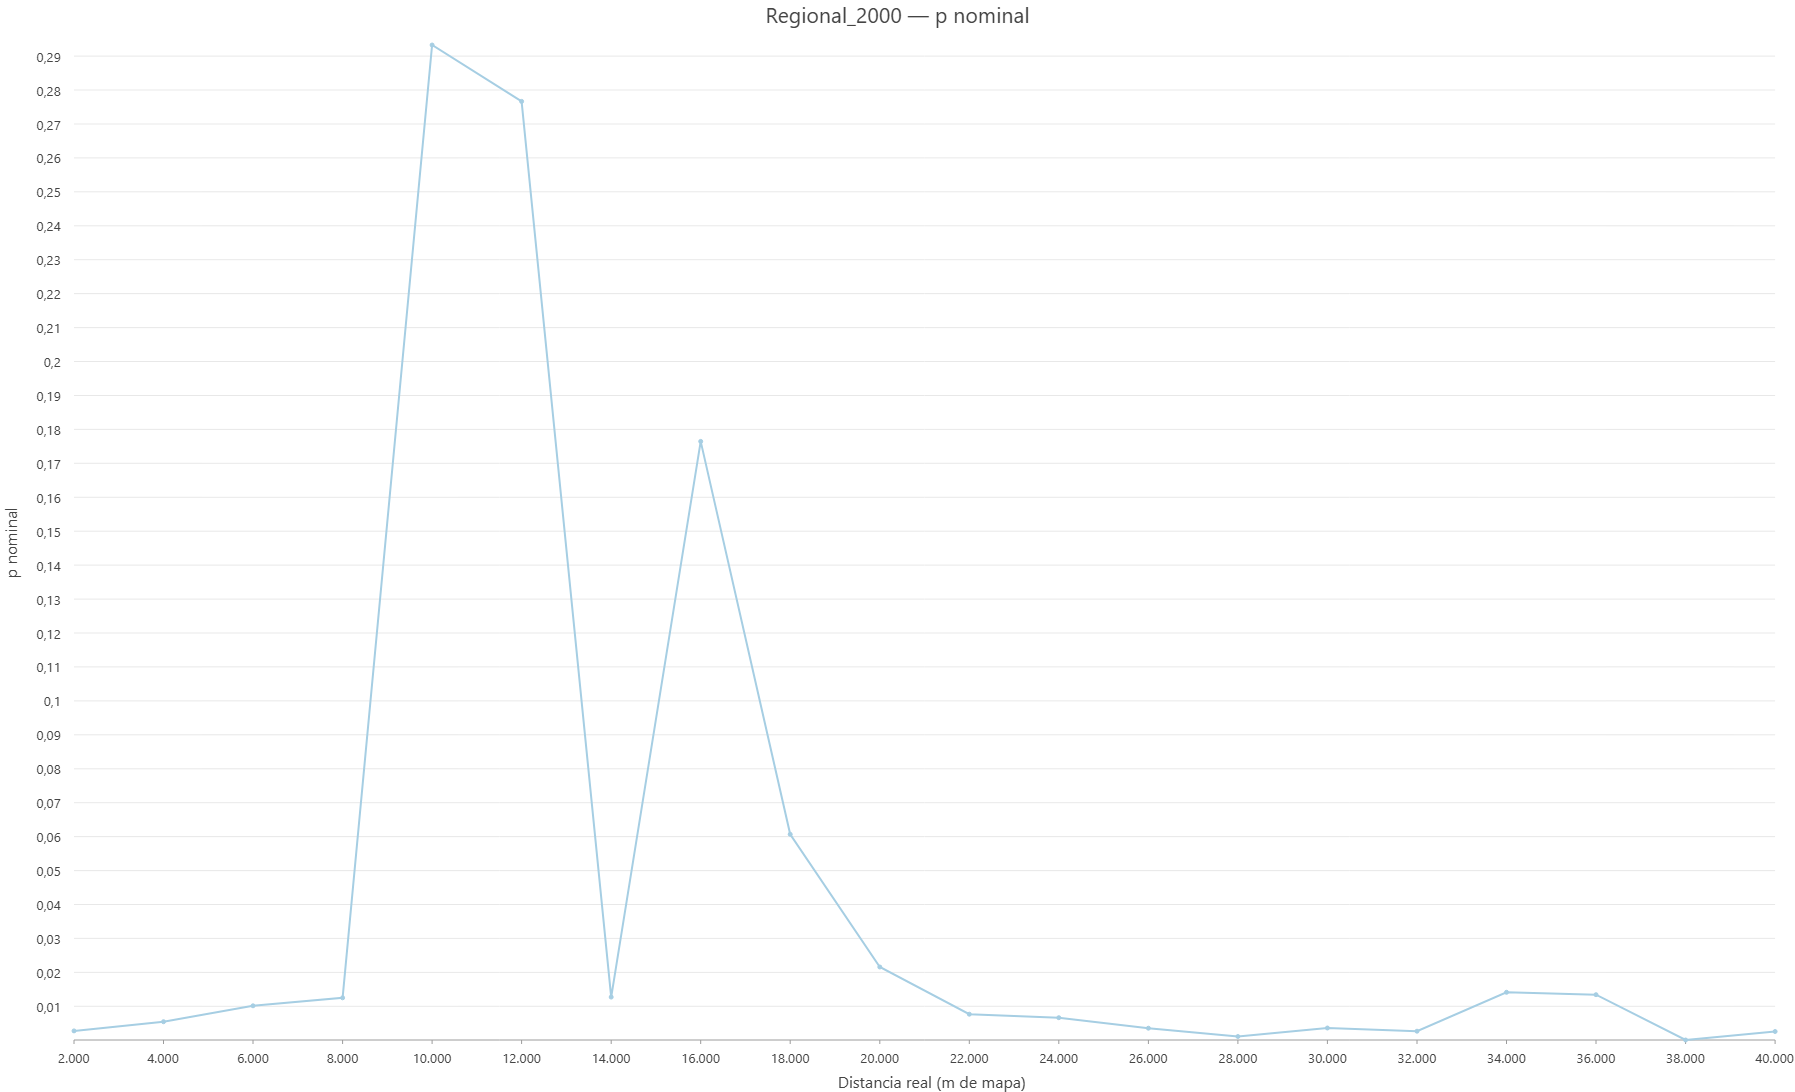

In [31]:
# Representar la medida indicada frente a distancia real, no seleccionar solo el menor p.
chart_png(arcpy.charts.Line(x='Distance',y='p_value',dataSource=table,title='Regional_2000 — p nominal',xTitle='Distancia real (m de mapa)',yTitle='p nominal'),'Regional_2000_p_value')


Curva ArcGIS, elaboración docente con la tabla de esta corrida: x es distancia cartográfica real; y es p nominal, no P(H₀); un cero mostrado refleja precisión numérica.

**Interpretación:** lea el cambio de I junto al de z: mayor separación estandarizada no implica asociación de mayor magnitud. Los p son nominales y dependientes entre bandas. Conectar ciudades distintas puede ser coherente con una pregunta regional, pero no demuestra un mecanismo ni invalida automáticamente la significancia. Distancia euclidiana en Web Mercator no equivale a accesibilidad escolar.

## Refinamiento previsto: 20 bandas de 500 m
La configuración prevista es inicio 500, paso 500, veinte bandas hasta 10 000 m. **Fuente histórica:** grabación 14 (2026-06-24), parámetros visibles en 97:36; se conserva su ejecución en este notebook, con parámetros y secuencia de la fuente.

### Calcular Refinada_500

| Parámetro | Valor |
| --- | --- |
| Campo | ICOUNT |
| Bandas | 20 |
| Inicio / paso | 500 / 500 m |
| Final solicitado | 10000 m |
| Métrica / pesos | EUCLIDEAN / ROW_STANDARDIZATION |

Son radios acumulativos, no anillos ni diámetros. Web Mercator distorsiona distancia; no equivale a viaje por carretera.

In [32]:
# Evaluar bandas previstas y conservar distancias reales y mensajes completos.
table, rows = incremental('Refinada_500', 20, 500, 500)


Hijo IncrementalSpatialAutocorrelation PID 56452 | diario: 99 - Recursos/salidas_clase_02/practica_02/hexbin_20260921/ejecucion_b557fbd99b8a/gp_children/IncrementalSpatialAutocorrelation_0b04151e794f/process.json


Cierre natural del hijo: 0 | logs: 99 - Recursos/salidas_clase_02/practica_02/hexbin_20260921/ejecucion_b557fbd99b8a/gp_children/IncrementalSpatialAutocorrelation_0b04151e794f


Solicitado: 20 500 500 | Start Time: lunes, 21 de septiembre de 2026 5:30:07 p. m.



            Global Moran's I Summary by Distance           
Distance Moran's Index Expected Index Variance  z-score  p-value
  500.00      0.033241      -0.000109 0.000061 4.259029 0.000021
 1000.00      0.019862      -0.000103 0.000028 3.791044 0.000150
 1500.00      0.014130      -0.000103 0.000020 3.185066 0.001447
 2000.00      0.012276      -0.000102 0.000017 2.992883 0.002764
 2500.00      0.009755      -0.000102 0.000016 2.458018 0.013971
 3000.00      0.010168      -0.000102 0.000015 2.615165 0.008918
 3500.00      0.010860      -0.000102 0.000015 2.836563 0.004560
 4000.00      0.010555      -0.000102 0.000015 2.778948 0.005454
 4500.00      0.010435      -0.000101 0.000014 2.780299 0.005431
 5000.00      0.009015      -0.000101 0.000014 2.430832 0.015064
 5500.00      0.009307      -0.000101 0.000014 2.523403 0.011623
 6000.00      0.009436      -0.000101 0.000014 2.570179 0.010165
 6500.00 

Alternativa local: 99 - Recursos/salidas_clase_02/practica_02/hexbin_20260921/ejecucion_b557fbd99b8a/Refinada_500.pdf | descarga en navegador no comprobada


En la ejecución histórica, la tabla refinada conserva 500–10 000 m. Pico local: 3 500 m, z=2.836563. En 500 m el z=4.259029 es mayor, pero está en el extremo: máximo numérico y pico interior no son lo mismo. Sin advertencias de esta herramienta.

La tabla completa incluye I, esperado, varianza, z y p. Leer los mensajes del primer/máximo pico local; el valor extremo inicial puede ser mayor sin ser pico interior.

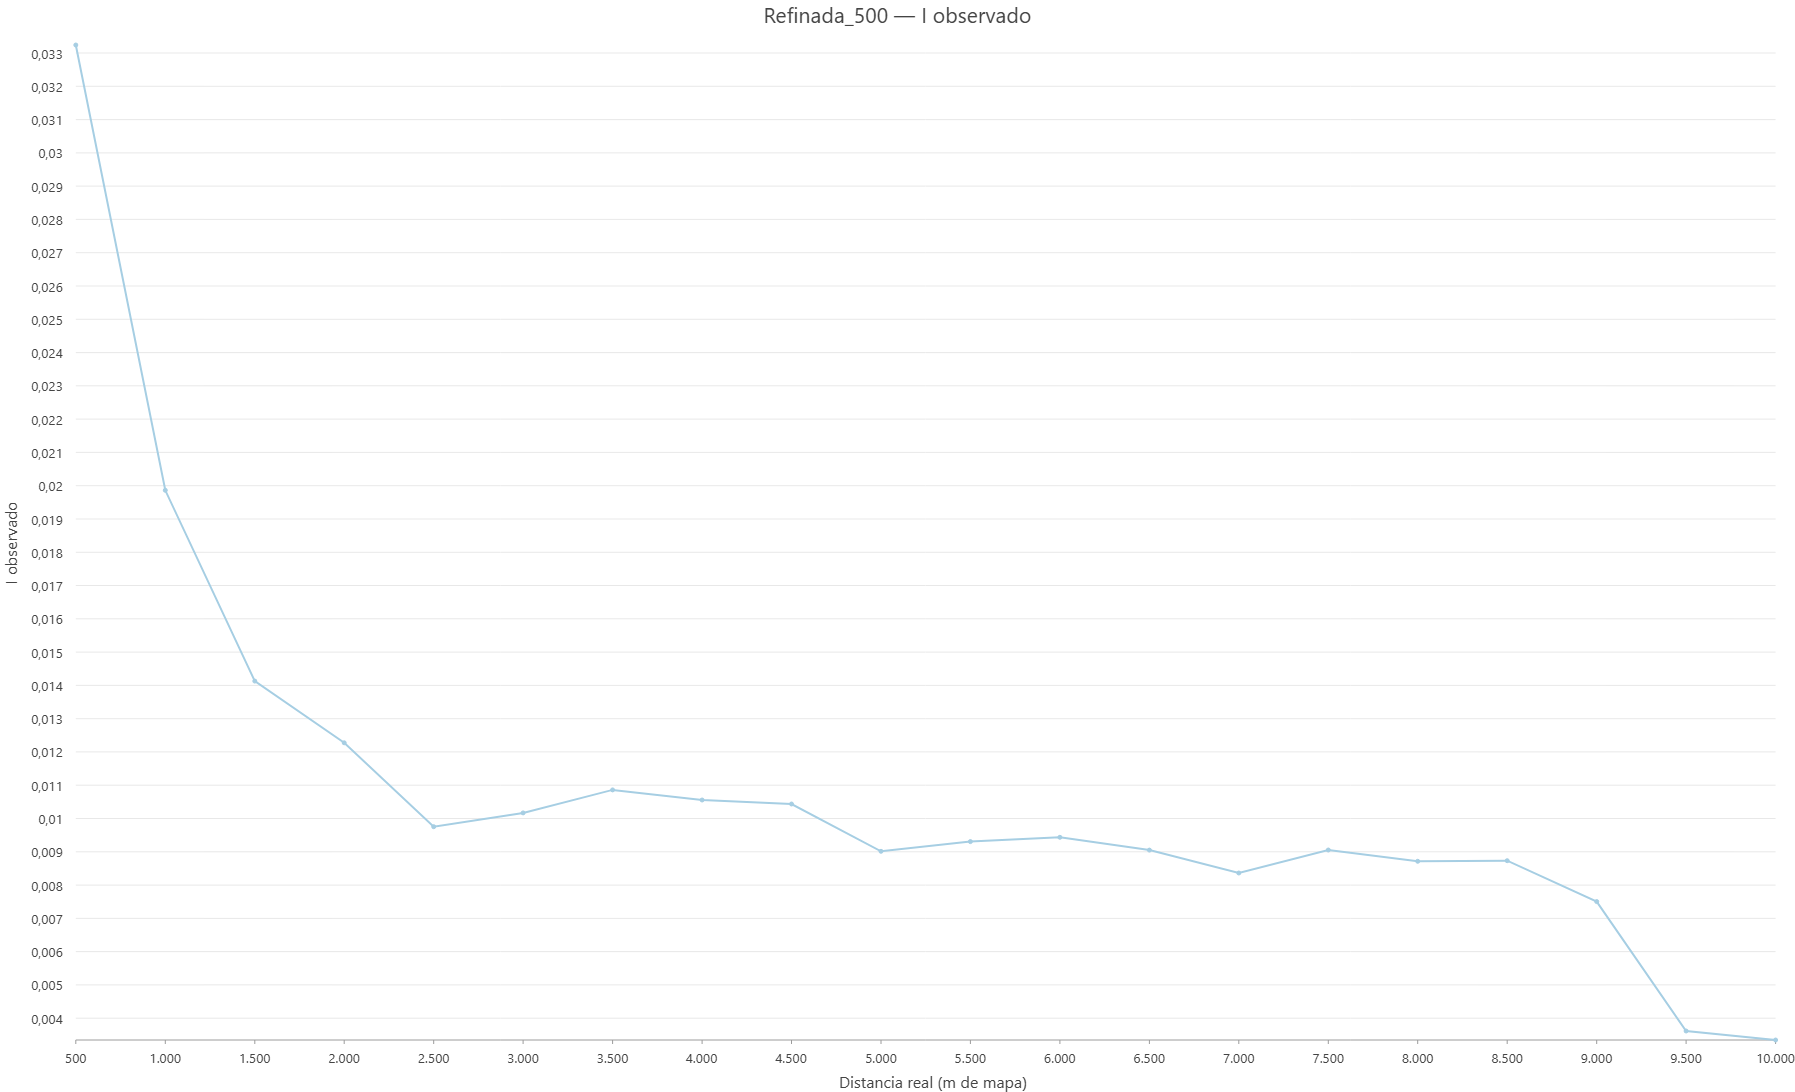

In [33]:
# Representar la medida indicada frente a distancia real, no seleccionar solo el menor p.
chart_png(arcpy.charts.Line(x='Distance',y='MoransI',dataSource=table,title='Refinada_500 — I observado',xTitle='Distancia real (m de mapa)',yTitle='I observado'),'Refinada_500_MoransI')


Curva ArcGIS, elaboración docente con la tabla de esta corrida: x es distancia cartográfica real; y es I (magnitud adimensional), no probabilidad.

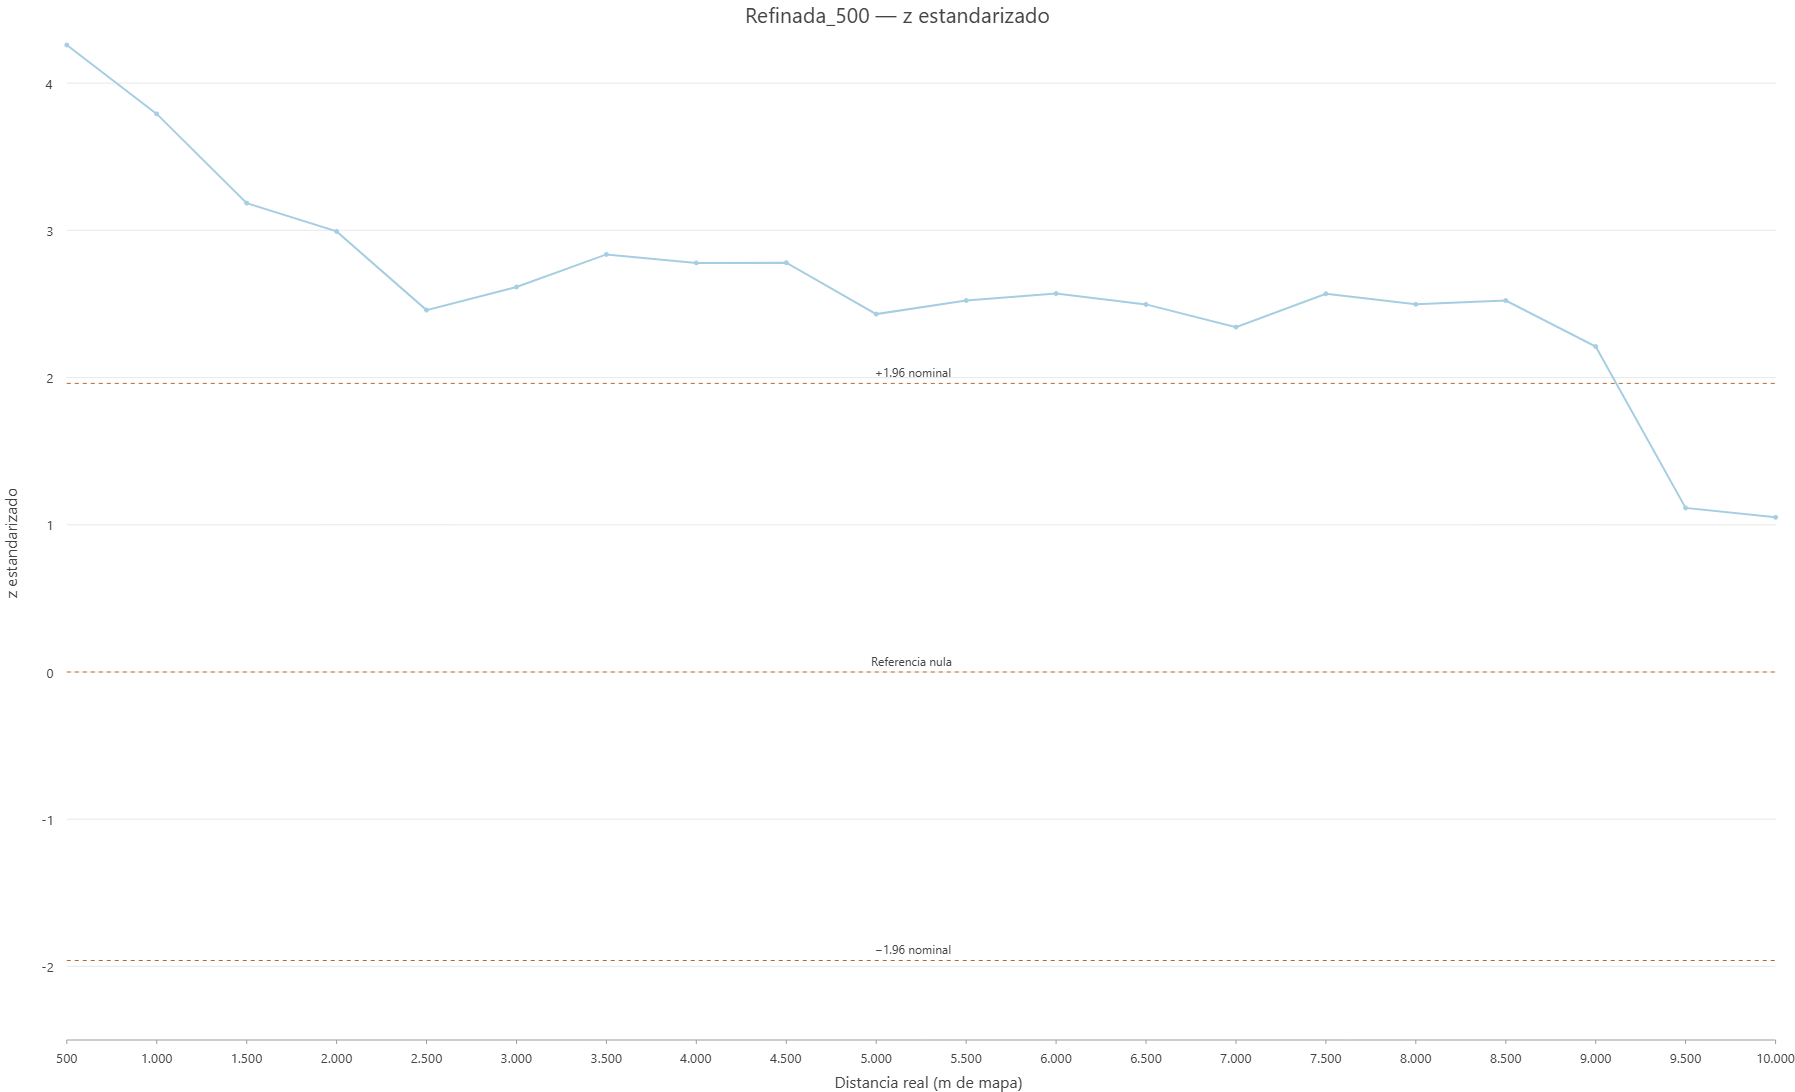

In [34]:
# Representar la medida indicada frente a distancia real, no seleccionar solo el menor p.
chart_png(arcpy.charts.Line(x='Distance',y='z_score',dataSource=table,title='Refinada_500 — z estandarizado',xTitle='Distancia real (m de mapa)',yTitle='z estandarizado'),'Refinada_500_z_score')


Curva ArcGIS, elaboración docente con la tabla de esta corrida: x es distancia cartográfica real; y es z (desviaciones bajo H₀); ±1.96 son referencias nominales.

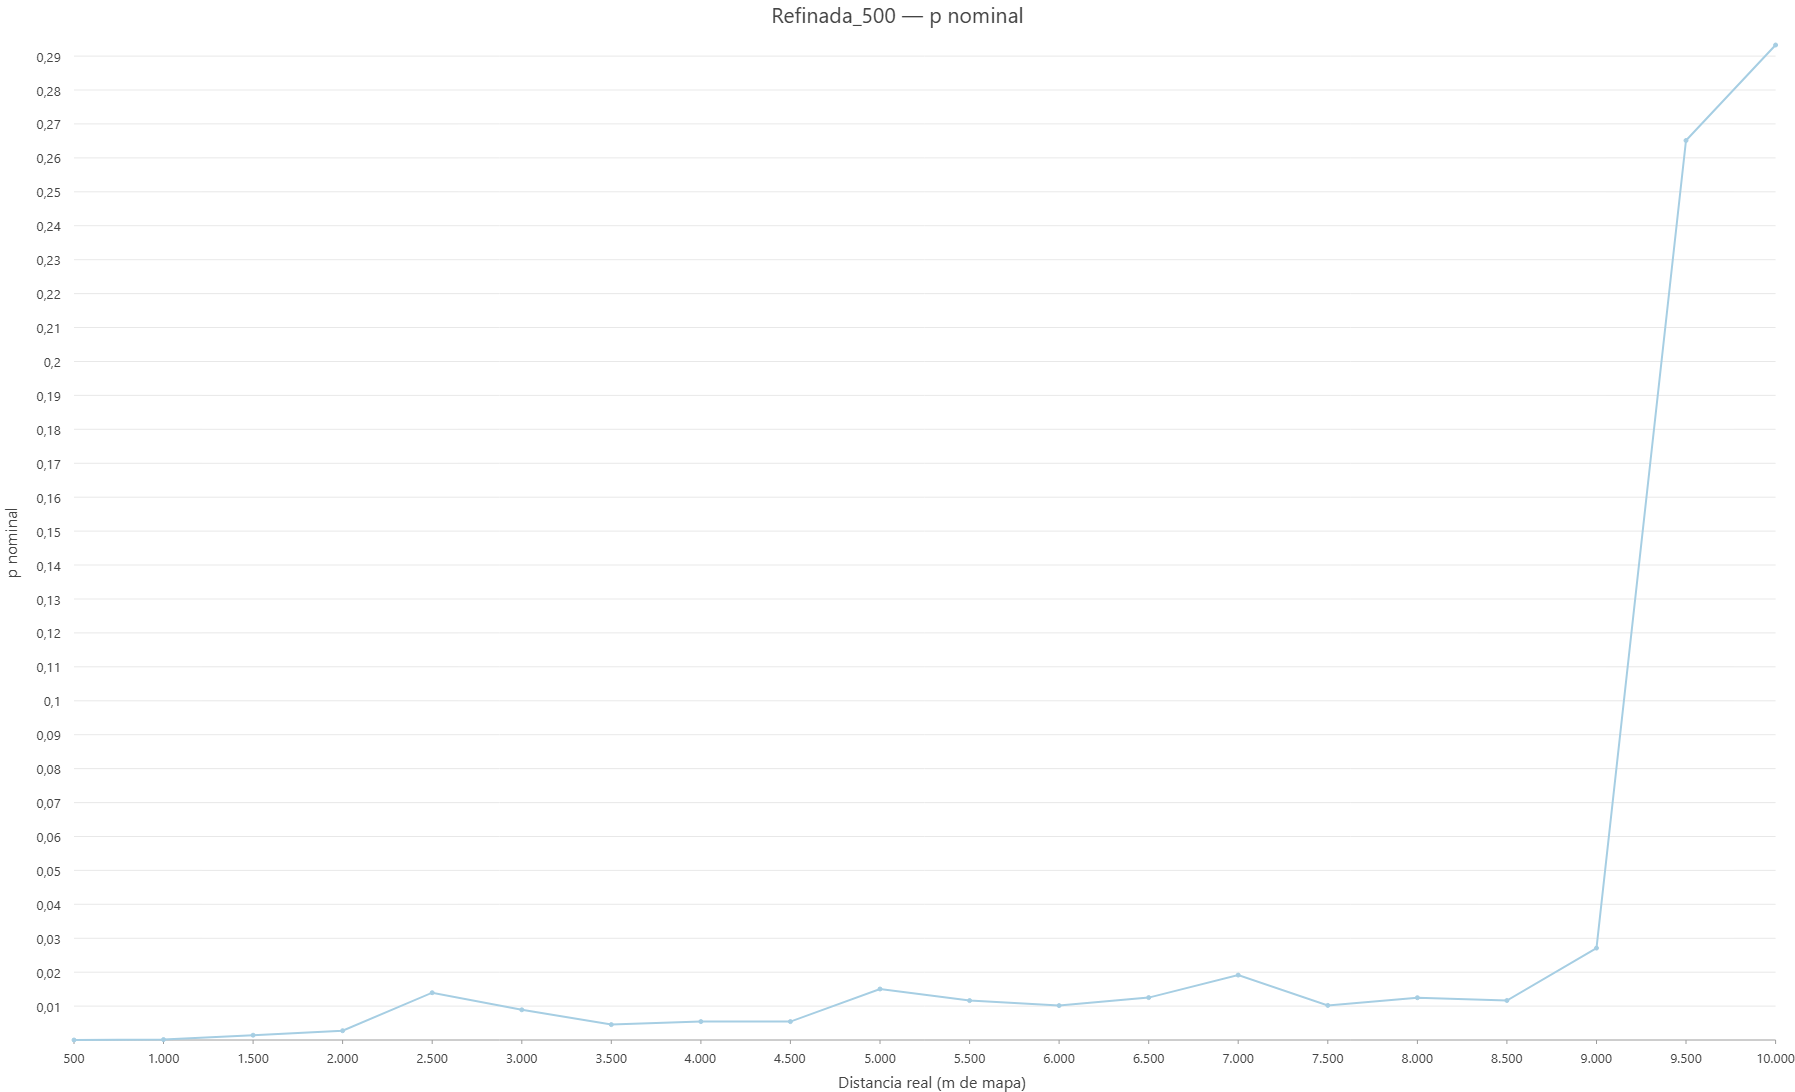

In [35]:
# Representar la medida indicada frente a distancia real, no seleccionar solo el menor p.
chart_png(arcpy.charts.Line(x='Distance',y='p_value',dataSource=table,title='Refinada_500 — p nominal',xTitle='Distancia real (m de mapa)',yTitle='p nominal'),'Refinada_500_p_value')


Curva ArcGIS, elaboración docente con la tabla de esta corrida: x es distancia cartográfica real; y es p nominal, no P(H₀); un cero mostrado refleja precisión numérica.

## Complemento solicitado: Getis-Ord Gi* (no mostrado en la grabación)
**Pregunta:** ¿hay sitios con multiplicidad alta o baja rodeados de multiplicidades semejantes? Un valor alto aislado no basta para un punto caliente. Gi* produce un contraste por sitio; no es EDA universal.

**Diseño previo:** ICOUNT de sitios ocupados; ocho vecinos más cercanos, distancia euclidiana y FDR. Esri recomienda aproximadamente ocho vecinos con asimetría: k=8 se fija antes del resultado, no se busca para producir colores. La distancia física varía; ningún pico incremental se usa como radio. `NONE` es parámetro heredado sin efecto.

**Supuestos:** al menos 30 sitios y variación finita; CRS/extensión inspeccionados arriba. Se preserva el CRS fuente. Con WKID=3857, especialmente en cobertura nacional, Web Mercator distorsiona distancias y vecindades: análisis exploratorio, no precisión terrestre en metros. FDR controla pruebas locales dentro de esta corrida, no selección de k/bandas entre modelos.

**Entrada → operación → salida:** sitios/ICOUNT → una llamada HotSpots → copia Gi_8vecinos_FDR con z, p nominal y categoría FDR. Se conservan mensajes y sitios; sin Integrate, reparación, imputación ni eliminación.

**Fuente complementaria:** Esri, ArcGIS Pro 3.6, [Hot Spot Analysis: Usage/Parameters/Python](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/spatial-statistics/hot-spot-analysis.htm) y [How Hot Spot Analysis works](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/spatial-statistics/h-how-hot-spot-analysis-getis-ord-gi-spatial-stati.htm), consulta 2026-09-16. Firma contrastada con Pro 3.6.2 instalado.

**Lectura de Gi\*:** combina valor del sitio y vecinos; k=8 fija vecinos, no radio físico. GiZScore es separación estandarizada (positivo: concentración alta; negativo: baja); GiPValue es p crudo, no probabilidad de riesgo. Gi_Bin usa FDR: ±1/±2/±3 son categorías 90/95/99 %, con signo caliente/frío; 0=no significativo, no prueba de azar ni lugar seguro. FDR ajusta múltiples contrastes locales, no selección de modelo, k o escala después de ver resultados.

In [36]:
# Configuración fijada antes de observar resultados; entradas de solo lectura.
import inspect, json
print('Firma instalada:', inspect.signature(arcpy.stats.HotSpots))
assert 'number_of_neighbors' in inspect.signature(arcpy.stats.HotSpots).parameters
if n_sites < 30 or n_sites <= 8 or len(set(icount)) < 2 or not all(math.isfinite(v) for v in icount):
    raise ValueError('Gi* requiere al menos 30 sitios, más de ocho, valores finitos y variación.')
if sr.type != 'Projected' or sr.linearUnitName.lower() not in ('meter','metre'):
    raise ValueError('Revisar CRS y extensión: no proyectar automáticamente.')
hotspots = str(Path(gdb) / 'Gi_8vecinos_FDR')
gi_result = gp_child('HotSpots', 
    Input_Feature_Class=weighted, Input_Field='ICOUNT', Output_Feature_Class=hotspots,
    Conceptualization_of_Spatial_Relationships='K_NEAREST_NEIGHBORS',
    Distance_Method='EUCLIDEAN_DISTANCE', Standardization='NONE',
    Apply_False_Discovery_Rate__FDR__Correction='APPLY_FDR', number_of_neighbors=8,
)
print(gi_result['messages'])
(run / 'Gi_mensajes.txt').write_text(gi_result['messages'], encoding='utf-8')
with arcpy.da.SearchCursor(hotspots, ['Gi_Bin']) as cursor:
    gi_counts = Counter(int(row[0]) for row in cursor)
assert sum(gi_counts.values()) == n_sites
labels = {-3:'Frío 99%', -2:'Frío 95%', -1:'Frío 90%', 0:'No significativo', 1:'Caliente 90%', 2:'Caliente 95%', 3:'Caliente 99%'}
tabla_visible(['Gi_Bin (FDR)', 'Categoría', 'Sitios'], [[v, labels[v], gi_counts[v]] for v in range(-3,4)])
tabla_visible(['Campo real', 'Significado', 'Lectura y límite'], [
    ['GiZScore', 'Estadístico local estandarizado', 'Positivo/negativo: valores altos/bajos agrupados, no riesgo'],
    ['GiPValue', 'p nominal sin corrección FDR', 'Extremidad bajo el modelo nulo; no probabilidad de H0'],
    ['Gi_Bin', 'Clasificación FDR: ±1/±2/±3 y 0', 'Frío/caliente; 90/95/99%; 0 no significativo'],
    ['SOURCE_ID', 'Enlace al identificador local de entrada', 'No clave semántica ni prueba de duplicación'],
    ['ICOUNT', 'Registros por sitio ocupado', 'No ausencia territorial, exposición ni tasa'],
])
(run / 'Gi_conteos.json').write_text(json.dumps({str(v):gi_counts[v] for v in range(-3,4)}, indent=2), encoding='utf-8')


Firma instalada: (Input_Feature_Class=None, Input_Field=None, Output_Feature_Class=None, Conceptualization_of_Spatial_Relationships: "Literal['INVERSE_DISTANCE', 'INVERSE_DISTANCE_SQUARED', 'FIXED_DISTANCE_BAND', 'ZONE_OF_INDIFFERENCE', 'K_NEAREST_NEIGHBORS', 'CONTIGUITY_EDGES_ONLY', 'CONTIGUITY_EDGES_CORNERS', 'GET_SPATIAL_WEIGHTS_FROM_FILE'] | None" = None, Distance_Method: "Literal['EUCLIDEAN_DISTANCE', 'MANHATTAN_DISTANCE'] | None" = None, Standardization: "Literal['NONE', 'ROW'] | None" = None, Distance_Band_or_Threshold_Distance=None, Self_Potential_Field=None, Weights_Matrix_File=None, Apply_False_Discovery_Rate__FDR__Correction: "Literal['APPLY_FDR', 'NO_FDR'] | None" = None, number_of_neighbors=None) -> 'Result'
Hijo HotSpots PID 63456 | diario: 99 - Recursos/salidas_clase_02/practica_02/hexbin_20260921/ejecucion_b557fbd99b8a/gp_children/HotSpots_2d17d90878fd/process.json


Cierre natural del hijo: 0 | logs: 99 - Recursos/salidas_clase_02/practica_02/hexbin_20260921/ejecucion_b557fbd99b8a/gp_children/HotSpots_2d17d90878fd


Start Time: lunes, 21 de septiembre de 2026 5:30:38 p. m.
Succeeded at lunes, 21 de septiembre de 2026 5:30:41 p. m. (Elapsed Time: 2.83 seconds)


Gi_Bin (FDR),Categoría,Sitios
-3,Frío 99%,0
-2,Frío 95%,0
-1,Frío 90%,0
0,No significativo,10127
1,Caliente 90%,0
2,Caliente 95%,0
3,Caliente 99%,135


Campo real,Significado,Lectura y límite
GiZScore,Estadístico local estandarizado,"Positivo/negativo: valores altos/bajos agrupados, no riesgo"
GiPValue,p nominal sin corrección FDR,Extremidad bajo el modelo nulo; no probabilidad de H0
Gi_Bin,Clasificación FDR: ±1/±2/±3 y 0,Frío/caliente; 90/95/99%; 0 no significativo
SOURCE_ID,Enlace al identificador local de entrada,No clave semántica ni prueba de duplicación
ICOUNT,Registros por sitio ocupado,"No ausencia territorial, exposición ni tasa"


81

### Leer categorías y después el mapa
**Resultado:** siete categorías incluso vacías; mensajes preservan advertencias. GiZScore/GiPValue son crudos; Gi_Bin refleja FDR. SOURCE_ID enlaza fila local, no entidad certificada.

**Siguiente operación:** capa Gi* → azul/gris/rojo y barras → PNG estáticos. Porcentajes de leyenda son niveles de significancia, no porcentajes de sitios ni probabilidades de causalidad.
Barras: NS = no significativo; Cal = caliente; Frío = agrupación baja. Los prefijos 1–7 solo ordenan las siete categorías; 90/95/99% son niveles, no proporciones de sitios.

Base en línea: Light Gray Canvas | Esri y colaboradores; atribución dentro del mapa.


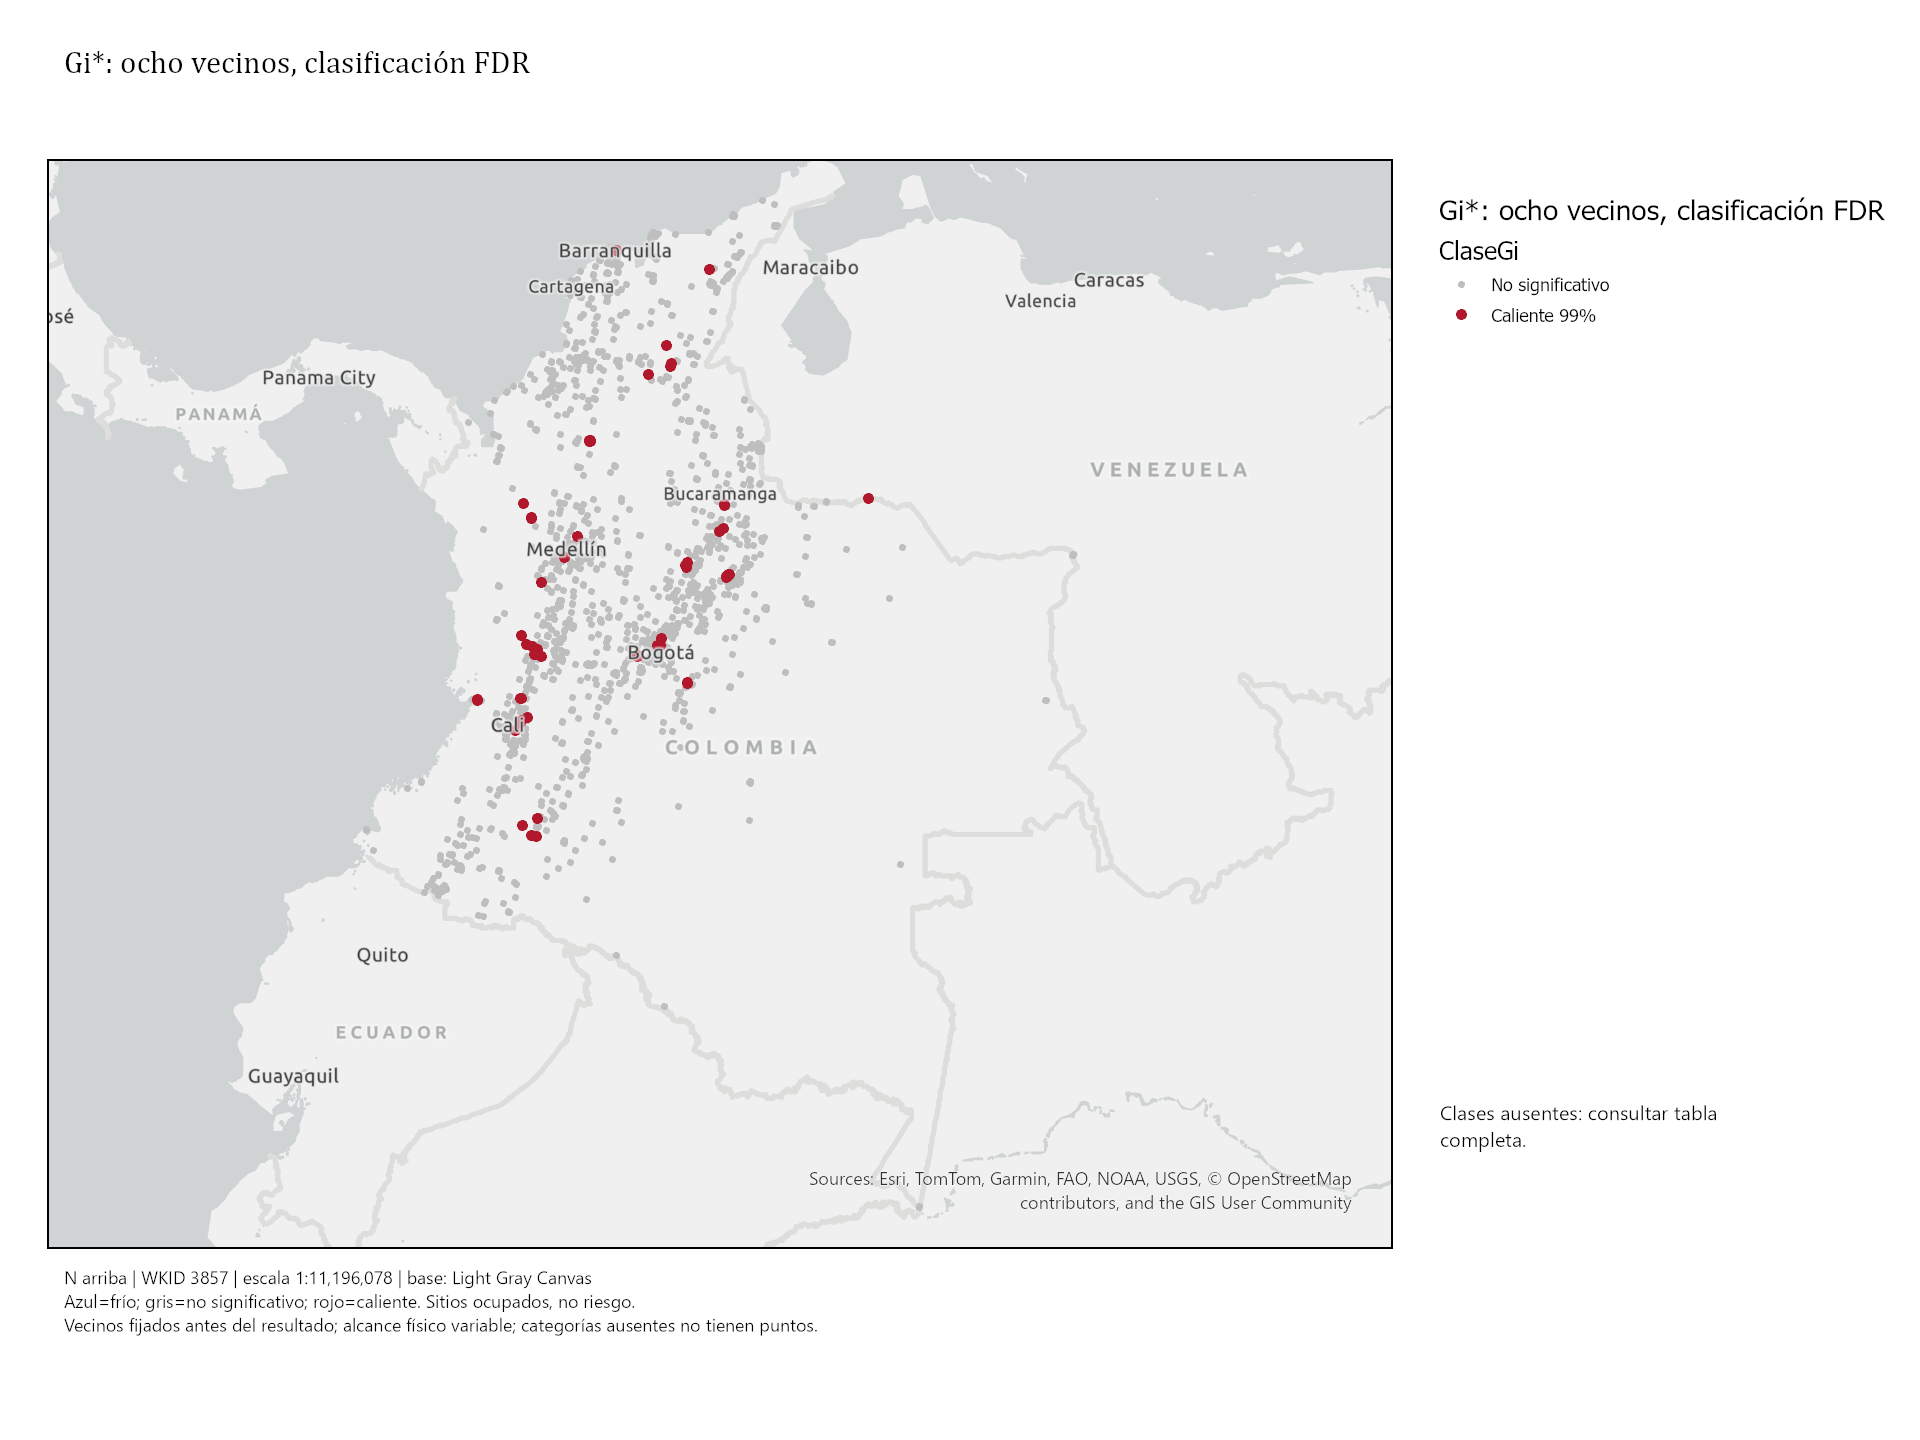

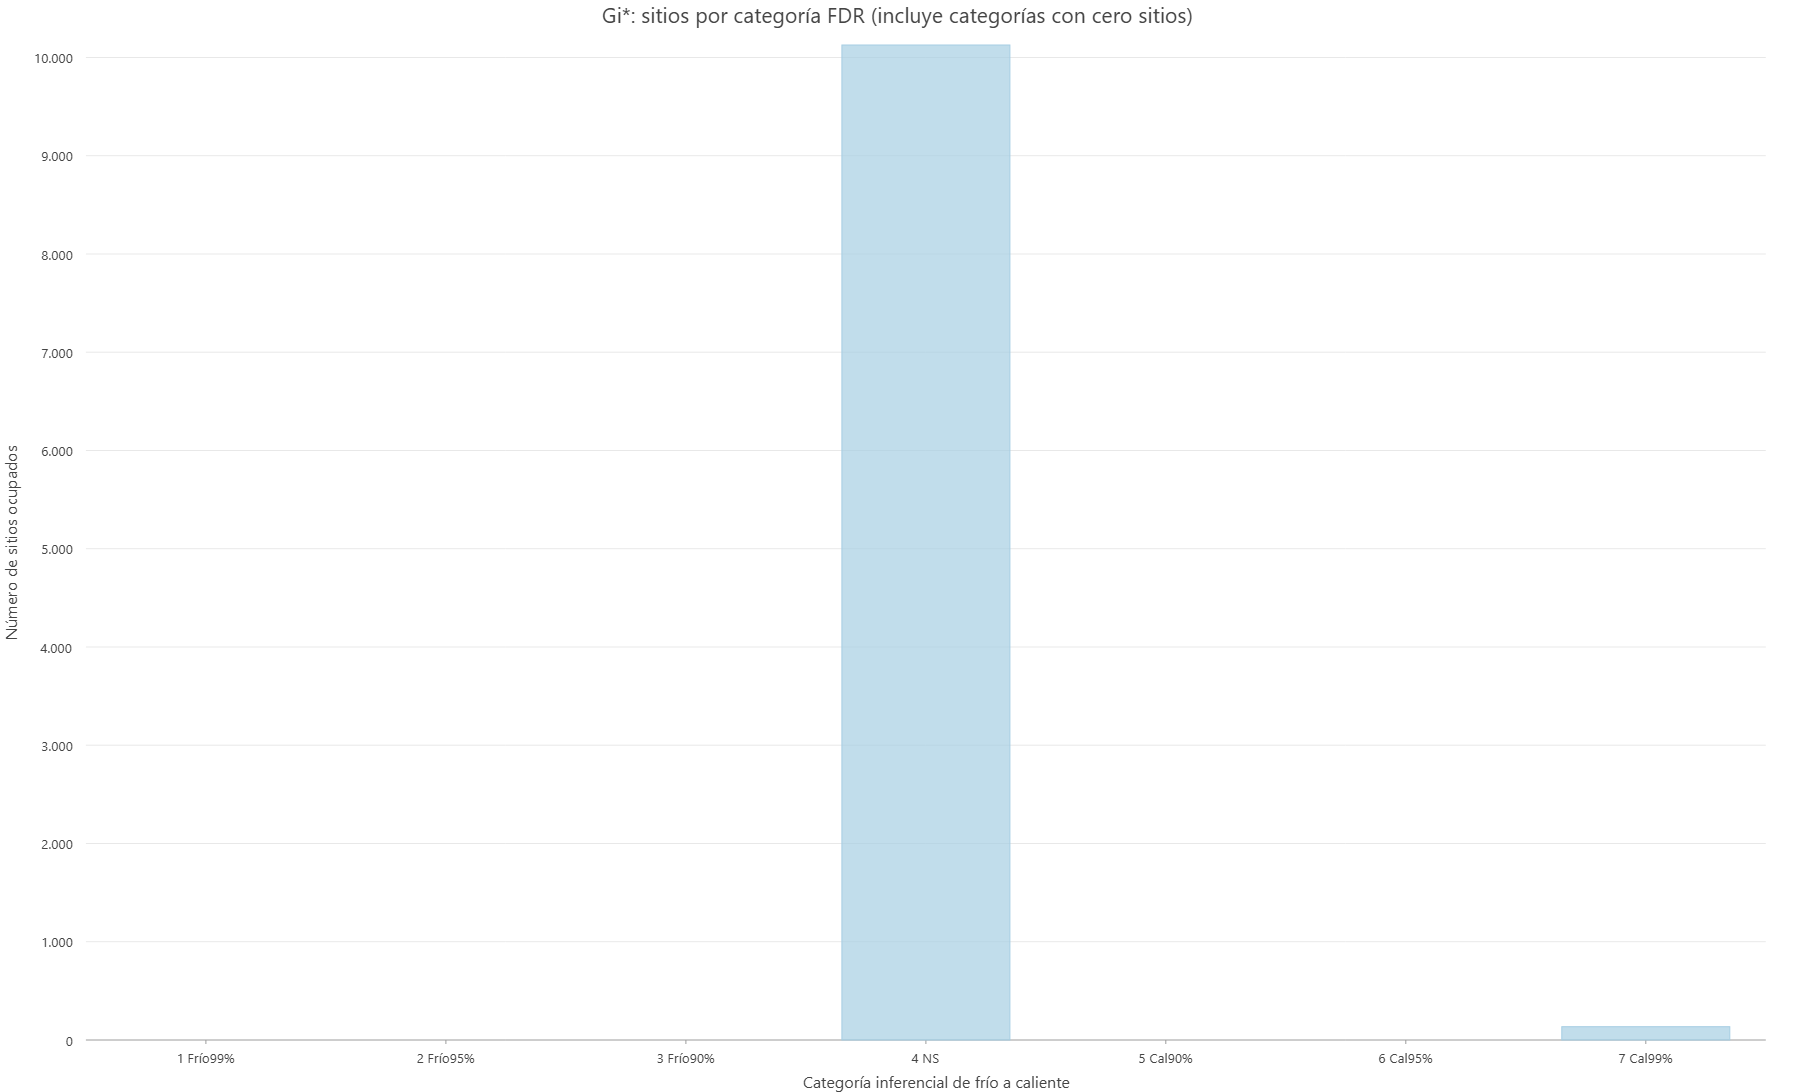

Resultado observado: 0 fríos, 10127 no significativos y 135 calientes. Total=10262.
Categorías vacías son válidas: no se modifica k para obtener colores. Multiplicidad local no equivale a ausencia o riesgo.


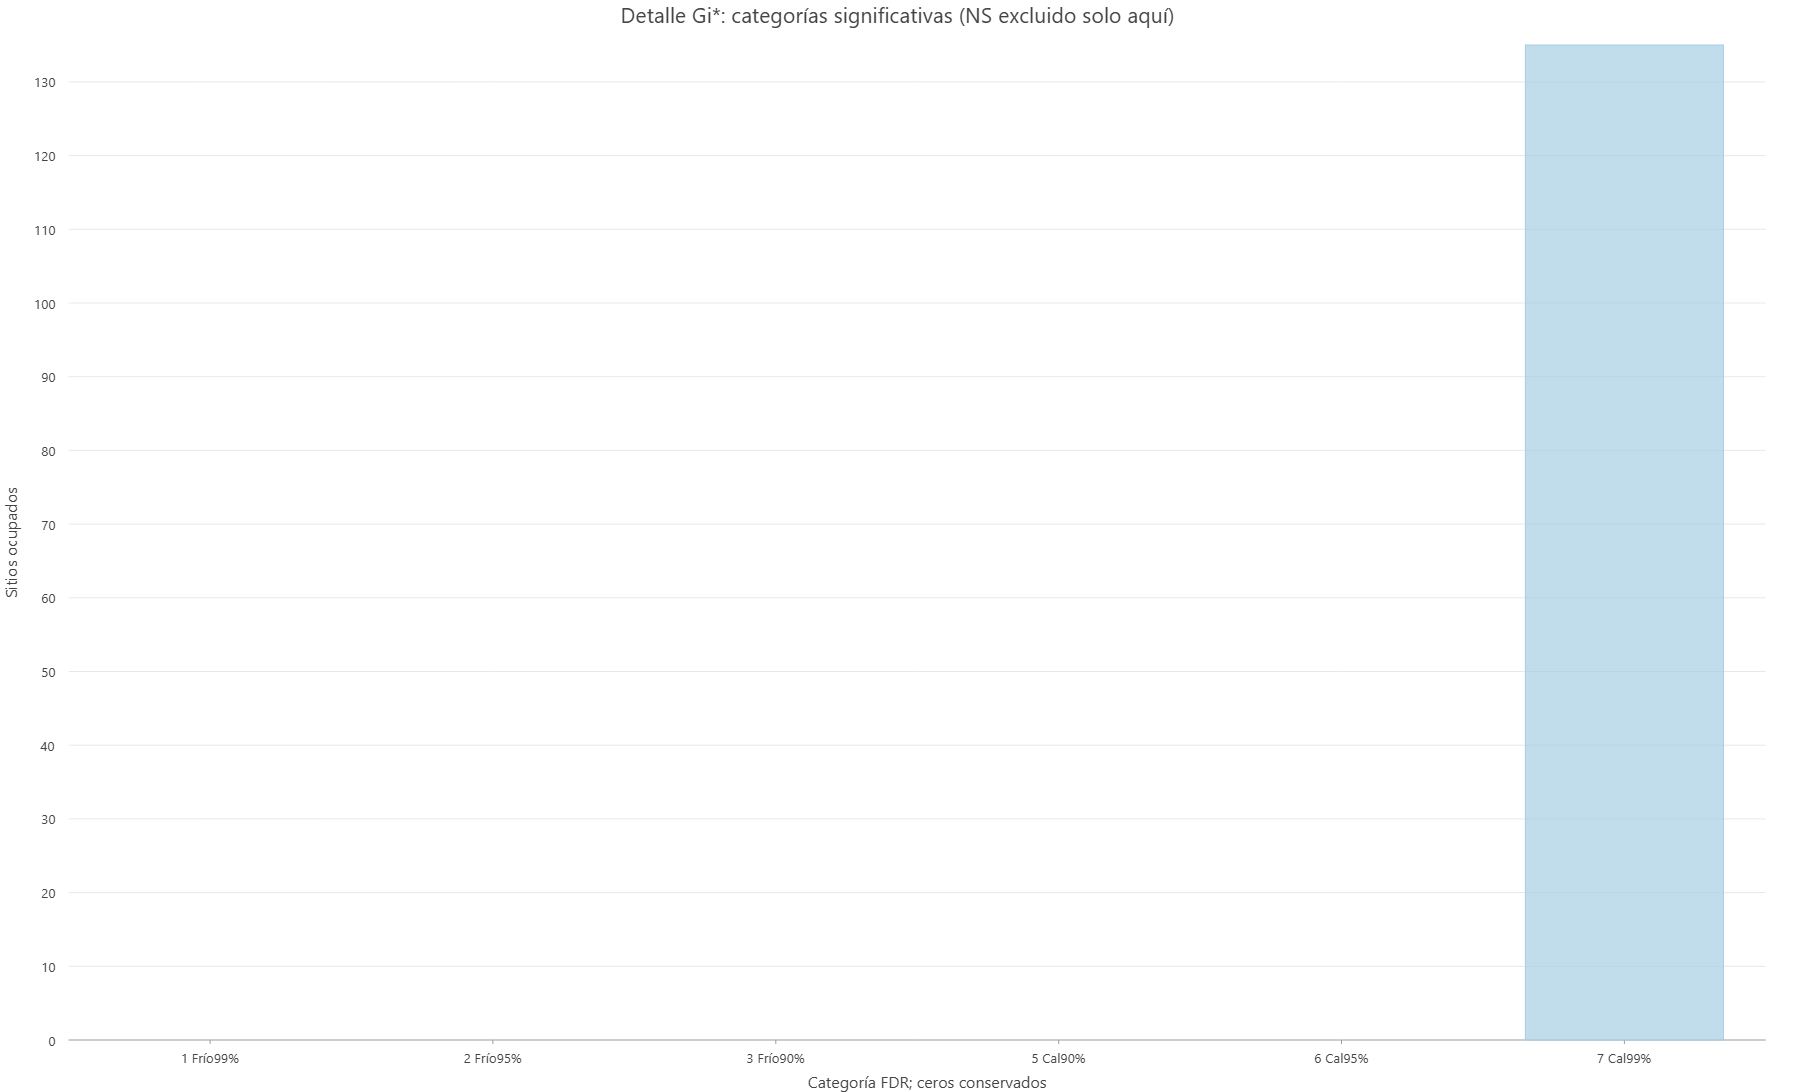

Categoría FDR,Sitios,Total de sitios,Porcentaje del total
Frío 99%,0,10262,0.0
Frío 95%,0,10262,0.0
Frío 90%,0,10262,0.0
No significativo,10127,10262,98.684
Caliente 90%,0,10262,0.0
Caliente 95%,0,10262,0.0
Caliente 99%,135,10262,1.316


Lectura: detalle sin NS para comparar minorías; cero fríos no significa un territorio más seguro.


In [37]:
# Azul-neutral-rojo igual en las tres prácticas; no fabricar categorías presentes.
gi_colors = [[33,102,172,100], [67,147,195,100], [146,197,222,100], [190,190,190,100],
             [244,165,130,100], [214,96,77,100], [178,24,43,100]]
arcpy.management.AddField(hotspots, 'ClaseGi', 'TEXT', field_length=40)
with arcpy.da.UpdateCursor(hotspots, ['Gi_Bin','ClaseGi']) as cursor:
    for row in cursor:
        row[1] = str(int(row[0])+4) + '. ' + labels[int(row[0])]
        cursor.updateRow(row)
gi_styles = {str(v+4)+'. '+labels[v]:(labels[v], gi_colors[v+3], 3 if v == 0 else 5) for v in range(-3,4)}
mapa_categorias(hotspots, 'ClaseGi', 'mapa_Gi_FDR', 'Gi*: ocho vecinos, clasificación FDR', gi_styles,
    'Azul=frío; gris=no significativo; rojo=caliente. Sitios ocupados, no riesgo.' + chr(10) +
    'Vecinos fijados antes del resultado; alcance físico variable; categorías ausentes no tienen puntos.')
short_labels = ['1 Frío99%', '2 Frío95%', '3 Frío90%', '4 NS', '5 Cal90%', '6 Cal95%', '7 Cal99%']
gi_table = tabla_frecuencia('Frecuencia_Gi', [(short_labels[v+3],gi_counts[v]) for v in range(-3,4)])
chart_png(arcpy.charts.Bar(x='Categoria', y='Sitios', aggregation='SUM', dataSource=gi_table,
    title='Gi*: sitios por categoría FDR (incluye categorías con cero sitios)',
    xTitle='Categoría inferencial de frío a caliente', yTitle='Número de sitios ocupados'), 'barras_Gi_FDR')
cold = sum(gi_counts[v] for v in (-3,-2,-1))
hot = sum(gi_counts[v] for v in (1,2,3))
print(f'Resultado observado: {cold} fríos, {gi_counts[0]} no significativos y {hot} calientes. Total={n_sites}.')
print('Categorías vacías son válidas: no se modifica k para obtener colores. Multiplicidad local no equivale a ausencia o riesgo.')

# Detalle explícito: seis categorías significativas; NS permanece en el panel completo.
gi_detalle = tabla_frecuencia('Frecuencia_Gi_detalle',
    [(short_labels[v+3], gi_counts[v]) for v in (-3,-2,-1,1,2,3)])
chart_png(arcpy.charts.Bar(x='Categoria', y='Sitios', aggregation='SUM', dataSource=gi_detalle,
    title='Detalle Gi*: categorías significativas (NS excluido solo aquí)',
    xTitle='Categoría FDR; ceros conservados', yTitle='Sitios ocupados'), 'barras_Gi_detalle')
tabla_visible(['Categoría FDR', 'Sitios', 'Total de sitios', 'Porcentaje del total'],
    [[labels[v], gi_counts[v], n_sites, round(100*gi_counts[v]/n_sites, 3)] for v in range(-3,4)])
print('Lectura: detalle sin NS para comparar minorías; cero fríos no significa un territorio más seguro.')


En la ejecución histórica hay 135 sitios calientes al 99 % y 10 127 no significativos. No hay fríos significativos. El gris no prueba azar ni seguridad; el rojo no explica causas. Mapas y barras: elaboración docente con ArcGIS Pro 3.6.2 sobre la copia local citada, no datos sintéticos.

Frío indica multiplicidades bajas agrupadas, no seguridad. Caliente no prueba causas. Las categorías ausentes son válidas; no cambie k para producir colores. FDR no corrige la selección entre modelos.

Compare las dos vecindades sin elegir solo el menor p. Explique I frente a esperado y z frente a varianza nula. Un pico no certifica radio óptimo. Conservamos EPSG:3857 sin reproyección: metros cartográficos distorsionados, no distancias terrestres ni tiempo de viaje.

Con esta lectura termina el ejercicio sobre sitios. Ahora cambiaremos a hexágonos y volveremos a los registros originales.

## Hot Spot en hexágonos: ¿dónde se agrupan los conteos altos o bajos?

Imagina una cuadrícula de hexágonos sobre el mapa. Cada registro de colegio suma uno al hexágono donde cae. Así podemos comparar pequeñas áreas, en lugar de comparar coordenadas exactas. **Usamos `working`, la copia de los puntos originales; no `weighted`, que tiene una fila por sitio.** Contar los sitios sin ICOUNT perdería los registros que comparten coordenadas.

Optimized Hot Spot Analysis cuenta esos puntos y aplica Gi*. Un hexágono con muchos registros no es automáticamente caliente: importa también cómo son los conteos de su vecindad. `Gi_Bin` resume la clasificación: valores positivos indican agrupaciones altas; negativos, bajas; cero, sin significancia detectada. ±1, ±2 y ±3 corresponden a categorías 90, 95 y 99 %, ajustadas con FDR para los contrastes locales. No son porcentajes de colegios. [Esri Pro 3.6, Optimized Hot Spot Analysis, Usage y Parameters](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/spatial-statistics/optimized-hot-spot-analysis.htm).

Dejamos vacíos el campo de análisis, el tamaño de celda y la distancia: pedimos **conteos**, con escala automática. `Cell_Size` representa la altura del hexágono. No tenemos un polígono de estudio que delimite dónde podrían existir colegios; por eso se analizan las celdas ocupadas. El espacio blanco fuera de ellas no debe leerse como territorio sin colegios. Los mensajes de la herramienta explicarán la escala elegida y sus advertencias. [Esri, misma referencia, Parameters: Incident Data Aggregation Method, Bounding Polygons, Cell Size y Distance Band](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/spatial-statistics/optimized-hot-spot-analysis.htm).

El CRS sigue siendo Web Mercator: sus metros son cartográficos y distorsionan distancias. Esta comparación explora el registro disponible; no estima demanda, accesibilidad ni causas.

In [38]:
# Ambos métodos cuentan los registros originales copiados, sin ponderar sitios agregados.
hex_parameters = dict(
    Input_Features=working, Analysis_Field='',
    Incident_Data_Aggregation_Method='COUNT_INCIDENTS_WITHIN_HEXAGON_POLYGONS',
    Bounding_Polygons_Defining_Where_Incidents_Are_Possible='',
    Polygons_For_Aggregating_Incidents_Into_Counts='',
    Cell_Size='', Distance_Band='',
)
if int(arcpy.management.GetCount(working)[0]) != n:
    raise ValueError('La copia ya no contiene todos los registros originales.')
def leer_conteos_hexagonales(fc):
    # El esquema real debe confirmar el campo de conteo, no un identificador numérico.
    nombres = {f.name.lower(): f.name for f in arcpy.ListFields(fc)}
    if 'join_count' not in nombres:
        raise ValueError('Revisar campo de conteo en la salida: ' + ', '.join(nombres))
    campo = nombres['join_count']
    with arcpy.da.SearchCursor(fc, [campo]) as cursor:
        conteos = [row[0] for row in cursor]
    if not conteos or any(v is None or v < 1 or int(v) != v for v in conteos):
        raise ValueError('Se esperaban conteos enteros positivos en hexágonos ocupados.')
    if sum(conteos) != n:
        raise ValueError('El total agregado difiere de los registros: revisar mensajes antes de comparar.')
    tabla_visible(['Hexágonos ocupados', 'Registros contados', 'Mínimo por hexágono', 'Máximo'],
                  [[len(conteos), sum(conteos), min(conteos), max(conteos)]])
    return campo, conteos


In [39]:
# Gi* optimizado elige su escala; conservar mensajes para conocer la elección efectiva.
hex_hotspots = str(Path(gdb) / 'HotSpot_hexagonos')
oha_result = gp_child('OptimizedHotSpotAnalysis', Output_Features=hex_hotspots,
                      Density_Surface='', **hex_parameters)
print(oha_result['messages'])
print('Salidas declaradas por ArcGIS:', oha_result['outputs'])
(run / 'HotSpot_hexagonos_mensajes.txt').write_text(oha_result['messages'], encoding='utf-8')
oha_count_field, oha_counts = leer_conteos_hexagonales(hex_hotspots)
with arcpy.da.SearchCursor(hex_hotspots, ['Gi_Bin']) as cursor:
    oha_categories = Counter(int(row[0]) for row in cursor)
if not set(oha_categories).issubset(range(-3, 4)):
    raise ValueError('Gi_Bin contiene una categoría inesperada.')
tabla_visible(['Gi_Bin', 'Lectura', 'Hexágonos'],
              [[v, labels[v], oha_categories[v]] for v in range(-3, 4)])


Hijo OptimizedHotSpotAnalysis PID 69708 | diario: 99 - Recursos/salidas_clase_02/practica_02/hexbin_20260921/ejecucion_b557fbd99b8a/gp_children/OptimizedHotSpotAnalysis_ea67f6d51212/process.json


Cierre natural del hijo: 0 | logs: 99 - Recursos/salidas_clase_02/practica_02/hexbin_20260921/ejecucion_b557fbd99b8a/gp_children/OptimizedHotSpotAnalysis_ea67f6d51212


Start Time: lunes, 21 de septiembre de 2026 5:31:44 p. m.

************************** Initial Data Assessment ***************************
Making sure there are enough incidents for analysis....
    - There are 10617 valid input features.

Looking for locational outliers....
    - There were 158 outlier locations; these will not be used to compute the hexagon size.

**************************** Incident Aggregation ****************************
    - Using a hexagon of width 20676.0678 meters and height 17906.0000 meters

Counting the number of incidents in each hexagon....
    - Analysis is performed on all hexagons containing at least one incident.

Evaluating incident counts and number of polygons....
    - The aggregation process resulted in 698 weighted polygons.
    - Incident Count Properties:
        Min:         1.0000
        Max:       770.0000
        Mean:       15.2106
        Std. Dev.:  56.3378
***************************** Scale of Analysis ******************************

Hexágonos ocupados,Registros contados,Mínimo por hexágono,Máximo
698,10617,1,770


Gi_Bin,Lectura,Hexágonos
-3,Frío 99%,0
-2,Frío 95%,0
-1,Frío 90%,0
0,No significativo,628
1,Caliente 90%,5
2,Caliente 95%,10
3,Caliente 99%,55


### Leer conteos, mapa y barras juntos
Se conservaron los **10 617 registros en 698 hexágonos ocupados**, con entre 1 y 770 registros por hexágono. La altura elegida fue **17 906 m** y el ancho **20 676.0678 m**. La distancia de análisis fue **92 699 m**. Son metros cartográficos del CRS, no tiempos de viaje.

Gi_Bin clasificó **70 hexágonos calientes**: 5 al 90 %, 10 al 95 % y 55 al 99 %. Los otros **628** no fueron significativos; no hubo fríos significativos. Estos niveles corresponden a la clasificación FDR, no a porcentajes de colegios.

¿Cómo llegó ArcGIS a esa escala? No encontró una distancia óptima mediante la búsqueda incremental y usó la distancia media a 30 vecinos. Detectó 158 ubicaciones atípicas para estimar el tamaño de celda: no las usó en esa estimación, pero **no eliminó sus registros del conteo**, como confirma la suma 10 617. El 4.2 % de las entidades tuvo menos de ocho vecinos con la banda elegida. Son límites de la vecindad que debemos leer, aunque la herramienta no emitió advertencias de geoprocesamiento.

El histograma siguiente muestra la distribución de registros por hexágono. El mapa ubica las categorías; las barras cuentan hexágonos, no colegios, e incluyen las categorías con cero.

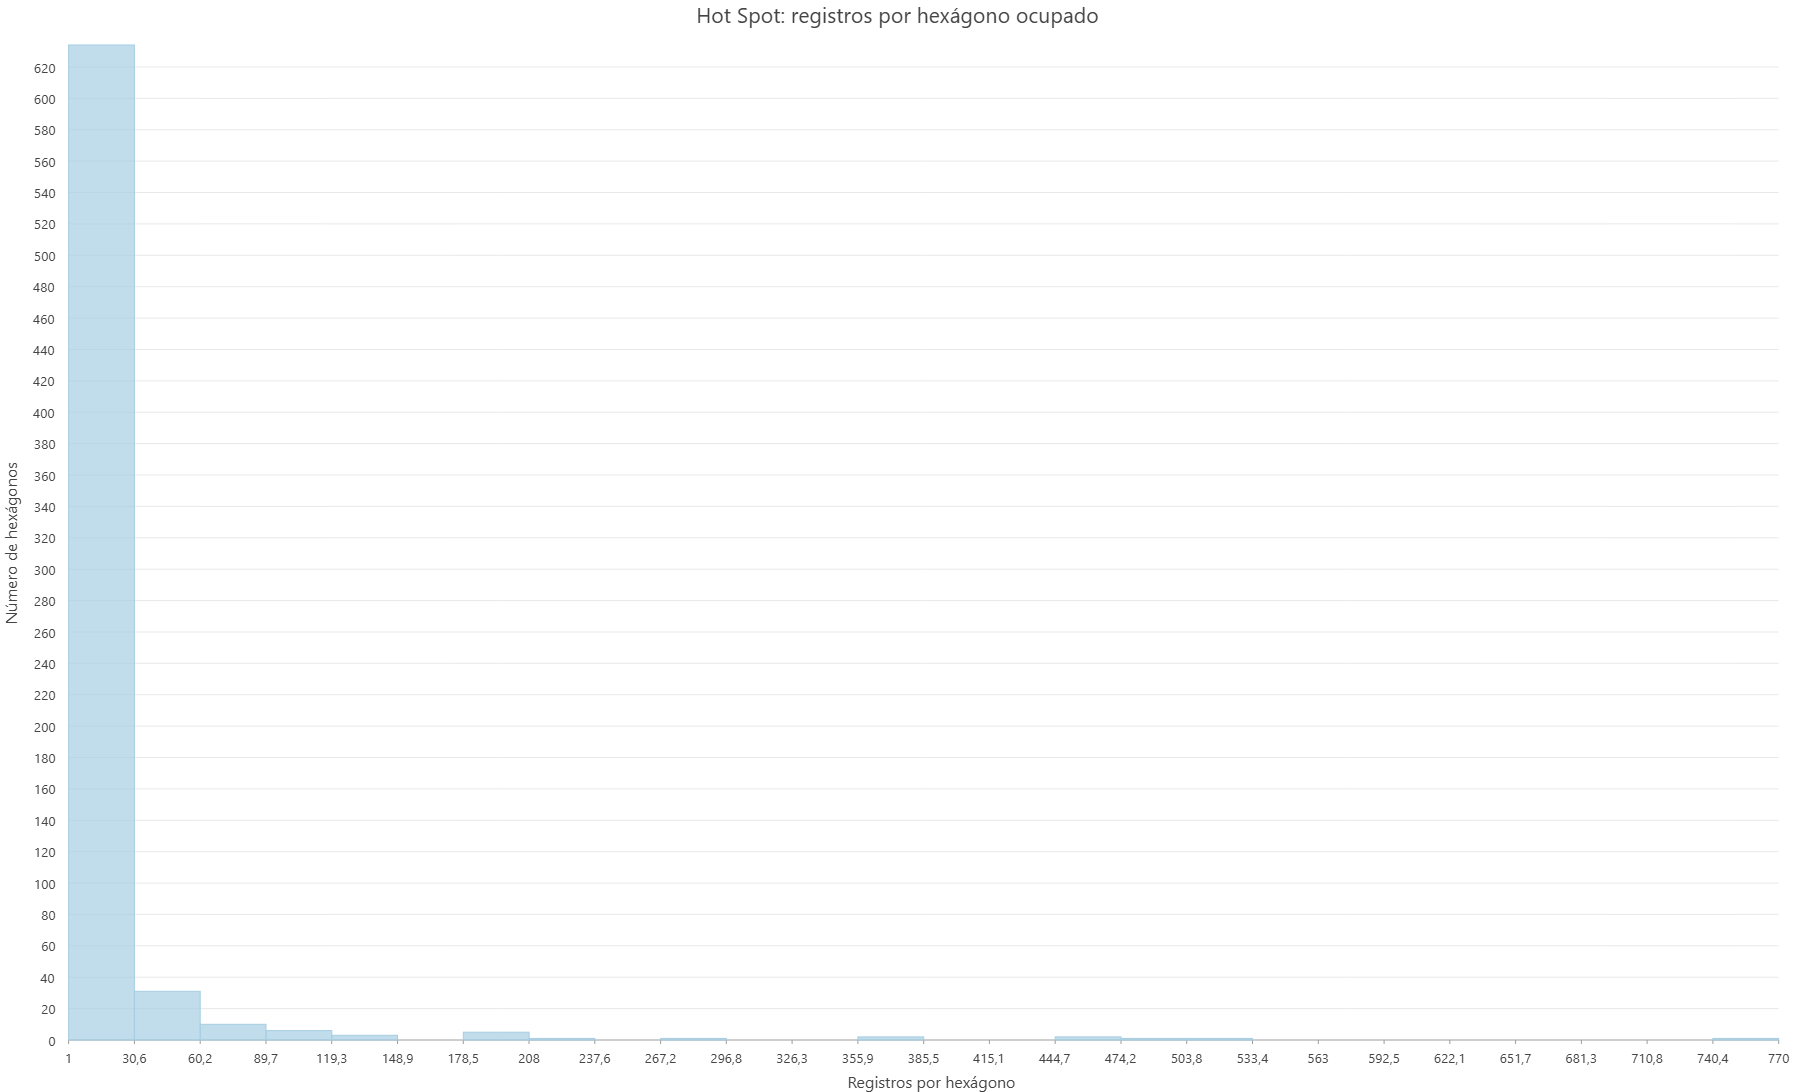

Base en línea: Light Gray Canvas | Esri y colaboradores; atribución dentro del mapa.


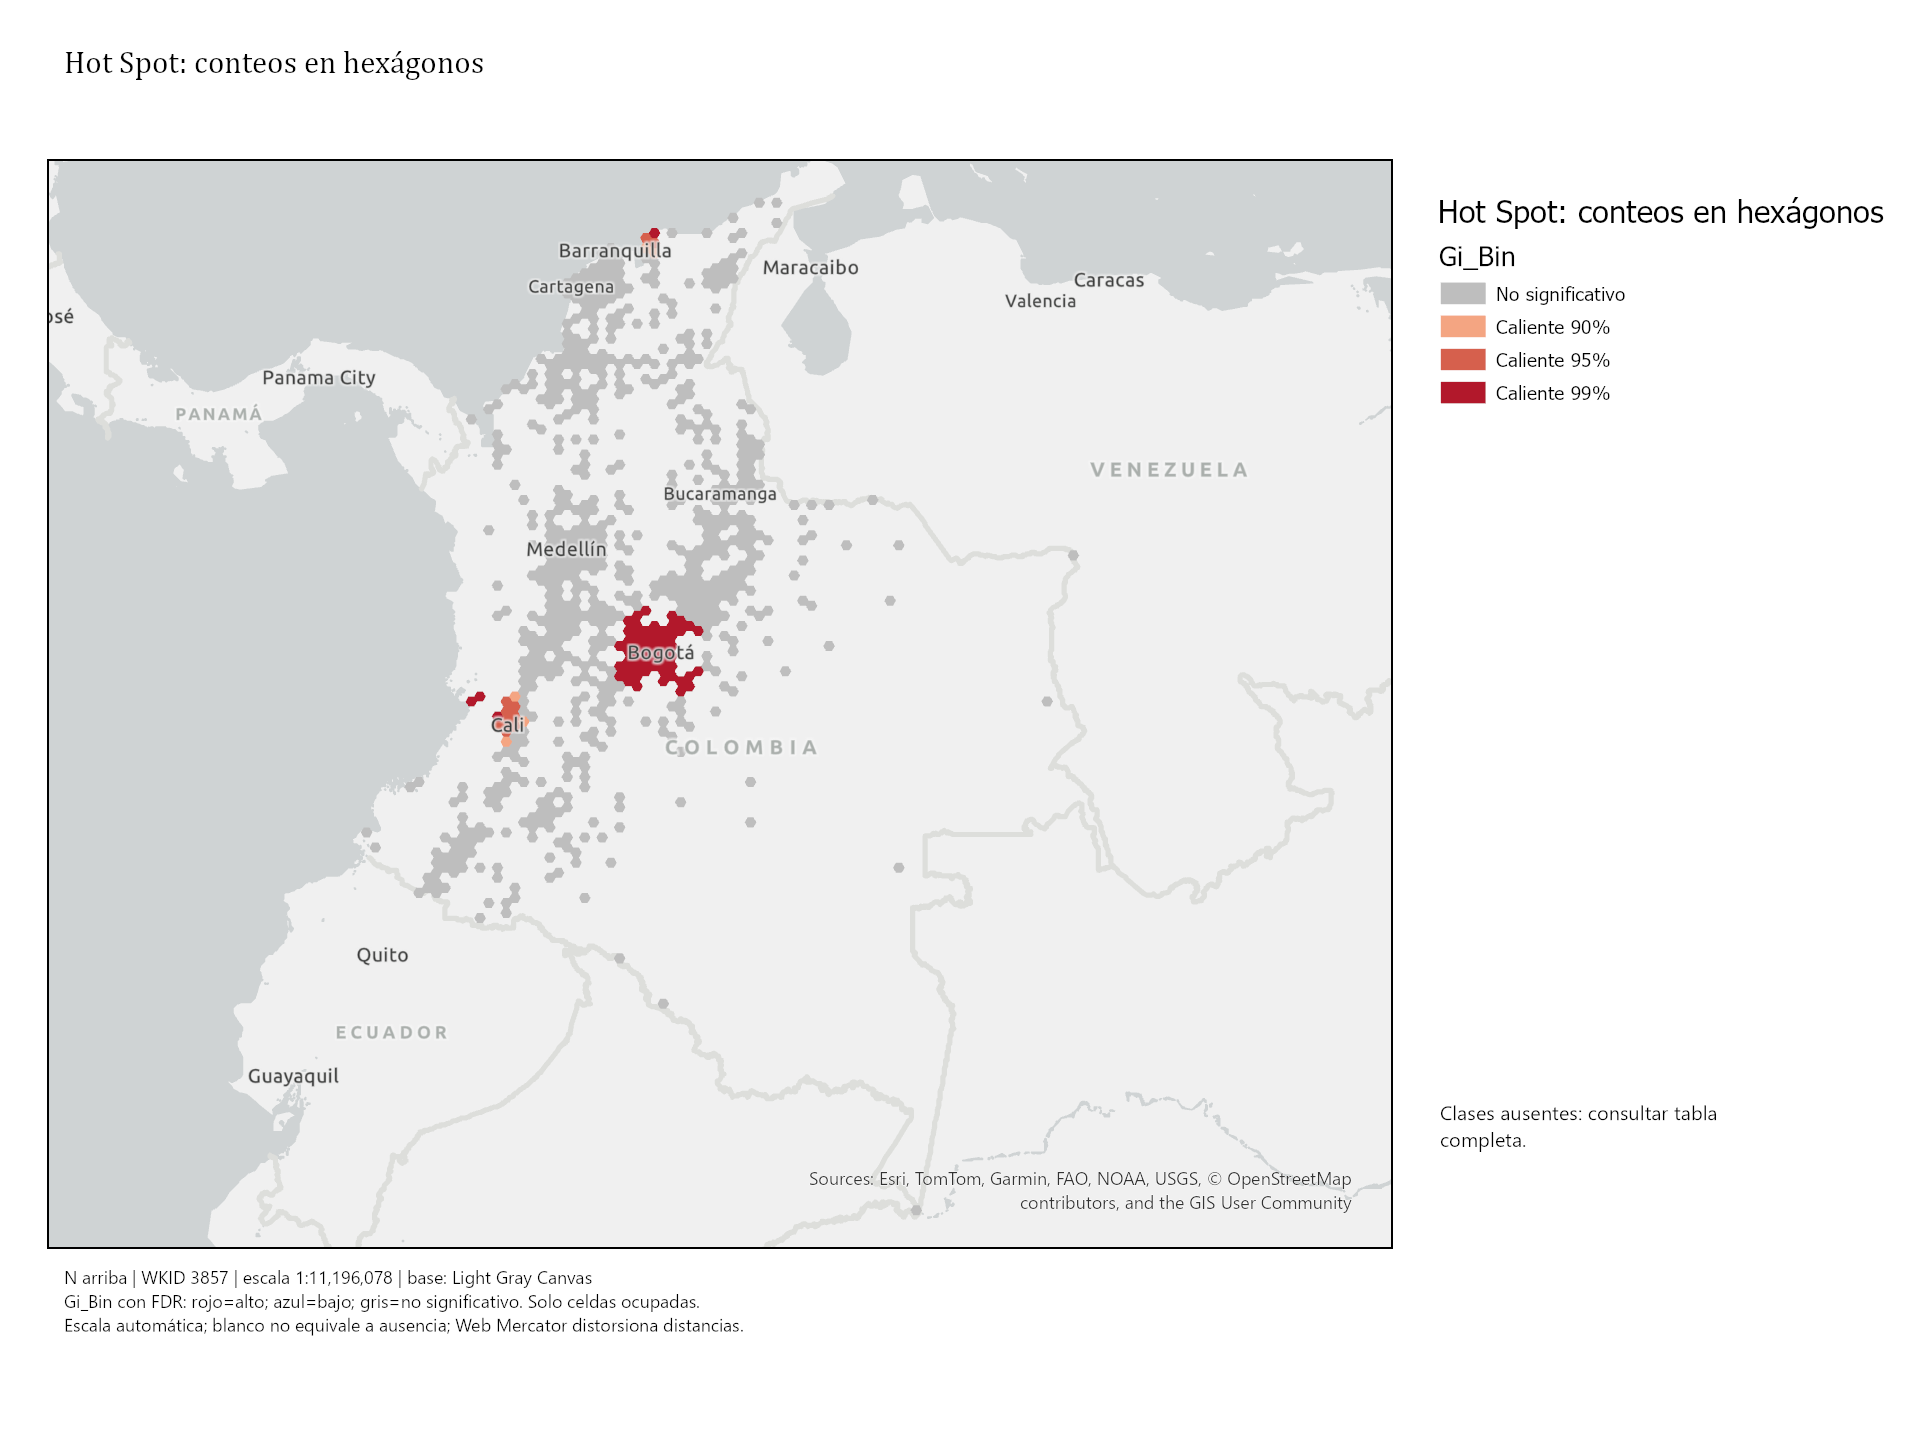

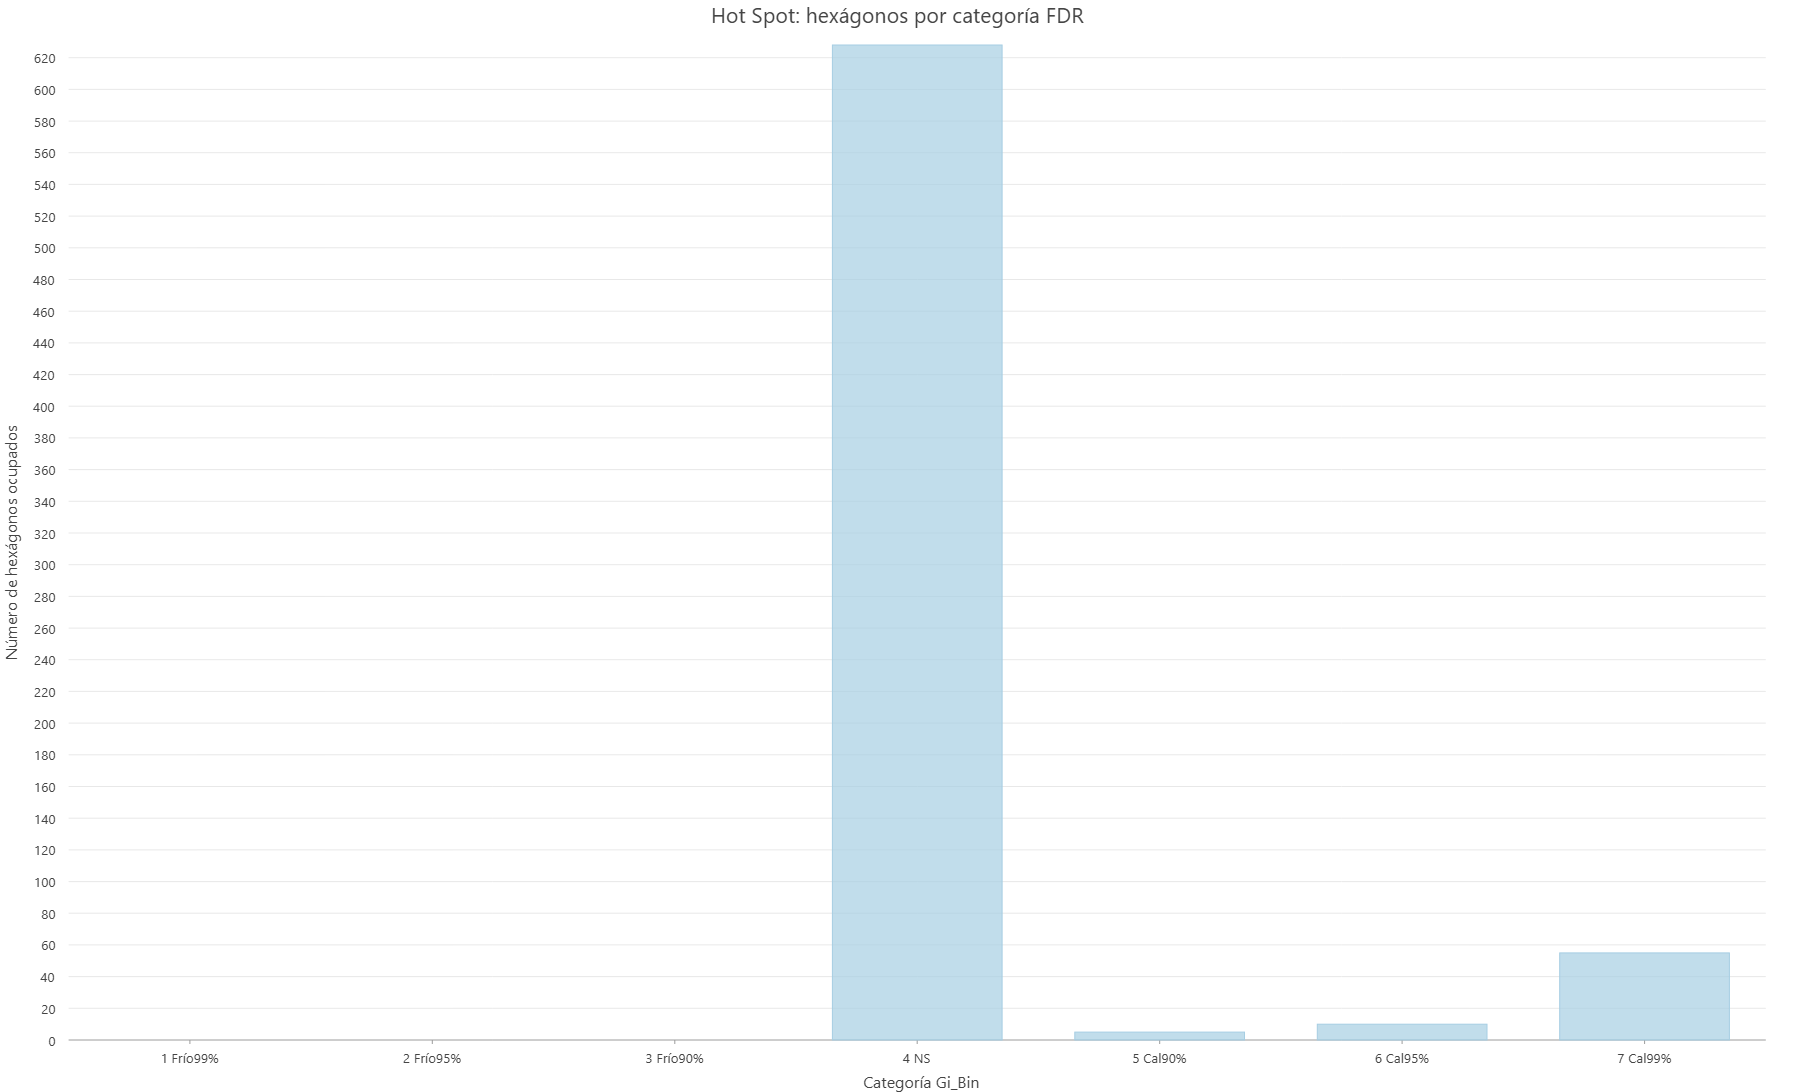

Hexágonos calientes: 70 | fríos: 0 | no significativos: 628


In [40]:
# Visuales nativos sobre el resultado real: distribución de conteos y categorías inferenciales.
chart_png(arcpy.charts.Histogram(x=oha_count_field, dataSource=hex_hotspots,
    title='Hot Spot: registros por hexágono ocupado', xTitle='Registros por hexágono',
    yTitle='Número de hexágonos'), 'hex_hotspot_histograma')
hex_gi_styles = {str(v): (labels[v], gi_colors[v+3], 0) for v in range(-3, 4)}
mapa_categorias(hex_hotspots, 'Gi_Bin', 'hex_hotspot_mapa', 'Hot Spot: conteos en hexágonos',
    hex_gi_styles, 'Gi_Bin con FDR: rojo=alto; azul=bajo; gris=no significativo. Solo celdas ocupadas.\nEscala automática; blanco no equivale a ausencia; Web Mercator distorsiona distancias.')
oha_table = tabla_frecuencia('Hex_HotSpot_frecuencias',
    [(short_labels[v+3], oha_categories[v]) for v in range(-3, 4)])
chart_png(arcpy.charts.Bar(x='Categoria', y='Sitios', aggregation='SUM', dataSource=oha_table,
    title='Hot Spot: hexágonos por categoría FDR', xTitle='Categoría Gi_Bin',
    yTitle='Número de hexágonos ocupados'), 'hex_hotspot_barras')
print('Hexágonos calientes:', sum(oha_categories[v] for v in (1, 2, 3)),
      '| fríos:', sum(oha_categories[v] for v in (-3, -2, -1)), '| no significativos:', oha_categories[0])


**Lectura del resultado:** en el mapa destaca una agrupación caliente alrededor de la etiqueta Bogotá y se ven otras cerca de Cali y Barranquilla. Es una referencia visual, no un recuento por municipio. La barra dominante corresponde a los 628 hexágonos no significativos; las categorías frías quedan en cero. El histograma reúne conteos muy distintos (1–770): una celda con muchos registros no basta por sí sola para explicar su categoría Gi*. El espacio sin hexágonos no demuestra ausencia de colegios.

## Outlier en hexágonos: ¿dónde un conteo contrasta con sus vecinos?

Ahora imagina un hexágono con muchos registros rodeado de hexágonos con pocos. Ese contraste no responde a la misma pregunta que una agrupación caliente. **Optimized Outlier Analysis** usa el Moran local de Anselin para separar semejanzas y contrastes entre un área y su vecindad. La primera letra de `COType` describe el valor local y la segunda, sus vecinos: HH=alto entre altos; LL=bajo entre bajos; HL=alto entre bajos; LH=bajo entre altos. HL y LH son valores atípicos **espaciales**, no errores para borrar. La categoría no significativa se presentará como NS; no significa que los conteos sean iguales. [Esri Pro 3.6, Optimized Outlier Analysis, Usage](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/spatial-statistics/optimizedoutlieranalysis.htm).

Volvemos a los mismos registros originales, con campo de análisis vacío y agregación hexagonal. Usamos `BALANCED_499` (499 permutaciones) y dejamos tamaño y distancia automáticos. COType incorpora la corrección FDR; no se obtiene simplemente aplicando 0.05 al pseudo-p crudo. Las permutaciones forman parte de la inferencia, por lo que una repetición no garantiza categorías idénticas cerca del umbral. [Esri, misma referencia, Usage y Parameters: Performance Adjustment](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/spatial-statistics/optimizedoutlieranalysis.htm).

Cada herramienta elige su escala de manera independiente: sus alturas de celda y distancias **pueden diferir**. No suponemos que tengan los mismos hexágonos ni los emparejamos por OID. La comparación será de preguntas y patrones generales; no una concordancia celda a celda.

In [41]:
# Moran local optimizado: 499 permutaciones, sin imponer la escala elegida por Gi*.
hex_outliers = str(Path(gdb) / 'Outlier_hexagonos')
ooa_result = gp_child('OptimizedOutlierAnalysis', Output_Features=hex_outliers,
                      Performance_Adjustment='BALANCED_499', **hex_parameters)
print(ooa_result['messages'])
print('Salidas declaradas por ArcGIS:', ooa_result['outputs'])
(run / 'Outlier_hexagonos_mensajes.txt').write_text(ooa_result['messages'], encoding='utf-8')
ooa_count_field, ooa_counts = leer_conteos_hexagonales(hex_outliers)
co_labels = {'HH': 'Alto entre altos', 'LL': 'Bajo entre bajos',
             'HL': 'Alto entre bajos', 'LH': 'Bajo entre altos', 'NS': 'No significativo'}
# Conservar COType original; una clase auxiliar permite mostrar vacíos como NS.
arcpy.management.AddField(hex_outliers, 'ClaseCO', 'TEXT', field_length=2)
raw_co = Counter()
with arcpy.da.UpdateCursor(hex_outliers, ['COType', 'ClaseCO']) as cursor:
    for row in cursor:
        raw_co[row[0]] += 1
        categoria = str(row[0]).strip().upper() if row[0] is not None else ''
        categoria = categoria or 'NS'
        if categoria not in co_labels:
            raise ValueError('COType inesperado: ' + repr(row[0]))
        row[1] = categoria
        cursor.updateRow(row)
with arcpy.da.SearchCursor(hex_outliers, ['ClaseCO']) as cursor:
    ooa_categories = Counter(row[0] for row in cursor)
print('COType originales (sin modificar):', dict(raw_co))
tabla_visible(['COType / NS', 'Lectura', 'Hexágonos'],
              [[v, co_labels[v], ooa_categories[v]] for v in co_labels])


Hijo OptimizedOutlierAnalysis PID 21680 | diario: 99 - Recursos/salidas_clase_02/practica_02/hexbin_20260921/ejecucion_b557fbd99b8a/gp_children/OptimizedOutlierAnalysis_b6542667abc5/process.json


Cierre natural del hijo: 0 | logs: 99 - Recursos/salidas_clase_02/practica_02/hexbin_20260921/ejecucion_b557fbd99b8a/gp_children/OptimizedOutlierAnalysis_b6542667abc5


Start Time: lunes, 21 de septiembre de 2026 5:32:20 p. m.

************************** Initial Data Assessment ***************************
Making sure there are enough incidents for analysis....
    - There are 10617 valid input features.

Looking for locational outliers....
    - There were 158 outlier locations; these will not be used to compute the hexagon size.

**************************** Incident Aggregation ****************************
    - Using a hexagon of width 20676.0678 meters and height 17906.0000 meters

Counting the number of incidents in each hexagon....
    - Analysis is performed on all hexagons containing at least one incident.

Evaluating incident counts and number of polygons....
    - The aggregation process resulted in 698 weighted polygons.
    - Incident Count Properties:
        Min:         1.0000
        Max:       770.0000
        Mean:       15.2106
        Std. Dev.:  56.3378
***************************** Scale of Analysis ******************************

Hexágonos ocupados,Registros contados,Mínimo por hexágono,Máximo
698,10617,1,770


COType originales (sin modificar): {'': 698}


COType / NS,Lectura,Hexágonos
HH,Alto entre altos,0
LL,Bajo entre bajos,0
HL,Alto entre bajos,0
LH,Bajo entre altos,0
NS,No significativo,698


### Distinguir una agrupación de un contraste
Outlier conservó los mismos **10 617 registros en 698 hexágonos ocupados**, con conteos entre 1 y 770. También eligió altura **17 906 m**, ancho **20 676.0678 m** y distancia **92 699 m**. Esta coincidencia es un resultado de la corrida, no una igualdad que debamos asumir en otros datos.

Con **499 permutaciones**, la clasificación FDR fue **HH=0, LL=0, HL=0, LH=0 y NS=698**. COType quedó vacío en las 698 filas; la columna auxiliar ClaseCO lo presenta como NS sin modificar COType. No hay un contraste local significativo que podamos señalar en este resultado. Eso no demuestra que todos los conteos sean iguales ni que la distribución sea aleatoria.

Al igual que Hot Spot, la herramienta no encontró escala mediante la búsqueda incremental y recurrió a la media de 30 vecinos. Las 158 ubicaciones atípicas solo se excluyeron de la estimación del tamaño; el total de registros se conservó. El mensaje de Outlier indica que el **5 %** de las entidades tuvo menos de ocho vecinos. No hubo advertencias de geoprocesamiento. El mapa gris y las barras con ceros son un resultado válido: no se cambian parámetros para obtener colores.

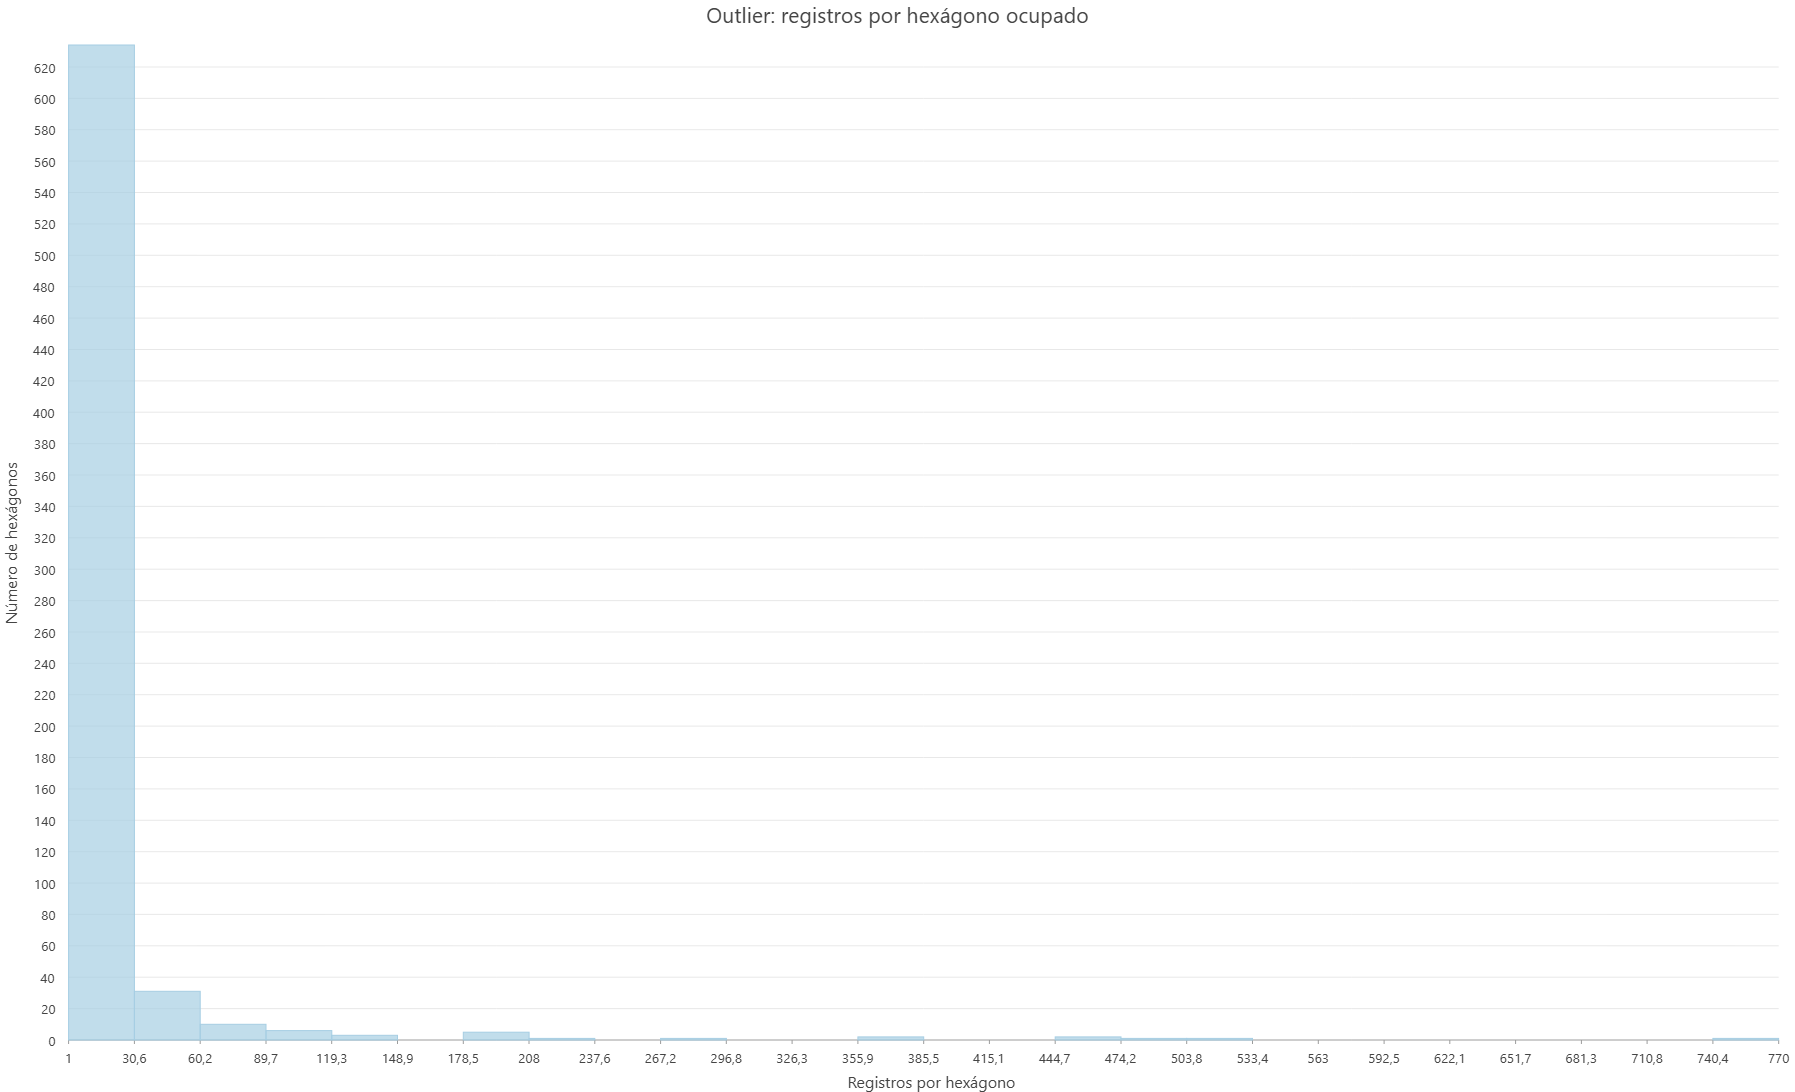

Base en línea: Light Gray Canvas | Esri y colaboradores; atribución dentro del mapa.


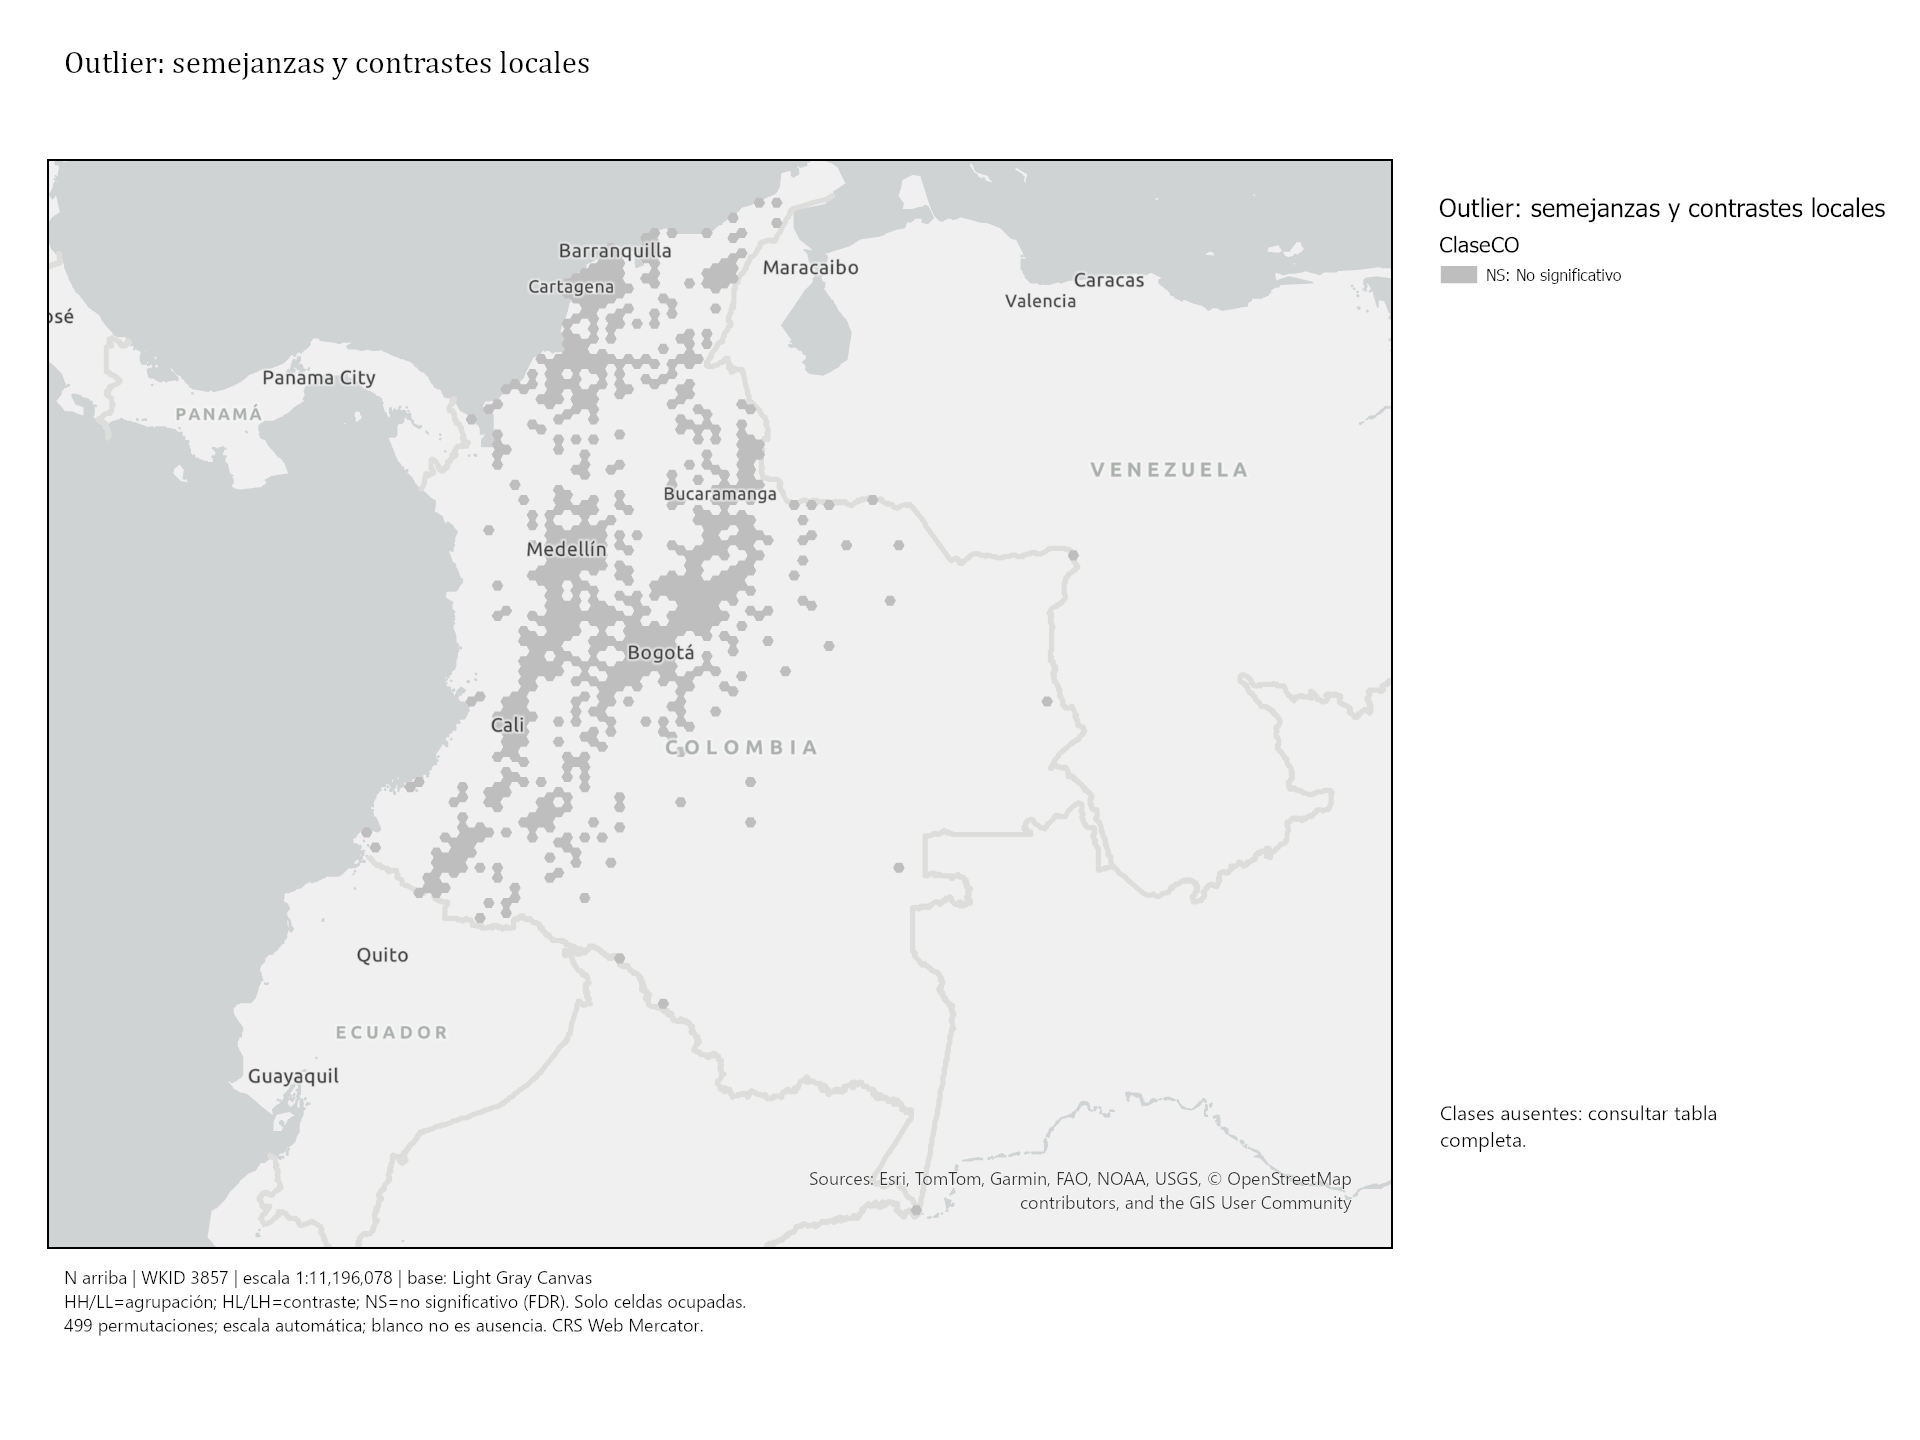

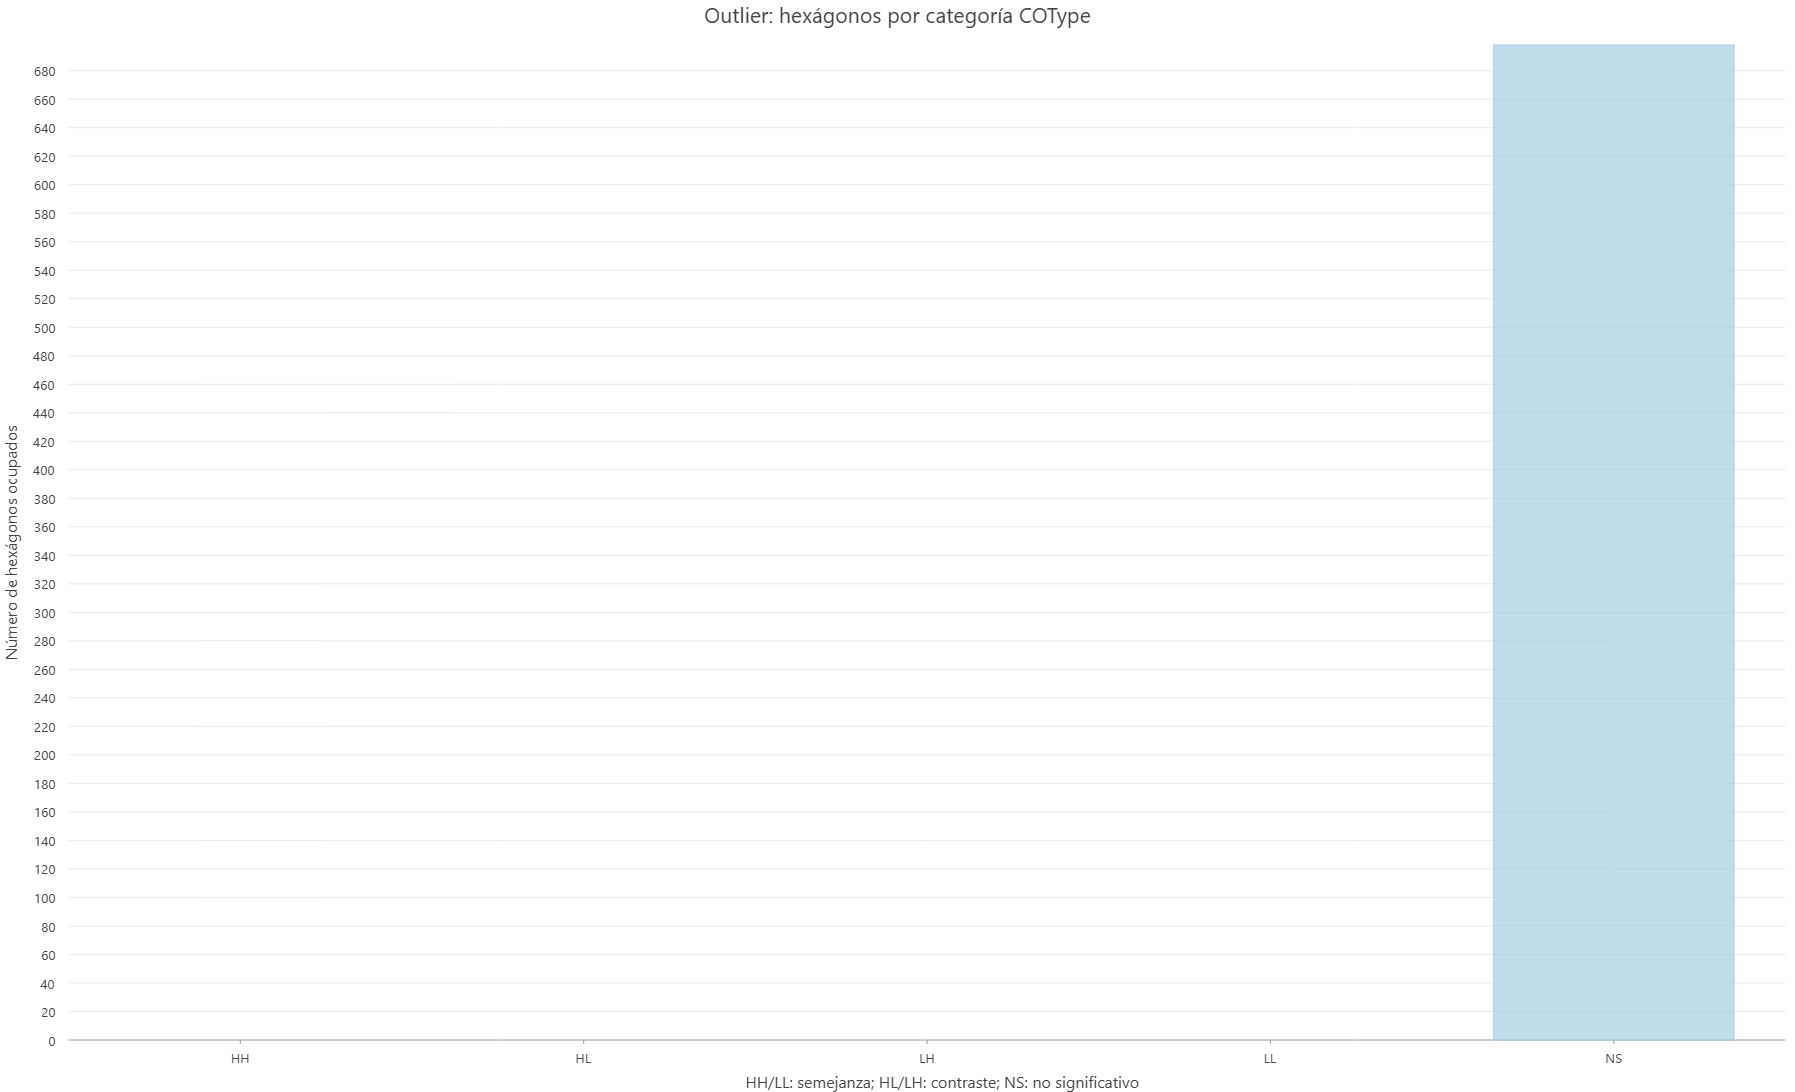

Contrastes HL: 0 | LH: 0 | no significativos: 698


In [42]:
# Mantener colores distintos para semejanzas y contrastes; ninguna categoría se fuerza a aparecer.
chart_png(arcpy.charts.Histogram(x=ooa_count_field, dataSource=hex_outliers,
    title='Outlier: registros por hexágono ocupado', xTitle='Registros por hexágono',
    yTitle='Número de hexágonos'), 'hex_outlier_histograma')
co_colors = {'HH': [178,24,43,100], 'LL': [33,102,172,100],
             'HL': [230,140,30,100], 'LH': [125,65,170,100], 'NS': [190,190,190,100]}
co_styles = {v: (v + ': ' + co_labels[v], co_colors[v], 0) for v in co_labels}
mapa_categorias(hex_outliers, 'ClaseCO', 'hex_outlier_mapa', 'Outlier: semejanzas y contrastes locales',
    co_styles, 'HH/LL=agrupación; HL/LH=contraste; NS=no significativo (FDR). Solo celdas ocupadas.\n499 permutaciones; escala automática; blanco no es ausencia. CRS Web Mercator.')
ooa_table = tabla_frecuencia('Hex_Outlier_frecuencias',
    [(v, ooa_categories[v]) for v in co_labels])
chart_png(arcpy.charts.Bar(x='Categoria', y='Sitios', aggregation='SUM', dataSource=ooa_table,
    title='Outlier: hexágonos por categoría COType', xTitle='HH/LL: semejanza; HL/LH: contraste; NS: no significativo',
    yTitle='Número de hexágonos ocupados'), 'hex_outlier_barras')
print('Contrastes HL:', ooa_categories['HL'], '| LH:', ooa_categories['LH'],
      '| no significativos:', ooa_categories['NS'])


**Lectura del resultado:** el mapa solo muestra NS y la única barra positiva reúne los 698 hexágonos. Los ceros de HH, LL, HL y LH no son categorías omitidas. El histograma sigue mostrando variación de conteos (1–770), pero variación no equivale a significancia espacial. No hay un HL o LH significativo para localizar en esta corrida; no se interpreta el gris como igualdad, seguridad o cobertura educativa suficiente.

## ¿Qué cambió al pasar de sitios a hexágonos?

En el primer Gi*, ICOUNT medía registros en una coordenada y cada sitio tenía ocho vecinos. En los nuevos modelos, el valor es el número de registros dentro de un hexágono y cada herramienta decide una distancia. Cambiaron tanto la unidad de análisis como la vecindad; no podemos atribuir cualquier diferencia únicamente al algoritmo.

En esta ejecución coincidieron la altura de celda y la distancia elegida. Hot Spot clasificó 70 hexágonos como calientes; Outlier no detectó HH, LL, HL ni LH significativos con 499 permutaciones y FDR. No es una contradicción: Gi* y Moran local contrastan patrones distintos. Podemos comparar sus preguntas y lo que muestran los mapas, pero no tratar «caliente» y HH como etiquetas intercambiables ni asumir correspondencia de polígonos por OID. Las herramientas también informan proporciones distintas con menos de ocho vecinos: 4.2 % y 5 %, respectivamente.

Una conclusión útil describe qué patrón aparece, con qué unidad y vecindad, y qué no puede explicar. Ninguno de estos resultados mide calidad escolar, suficiencia de cupos, accesibilidad o causalidad. Un polígono vacío fuera de la cobertura analizada tampoco resuelve esas preguntas.

## Procedencia y evidencia

**Preparación para publicación:** rutas personales normalizadas a rutas relativas del repositorio, sin reejecutar análisis ni alterar resultados académicos. La evidencia local de ejecución se conserva íntegra en los respaldos; los enlaces a salidas son referencias locales y no todos los archivos auxiliares viajan con Git. Se conservan los PNG y PDF incrustados. El usuario confirmó el permiso de redistribución de mapas y resultados; las restricciones consignadas en los registros anteriores describen su estado histórico.

**Ampliación del 21/09/2026, ejecutada integralmente:** comparación hexagonal solicitada por el usuario; no se atribuye al video. No hubo nueva revisión directa del video en esta sesión; no se declara la clase procesada ni completa. Las salidas incrustadas corresponden a esta nueva ejecución; las observaciones y evidencias históricas se conservan por separado. [Respaldo exacto previo a esta ampliación](<../salidas_clase_02/practica_02/hexbin_20260921/P02_antes_hexbin.ipynb>). Se completaron **42/42 celdas sin errores**, con contadores consecutivos, 22 PNG y dos PDF válidos. Kernel, controlador y siete hijos terminaron naturalmente con código 0; no quedaron procesos observados vivos ni hijos pendientes. Duración del intento: 280.854 s, incluido arranque y cierre. El controlador informó una advertencia no fatal zmq/Proactor; stderr del kernel y de los hijos quedó vacío. Los siete resultados GP no contienen errores ni advertencias, sin omitir las limitaciones metodológicas explicadas junto a las salidas.

[Notebook ejecutado](<../salidas_clase_02/practica_02/hexbin_20260921/j04_notebooks/20260921_172808_P02_f4508f31/executed_attempt.ipynb>) · [Comprobaciones de ejecución y cierre](<../salidas_clase_02/practica_02/hexbin_20260921/j04_notebooks/20260921_172808_P02_f4508f31/result.json>) · [Retorno del controlador](<../salidas_clase_02/practica_02/hexbin_20260921/controller_6beeedf93f2f/controller-exit.json>) · [Resultados ArcGIS](<../salidas_clase_02/practica_02/hexbin_20260921/ejecucion_b557fbd99b8a/>). Las salidas se incorporaron solo después de comprobar identidad y código de cada celda; las interpretaciones se actualizaron sin reejecutar modelos. Revisión focalizada de los dos mapas y las dos barras realizada; la interacción en Pro/Obsidian no se certifica.

Fuentes de la ampliación: Esri, **ArcGIS Pro 3.6**, [Optimized Hot Spot Analysis](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/spatial-statistics/optimized-hot-spot-analysis.htm) y [Optimized Outlier Analysis](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/spatial-statistics/optimizedoutlieranalysis.htm), secciones Usage, Parameters y Python; pasajes consultados por el coordinador el 2026-09-21. Conteos hexagonales de puntos, ausencia de límites, escalas automáticas y BALANCED_499. Visuales ejecutados: elaboración docente mediante mapas ArcPy y clases `arcpy.charts`, sobre la copia local citada. Los mensajes de Outlier registran 499 permutaciones y semilla 799 en este intento; esa semilla es evidencia observada, no un parámetro fijado por el notebook.

**Estado histórico conservado:** 37/37 celdas, cero errores; kernel, controlador y cinco hijos con retorno natural 0 en la corrida J04 del 17/09/2026. La separación local de procesos no demuestra reparación del entorno ni la causa del aborto anterior. Agg se aplica solo a informes internos del hijo, no sustituye visuales ArcGIS. Interfaz del visor y revisión académica pendientes.

Datos: exportación local autorizada de **Colegios de Colombia / CommunityMapsEsriColombia**, sin acceso remoto nuevo ni modificación del original. La exportación se mantiene separada de la copia integrada histórica.
Esri, ArcGIS Pro 3.6, consulta de pasajes 2026-09-15: [Collect Events](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/spatial-statistics/collect-events.htm), Usage/Python/Licensing; [Incremental Spatial Autocorrelation](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/spatial-statistics/incremental-spatial-autocorrelation.htm), Usage/Parameters/Outputs; [cómo funciona incremental](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/spatial-statistics/how-incremental-spatial-autocorrelation-works.htm), picos y escala del proceso. APIs de mapas y gráficos: entorno ArcPy instalado Pro 3.6.2; exportaciones reales conservadas; revisión visual focalizada realizada.


### Registro histórico anterior — no describe la ejecución Jupyter guardada

Historia exacta y salidas incrustadas: `99 - Recursos\salidas_clase_02\practica_02\reorganizacion_20260917\historico_5474224332\Clase 02 - Practica 02 - Colegios y escala espacial.ipynb`. Resultados anteriores intactos. No atribuir Colegios al video Bomberos del 16/09/2026. Cobertura de video parcial, no clase completa. Data Engineering manual, Jupyter, VS Code y Obsidian no comprobados. El intento anterior completó celdas pero terminó con error nativo GIL al cerrar Python; no acredita cierre natural. Se conserva íntegro en la carpeta de resultados. Corrida final: 32/32 celdas, 73.024 s, 16 PNG, sin errores de celda; retorno natural 0 observado por el escritor durante la ejecución original, no por el verificador independiente. Salidas: `99 - Recursos/salidas_clase_02/practica_02/reorganizacion_20260917/ejecucion_fb7b2e19ecf8`. Registro: `99 - Recursos/salidas_clase_02/practica_02/reorganizacion_20260917/proceso_58b3305057/ejecucion.json`. PNG de curva regional z revisado: ejes y guías legibles. Navegador y descarga PDF no probados.

[Notebook histórico exacto](<../salidas_clase_02/practica_02/reorganizacion_20260917/historico_4db7708890/Clase 02 - Practica 02 - Colegios y escala espacial.ipynb>) · [Resultados de esta ejecución](<../salidas_clase_02/practica_02/reorganizacion_20260917/ejecucion_fb7b2e19ecf8/>) · [Registro de ejecución](<../salidas_clase_02/practica_02/reorganizacion_20260917/proceso_58b3305057/ejecucion.json>). Figuras: elaboración docente con ArcGIS Pro y las entradas citadas; bases Esri y colaboradores. Uso local, sin aprobación de redistribución.

**Línea base original inequívoca:** [primer respaldo exacto](<../salidas_clase_02/practica_02/reorganizacion_20260917/historico_4db7708890/Clase 02 - Practica 02 - Colegios y escala espacial.ipynb>), creado antes de la primera reescritura. El respaldo `historico_5474224332` contiene los mismos bytes y es una copia posterior de esa misma línea base, no otra versión; ambos permanecen intactos.

**Alcance del registro:** el JSON original registra celdas, duración, errores, imágenes y carpeta, pero no código de salida. El cierre natural 0 es observación del escritor asociada a ese registro y al comando consignado en metadatos; no es una captura independiente ni una ejecución nueva. Metadatos de fallos de licencia y cierres forzados quedan íntegros bajo `historical_execution_metadata` y no describen esta corrida.

### Intento Jupyter histórico — 17/09/2026, cierre fallido

El registro siguiente conserva el fallo anterior; sus salidas no son las nuevas salidas incrustadas.

**Ejecución Jupyter: 32/32 celdas completadas, 0 errores de celda, salidas guardadas. Advertencia: el kernel abortó al cerrar; este problema del entorno no está resuelto.**

Se conservan los 16 PNG, mensajes, contadores y tiempos de celda auténticos de [este intento](<../salidas_clase_02/ejecucion_jupyter_20260917/reintento_3a2b2b37dc/P02/executed_attempt.ipynb>). Duración registrada del intento: 176.265 s, incluido el cierre; no es tiempo puro de celdas. Kernel: salida **3221227010**; controlador: salida **1**. [Registro](<../salidas_clase_02/ejecucion_jupyter_20260917/reintento_3a2b2b37dc/P02/execution.json>) · [stderr](<../salidas_clase_02/ejecucion_jupyter_20260917/reintento_3a2b2b37dc/P02/kernel.stderr.log>) · [Canónico anterior exacto](<../salidas_clase_02/ejecucion_jupyter_20260917/guardado_canonico_20260917/P02/Clase 02 - Practica 02 - Colegios y escala espacial.ipynb>). PDF nativos: [Refinada_500.pdf](<../salidas_clase_02/practica_02/reorganizacion_20260917/ejecucion_68b7f99180da/Refinada_500.pdf>) · [Regional_2000.pdf](<../salidas_clase_02/practica_02/reorganizacion_20260917/ejecucion_68b7f99180da/Regional_2000.pdf>). Sin nueva ejecución ni reparación del entorno; interfaz del visor no comprobada, video parcial y revisión académica pendiente.

### Ejecución histórica del 17/09/2026 con procesos estadísticos separados

37/37 celdas auténticas, cero errores; 16 PNG y 2 PDF nativos válidos y coincidentes con los archivos nuevos. Kernel, hijos y controlador terminaron naturalmente con 0; stderr del kernel y de los hijos vacío, identidades registradas ausentes. Tiempo total del intento: 177.779 s, incluido arranque/cierre. El controlador conserva advertencias no fatales de nbclient/fechas y zmq/Proactor. Comparación posterior de solo lectura: resultados estadísticos equivalentes a la línea base, según el alcance documentado; no se compara identidad binaria entre PDF de corridas distintas.

[Ejecución real](<../salidas_clase_02/ejecucion_jupyter_20260917/j04_notebooks/20260917_172325_P02_6e234833/executed_attempt.ipynb>) · [Cierre y visuales](<../salidas_clase_02/ejecucion_jupyter_20260917/j04_notebooks/20260917_172325_P02_6e234833/runtime-artifact-checks.json>) · [Comparación estadística](<../salidas_clase_02/ejecucion_jupyter_20260917/j04_notebooks/20260917_172325_P02_6e234833/statistics-comparison.json>) · [Retorno externo del controlador](<../salidas_clase_02/ejecucion_jupyter_20260917/j04_notebooks/controller_P02_d63aa5640fdb/controller-exit.json>) · [Resultados nuevos](<../salidas_clase_02/practica_02/reorganizacion_20260917/ejecucion_7260b90c3d4a/>) · [Respaldo anterior exacto](<../salidas_clase_02/ejecucion_jupyter_20260917/j04_notebooks/candidates/P02_before_canonical_promotion_v1.ipynb>).

Adaptación local validada para esta práctica, no reparación de paquetes ni certificación de la clase completa. Los abortos históricos permanecen documentados; video parcial, interfaz no comprobada y revisión académica pendiente.